# Portefeuille Core-Satellite — Notebook Principal

| Étape | Module | Rôle |
|-------|--------|------|
| 1 | `core_pipeline` | Sélection des 3 ETF Core (Equity Europe / Rates / Credit) |
| 2 | `efficient_frontier_core` | Comparaison 5 stratégies d'allocation Core |
| 3 | `satellite_pipeline` | Shortlist 19 fonds, filtrage 4 niveaux, 3 blocs |
| 4 | `fond_construction` | Construction portefeuille, backtest OOS |
| 6 | `plots_report` | Graphiques complets |


**IS :** 01/01/2019 → 31/12/2020 — **OOS :** 01/01/2021 → 31/12/2025  
**Core :** `univers_core_etf_eur_daily_wide.xlsx` — **Satellite :** `STRAT1/2/3_info+price.xlsx`

In [1]:
from pathlib import Path
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
# ----- Root project
candidates = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
project_root = next((p for p in candidates if (p / 'src').exists()), Path.cwd())
os.chdir(project_root)

# ----- Memory-first mapping for outputs CSV reads
OUTPUT_MEMORY_MAP = {
    'outputs/satellite_selected_v3.csv': ['satellite_final_selection', 'final_selection_df', 'selection_12'],
    'outputs/satellite_selected.csv': ['satellite_final_selection', 'final_selection_df', 'selection_12'],
    'outputs/satellite_quarterly_selection.csv': ['quarter_selection_df', 'quarterly_sel', 'sel_q'],
    'outputs/satellite_dynamic_weights_ticker_daily.csv': ['weights_ticker_daily', 'w_ticker'],
    'outputs/satellite_dynamic_weights_block_daily.csv': ['block_weights_daily', 'w_block'],
    'outputs/satellite_dynamic_active_funds_daily.csv': ['active_funds_daily', 'active_funds', 'active_daily'],
    'outputs/regime_core_daily.csv': ['regime_output', 'regime_daily'],
    'outputs/fond_metrics.csv': ['metrics', 'sat_metrics', 'm'],
    'outputs/fond_weights.csv': ['weights_df', 'w_df'],
    'outputs/fond_annual_perf.csv': ['annual_df', 'ann'],
    'outputs/core_portfolio_comparison.csv': ['comp_df', 'comp'],
    'outputs/fond_returns_daily.csv': ['portfolio_df', 'fund'],
    'outputs/satellite_individual_returns.csv': ['sat_rets_all', 'sat_components'],
    'outputs/core3_etf_daily_simple_returns.csv': ['daily_simple_returns', 'core_components_full'],
}

def _read_from_memory_csv(path, *args, **kwargs):
    p = str(path).replace('\\', '/')
    candidates = OUTPUT_MEMORY_MAP.get(p, [])
    for name in candidates:
        if name in globals():
            obj = globals()[name]
            if hasattr(obj, 'copy'):
                return obj.copy()
            return obj
    raise ValueError(
        f"Aucune source disponible pour {p}: variable mémoire introuvable et fichier disque absent."
    )

# Keep a hard reference to pandas' real parser entrypoint to avoid recursive monkey-patch loops.
_orig_read_csv = pd.io.parsers.read_csv
def _read_csv_no_outputs(path, *args, **kwargs):
    p = str(path).replace('\\', '/')
    if p.startswith('outputs/') or '/outputs/' in p:
        try:
            return _read_from_memory_csv(p, *args, **kwargs)
        except ValueError:
            disk_path = Path(p)
            if disk_path.exists():
                return _orig_read_csv(disk_path, *args, **kwargs)
            raise ValueError(
                f"Aucune source disponible pour {p}: mémoire indisponible et fichier disque absent."
            )
    return _orig_read_csv(path, *args, **kwargs)

def _noop_to_csv(self, *args, **kwargs):
    return None

def _noop_savefig(*args, **kwargs):
    return None

pd.read_csv = _read_csv_no_outputs
pd.DataFrame.to_csv = _noop_to_csv
pd.Series.to_csv = _noop_to_csv
plt.savefig = _noop_savefig

%matplotlib inline
plt.rcParams['figure.dpi'] = 110
print(f'Racine du projet : {Path.cwd()}')

Racine du projet : /workspaces/Core_Satellite_Quant


---
## Étape 1 — Sélection des ETF Core

Fichier : `univers_core_etf_eur_daily_wide.xlsx` — filtre exposition Equity = **Europe**  
Backtest rolling Max Sharpe : IS 2019-2020, OOS 2021-2025

In [2]:
from src.core_pipeline_corrected import main as core_main
core_main()

  PIPELINE CORE – VERSION PROPRE
  Fichier Excel           : univers_core_etf_eur_daily_wide.xlsx
  ETF Core retenus        : {'Equity': 'XDWD GY Equity', 'Rates': 'EUNH GY Equity', 'Credit': 'XBLC GY Equity'}
  IS (calibration)        : 2019-01-01 → 2020-12-31
  OOS (validation)        : 2021-01-01 → 2025-12-31
  Méthode rolling         : risk_parity_tilt
  Ledoit-Wolf shrinkage   : True

[1/6] Lecture des données...
  Lecture Equity...
    -> 18 ETFs | 2015-01-01 à 2026-03-02
  Lecture Rates...
    -> 18 ETFs | 2015-01-01 à 2026-03-02
  Lecture Credit...
    -> 19 ETFs | 2015-01-01 à 2026-03-02

[2/6] Validation des 3 ETF Core retenus...
        ticker first_date  n_obs  avg_gap  expense_pct  pass_date  pass_freq  pass_expense  selected
XDWD GY Equity 2015-01-01   2913      1.4         0.12       True       True          True      True
EUNH GY Equity 2015-01-01   2913      1.4         0.07       True       True          True      True
XBLC GY Equity 2015-01-01   2913      1.4        

In [3]:
core_df = pd.read_csv("outputs/Core_finaux.csv")
print("✅ 3 ETF Core sélectionnés :")
display(core_df.style.hide(axis="index"))

✅ 3 ETF Core sélectionnés :


Theme,Ticker,nom,provider,isin,devise,ter_pct,encours_eur_m,exposition
Equity,XDWD GY Equity,Xtrackers MSCI World UCITS ETF 1C,Xtrackers,IE00BJ0KDQ92,EUR,0.120000,16437.000000,"MSCI World (développés, large/mid cap)"
Rates,EUNH GY Equity,iShares Core Euro Government Bond UCITS ETF (Dist),iShares,IE00B4WXJJ64,EUR,0.070000,4869.000000,Govies EMU IG – broad all maturities
Credit,XBLC GY Equity,Xtrackers II EUR Corporate Bond UCITS ETF 1C,Xtrackers,LU0478205379,EUR,0.090000,4748.000000,Corporate IG EUR – toutes maturités


---
## Étape 2 — Comparaison des stratégies d'allocation Core

Stratégies statiques comparées : Max Sharpe IS, Min Variance IS, Equal Weight, Risk Parity, et portefeuilles efficients à vol cible **10% à 20%** (poids fixés sur IS 2019-2020).

In [4]:
from src.efficient_frontier_core import main as frontier_main
strategies, comp_df = frontier_main()

  COMPARAISON DES STRATÉGIES CORE (Markowitz daily)
  IS   : 2019-01-01 → 2020-12-31
  OOS  : 2021-01-01 → 2025-12-31

[1] Chargement des log-rendements journaliers des 3 ETF...
  ETFs : ['XDWD GY Equity', 'EUNH GY Equity', 'XBLC GY Equity']
  Période : 2018-01-02 → 2026-03-02
  Risk-free Bund : Fallback constant 2.00% annual
  IS  : 523 obs | OOS : 1304 obs

[2] Simulation de la frontière (IS)...

[3] Optimisation des stratégies statiques sur IS...
  Max Sharpe              w=[26.7%, 68.3%, 5.0%]  IS Sharpe(exces rf)=0.87  OOS Sharpe(exces rf)=-0.20
  Min Variance            w=[5.0%, 73.3%, 21.7%]  IS Sharpe(exces rf)=0.63  OOS Sharpe(exces rf)=-0.77
  Equal Weight            w=[33.3%, 33.3%, 33.3%]  IS Sharpe(exces rf)=0.76  OOS Sharpe(exces rf)=0.15
  Risk Parity             w=[13.2%, 47.7%, 39.1%]  IS Sharpe(exces rf)=0.70  OOS Sharpe(exces rf)=-0.43
  Efficient Vol 10%       w=[44.9%, 50.1%, 5.0%]  IS Sharpe(exces rf)=0.83  OOS Sharpe(exces rf)=0.24
  Efficient Vol 11%       w=[50

/home/codespace/.local/lib/python3.12/site-packages/scipy/optimize/_slsqp_py.py:437: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)
/home/codespace/.local/lib/python3.12/site-packages/scipy/optimize/_slsqp_py.py:441: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  g = append(wrapped_grad(x), 0.0)
/home/codespace/.local/lib/python3.12/site-packages/scipy/optimize/_slsqp_py.py:495: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  a_eq = vstack([con['jac'](x, *con['args'])
/home/codespace/.local/lib/python3.12/site-packages/scipy/optimize/_slsqp_py.py:501: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  a_ieq = vstack([con['jac'](x, *con['args'])
/workspaces/Core_Satellite_Quant/src/efficient_frontier_core.py:548: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instea

  -> /workspaces/Core_Satellite_Quant/outputs/figures/06_efficient_frontier_core.png
  -> /workspaces/Core_Satellite_Quant/outputs/figures/07_core_strategies_oos_perf.png

  ✓  Frontière efficiente terminée.


In [5]:
cols_is  = ['IS_ret_ann','IS_vol_ann','IS_sharpe']
cols_oos = ['OOS_ret_ann','OOS_vol_ann','OOS_sharpe','OOS_mdd']
fmt_pct  = {c: '{:.1%}' for c in cols_is + cols_oos if 'sharpe' not in c}
fmt_num  = {c: '{:.2f}' for c in cols_is + cols_oos if 'sharpe' in c}

print('=== IS (Calibration 2019-2020) ===')
display(comp_df[cols_is].style.format({**fmt_pct, **fmt_num})
        .highlight_max(subset=['IS_ret_ann','IS_sharpe'], color='lightgreen')
        .highlight_min(subset=['IS_vol_ann'], color='lightblue'))

print('\n=== OOS (Backtest 2021-2025) ===')
display(comp_df[cols_oos].style.format({**fmt_pct, **fmt_num})
        .highlight_max(subset=['OOS_ret_ann','OOS_sharpe'], color='lightgreen')
        .highlight_min(subset=['OOS_vol_ann','OOS_mdd'], color='lightblue'))

=== IS (Calibration 2019-2020) ===


,IS_ret_ann,IS_vol_ann,IS_sharpe
strategie,,,
Max Sharpe,8.5%,7.1%,0.87
Min Variance,5.5%,5.4%,0.63
Equal Weight,9.0%,8.8%,0.76
Risk Parity,6.4%,6.1%,0.70
Efficient Vol 10%,10.8%,10.0%,0.83
Efficient Vol 11%,11.4%,11.0%,0.81
Efficient Vol 12%,12.1%,12.0%,0.79
Efficient Vol 13%,12.7%,13.0%,0.77
Efficient Vol 14%,13.3%,14.0%,0.75



=== OOS (Backtest 2021-2025) ===


,OOS_ret_ann,OOS_vol_ann,OOS_sharpe,OOS_mdd
strategie,,,,
Max Sharpe,0.8%,6.0%,-0.20,-17.5%
Min Variance,-2.2%,5.5%,-0.77,-19.3%
Equal Weight,2.9%,6.2%,0.15,-16.0%
Risk Parity,-0.2%,5.1%,-0.43,-17.4%
Efficient Vol 10%,3.8%,7.4%,0.24,-16.2%
Efficient Vol 11%,4.7%,7.9%,0.33,-15.8%
Efficient Vol 12%,5.6%,8.5%,0.41,-15.6%
Efficient Vol 13%,6.5%,9.1%,0.48,-15.7%
Efficient Vol 14%,7.4%,9.7%,0.53,-15.7%


In [6]:
for fig, title in [
    ('outputs/figures/06_efficient_frontier_core.png', 'Frontière efficiente IS'),
    ('outputs/figures/07_core_strategies_oos_perf.png', 'Performance cumulée OOS'),
]:
    if Path(fig).exists():
        print(title)
        display(Image(fig))

In [7]:
# ═══════════════════════════════════════════════════════════════════════════════
# ⚙️  PARAMÈTRES DE CONFIGURATION DU CORE REBALANCING
# ═══════════════════════════════════════════════════════════════════════════════

# 📌 PARAMÈTRES À MODIFIER PAR L'UTILISATEUR
config_core = {
    'selected_strategy': 'Efficient Vol 16%',      # Choix de la stratégie Core
    'rebalance_frequency': 'annual',               # 'daily', 'weekly', 'monthly', 'quarterly', 'annual'
    'vol_window': '6m',                            # '6m' (126j) ou '1y' (252j)

    # Scénario imposé: NET TER + transaction costs
    'ter_source_csv': 'outputs/Core_finaux.csv',   # Source TER ETF Core
    'transaction_cost_bps_per_side': 10.0,         # bps par côté (achat/vente)
    'transaction_cost_fixed_bps': 0.0,             # bps fixes ajoutés par rebalancing (optionnel)

    'start_value': 100.0,                          # Valeur initiale du portefeuille
    'sim_start_date': '2021-01-01',                # Début de la simulation OOS
    'sim_end_date': '2025-12-31',                  # Fin de la simulation
}

print("⚙️  CONFIGURATION REBALANCING")
print("=" * 70)
print(f"  Stratégie sélectionnée  : {config_core['selected_strategy']}")
print(f"  Fréquence rebalancing   : {config_core['rebalance_frequency']}")
print(f"  Fenêtre volatilité      : {config_core['vol_window']}")
print(f"  Mode coût               : NET TER + transaction costs")
print(f"  Source TER              : {config_core['ter_source_csv']}")
print(f"  Frais par côté          : {config_core['transaction_cost_bps_per_side']:.1f} bps")
print(f"  Frais fixes rebal       : {config_core['transaction_cost_fixed_bps']:.1f} bps")
print(f"  Valeur initiale         : {config_core['start_value']:.2f}")
print(f"  Période simulation      : {config_core['sim_start_date']} → {config_core['sim_end_date']}")
print("=" * 70)

⚙️  CONFIGURATION REBALANCING
  Stratégie sélectionnée  : Efficient Vol 16%
  Fréquence rebalancing   : annual
  Fenêtre volatilité      : 6m
  Mode coût               : NET TER + transaction costs
  Source TER              : outputs/Core_finaux.csv
  Frais par côté          : 10.0 bps
  Frais fixes rebal       : 0.0 bps
  Valeur initiale         : 100.00
  Période simulation      : 2021-01-01 → 2025-12-31


In [8]:
# 1. Sélectionner la stratégie Core à partir de la configuration
selected_strategy = config_core['selected_strategy']
core_weights_array = strategies[selected_strategy]["w"]
tickers = ["XDWD GY Equity", "EUNH GY Equity", "XBLC GY Equity"]
core_weights = dict(zip(tickers, core_weights_array))

print(f"✅ Stratégie Core sélectionnée : {selected_strategy}")
print(f"\n📊 Poids cibles du Core :")
for ticker, w in core_weights.items():
    print(f"  {ticker:<20} : {w:.2%}")
print(f"\n  Somme des poids : {sum(core_weights.values()):.2%}")

# Charger les TER des ETF Core (en %) depuis Core_finaux.csv
core_fees_df = pd.read_csv(config_core['ter_source_csv'])
ter_col = 'ter_pct' if 'ter_pct' in core_fees_df.columns else None
ticker_col = 'Ticker' if 'Ticker' in core_fees_df.columns else None

if ter_col is None or ticker_col is None:
    raise ValueError("Impossible de trouver les colonnes 'Ticker' et 'ter_pct' dans la source TER.")

core_ter_map_pct = (
    core_fees_df[[ticker_col, ter_col]]
    .dropna(subset=[ticker_col])
    .set_index(ticker_col)[ter_col]
    .to_dict()
)

# Garantir la présence des 3 tickers Core
missing_ter = [t for t in tickers if t not in core_ter_map_pct]
if missing_ter:
    print(f"⚠️ TER manquant pour: {missing_ter} (fallback = 0.00%)")
    for t in missing_ter:
        core_ter_map_pct[t] = 0.0

weighted_core_ter_pct = sum(core_weights[t] * core_ter_map_pct[t] for t in tickers)
weighted_core_ter_bps = weighted_core_ter_pct * 100

print("\n💸 TER ETF Core (annuel) :")
for t in tickers:
    print(f"  {t:<20} : {core_ter_map_pct[t]:.2f}%")
print(f"\n  TER pondéré du Core : {weighted_core_ter_pct:.3f}% ({weighted_core_ter_bps:.1f} bps)")

✅ Stratégie Core sélectionnée : Efficient Vol 16%

📊 Poids cibles du Core :
  XDWD GY Equity       : 76.33%
  EUNH GY Equity       : 18.67%
  XBLC GY Equity       : 5.00%

  Somme des poids : 100.00%

💸 TER ETF Core (annuel) :
  XDWD GY Equity       : 0.12%
  EUNH GY Equity       : 0.07%
  XBLC GY Equity       : 0.09%

  TER pondéré du Core : 0.109% (10.9 bps)


In [9]:
# 2. Charger les rendements journaliers des 3 ETF
daily_returns_df = pd.read_csv("outputs/core3_etf_daily_log_returns.csv", index_col=0, parse_dates=True)
daily_returns_df.index = pd.DatetimeIndex(daily_returns_df.index).tz_localize(None)

# Filtrer sur la période configurée
daily_returns_oos = daily_returns_df.loc[config_core['sim_start_date']:config_core['sim_end_date']].copy()

# Convertir log-rendements en rendements simples (bruts)
daily_simple_returns = np.expm1(daily_returns_oos)

# Scénario imposé: rendements NETS de TER
ter_annual_decimal = pd.Series({t: core_ter_map_pct.get(t, 0.0) / 100.0 for t in tickers})
ter_daily_drag = (1.0 + ter_annual_decimal) ** (1.0 / 252.0) - 1.0

daily_returns_for_sim = daily_simple_returns.copy()
for t in tickers:
    daily_returns_for_sim[t] = (1.0 + daily_simple_returns[t]) / (1.0 + ter_daily_drag[t]) - 1.0

print("💡 Simulation forcée sur rendements NETS de TER")
print(f"📅 Période de simulation : {daily_returns_for_sim.index.min().date()} → {daily_returns_for_sim.index.max().date()}")
print(f"   {len(daily_returns_for_sim)} jours de trading")

# 3. Créer le rebalancer avec la fréquence configurée
from src.core_rebalancing import CoreRebalancer

rebalancer = CoreRebalancer(
    core_weights=core_weights,
    daily_returns=daily_returns_for_sim,
    rebalance_dates=config_core['rebalance_frequency'],
    start_value=config_core['start_value'],
)

portfolio_df, weights_df, rebalance_df = rebalancer.compute_portfolio_evolution()

# Conserver la trajectoire avant frais de transaction
portfolio_df['portfolio_value_gross'] = portfolio_df['portfolio_value']

# 4. Appliquer les frais de transaction dans la NAV (net total)
tx_bps_side = float(config_core.get('transaction_cost_bps_per_side', 0.0))
tx_fixed_bps = float(config_core.get('transaction_cost_fixed_bps', 0.0))

tx_rows = []
if rebalance_df is not None and len(rebalance_df) > 0:
    gross_values = portfolio_df['portfolio_value_gross'].values
    dates = portfolio_df.index
    cost_rate_by_date = {}

    for _, row in rebalance_df.iterrows():
        pval = float(row['portfolio_value_before'])
        if pval <= 0:
            continue

        total_abs_changes = 0.0
        for ticker in tickers:
            current_val = float(row.get(f'{ticker}_current_val', 0.0))
            target_val = float(row.get(f'{ticker}_target_val', 0.0))
            total_abs_changes += abs(target_val - current_val)

        turnover = total_abs_changes / (2.0 * pval)
        cost_pct = 2.0 * turnover * (tx_bps_side / 10000.0) + (tx_fixed_bps / 10000.0)
        cost_rate_by_date[pd.Timestamp(row['date'])] = cost_pct

    net_values = np.zeros(len(gross_values))
    tx_cost_values = np.zeros(len(gross_values))
    tx_cost_rates = np.zeros(len(gross_values))
    net_values[0] = gross_values[0]

    for i in range(1, len(gross_values)):
        gross_ret = gross_values[i] / gross_values[i - 1] - 1.0
        val_before_cost = net_values[i - 1] * (1.0 + gross_ret)
        event_cost_pct = cost_rate_by_date.get(pd.Timestamp(dates[i]), 0.0)
        event_cost_value = val_before_cost * event_cost_pct
        net_values[i] = val_before_cost - event_cost_value
        tx_cost_values[i] = event_cost_value
        tx_cost_rates[i] = event_cost_pct

    portfolio_df['tx_cost_pct'] = tx_cost_rates
    portfolio_df['tx_cost_value'] = tx_cost_values
    portfolio_df['portfolio_value_net'] = net_values
    portfolio_df['portfolio_value'] = portfolio_df['portfolio_value_net']

    tx_rows = [
        {
            'date': d,
            'tx_cost_pct': tx_cost_rates[i],
            'tx_cost_value': tx_cost_values[i],
            'portfolio_value_net': net_values[i],
        }
        for i, d in enumerate(dates) if tx_cost_rates[i] > 0
    ]

    print("💡 Frais de transaction appliqués dans la NAV")
else:
    portfolio_df['tx_cost_pct'] = 0.0
    portfolio_df['tx_cost_value'] = 0.0
    portfolio_df['portfolio_value_net'] = portfolio_df['portfolio_value_gross']
    print("⚠️ Aucun événement de rebalancing, donc aucun frais de transaction appliqué")

transaction_costs_df = pd.DataFrame(tx_rows) if tx_rows else pd.DataFrame(
    columns=['date', 'tx_cost_pct', 'tx_cost_value', 'portfolio_value_net']
)

print(f"\n✅ Simulation complétée avec rebalancing {config_core['rebalance_frequency']}")
print(f"\n   Valeur initiale : {config_core['start_value']:.2f}")
print(f"   Valeur finale brute (avant tx) : {portfolio_df['portfolio_value_gross'].iloc[-1]:.2f}")
print(f"   Valeur finale nette (après tx) : {portfolio_df['portfolio_value'].iloc[-1]:.2f}")
print(f"   Rendement total net : {(portfolio_df['portfolio_value'].iloc[-1] / config_core['start_value'] - 1):.2%}")
print(f"   Nombre de rebalancings : {len(rebalance_df) if rebalance_df is not None else 0}")

💡 Simulation forcée sur rendements NETS de TER
📅 Période de simulation : 2021-01-01 → 2025-12-31
   1304 jours de trading
💡 Frais de transaction appliqués dans la NAV

✅ Simulation complétée avec rebalancing annual

   Valeur initiale : 100.00
   Valeur finale brute (avant tx) : 156.70
   Valeur finale nette (après tx) : 156.66
   Rendement total net : 56.66%
   Nombre de rebalancings : 4


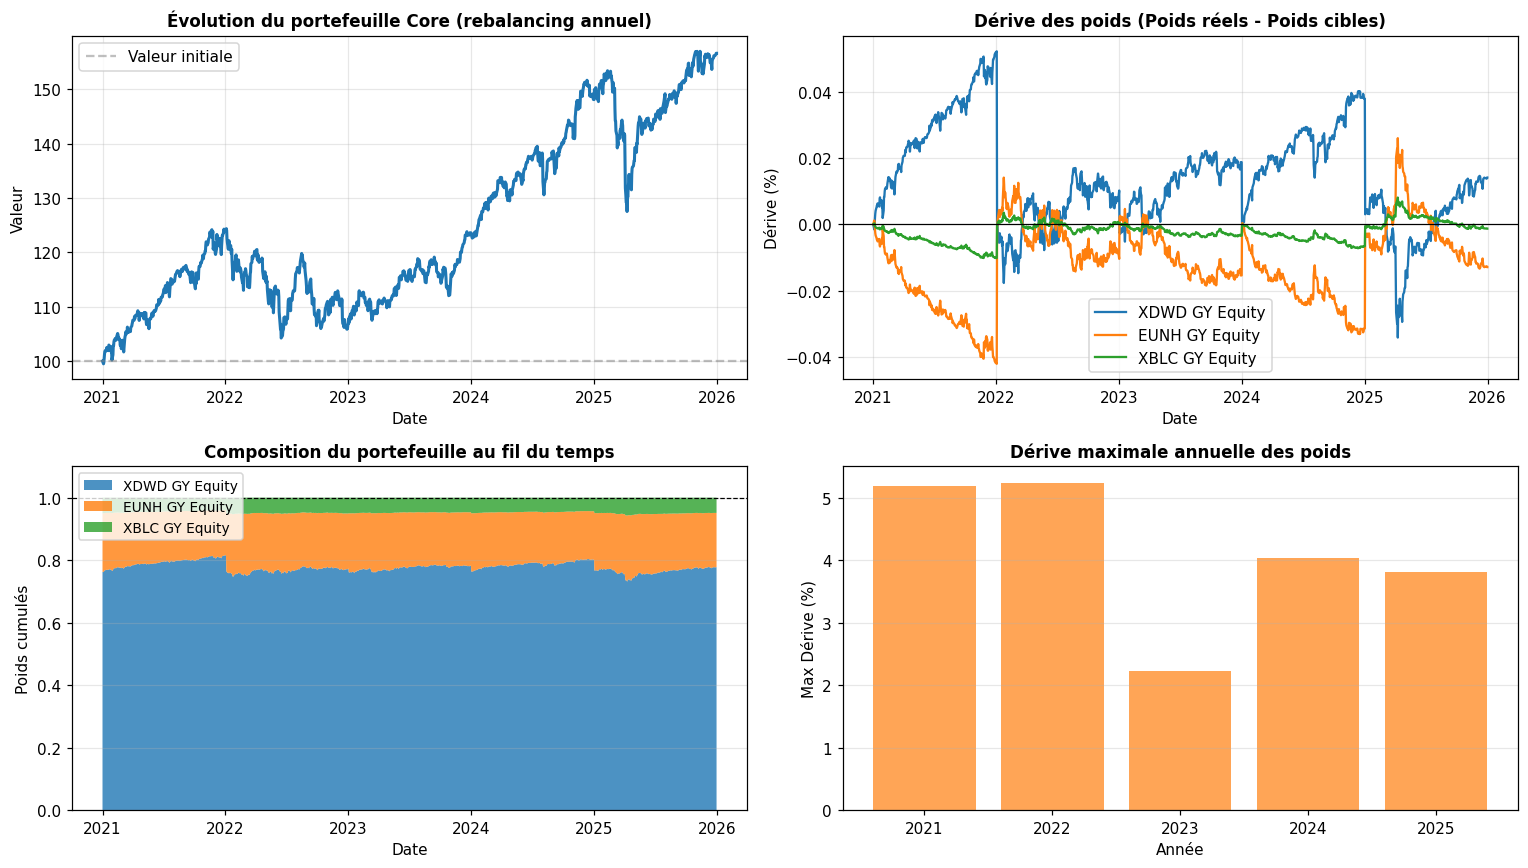

✅ Graphiques sauvegardés : outputs/figures/08_core_rebalancing_analysis.png


In [10]:
# 4. Visualiser l'évolution du portefeuille et des poids
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Déterminer le label de fréquence en français
freq_labels = {
    'daily': 'quotidien',
    'weekly': 'hebdomadaire',
    'monthly': 'mensuel',
    'quarterly': 'trimestriel',
    'annual': 'annuel'
}
freq_display = freq_labels.get(config_core['rebalance_frequency'], 'personnalisé')

# Graphique 1: Valeur du portefeuille
ax = axes[0, 0]
ax.plot(portfolio_df.index, portfolio_df['portfolio_value'], linewidth=2, color='#1f77b4')
ax.axhline(config_core['start_value'], color='gray', linestyle='--', alpha=0.5, label='Valeur initiale')
ax.set_title(f"Évolution du portefeuille Core (rebalancing {freq_display})", fontsize=11, fontweight='bold')
ax.set_ylabel('Valeur')
ax.set_xlabel('Date')
ax.grid(alpha=0.3)
ax.legend()

# Graphique 2: Drift des poids par rapport aux cibles
ax = axes[0, 1]
for ticker in tickers:
    drift = weights_df[ticker] - core_weights[ticker]
    ax.plot(weights_df.index, drift, label=ticker, linewidth=1.5)
ax.axhline(0, color='black', linestyle='-', linewidth=0.8)
ax.set_title('Dérive des poids (Poids réels - Poids cibles)', fontsize=11, fontweight='bold')
ax.set_ylabel('Dérive (%)')
ax.set_xlabel('Date')
ax.legend()
ax.grid(alpha=0.3)

# Graphique 3: Composition du portefeuille dans le temps
ax = axes[1, 0]
ax.stackplot(weights_df.index, 
             weights_df[tickers[0]], 
             weights_df[tickers[1]], 
             weights_df[tickers[2]],
             labels=tickers, alpha=0.8)
ax.axhline(1.0, color='black', linestyle='--', linewidth=0.8)
ax.set_title('Composition du portefeuille au fil du temps', fontsize=11, fontweight='bold')
ax.set_ylabel('Poids cumulés')
ax.set_xlabel('Date')
ax.legend(loc='upper left', fontsize=9)
ax.set_ylim([0, 1.1])
ax.grid(alpha=0.3, axis='y')

# Graphique 4: Résumé annuel du drift
ax = axes[1, 1]
weights_df['year'] = weights_df.index.year
annual_drift = []
for year in sorted(weights_df['year'].unique()):
    year_data = weights_df[weights_df['year'] == year]
    max_drift = 0
    for ticker in tickers:
        drift = max(abs(year_data[ticker].max() - core_weights[ticker]),
                   abs(year_data[ticker].min() - core_weights[ticker]))
        max_drift = max(max_drift, drift)
    annual_drift.append({'year': year, 'max_drift': max_drift})

annual_df = pd.DataFrame(annual_drift)
ax.bar(annual_df['year'].astype(str), annual_df['max_drift'] * 100, color='#ff7f0e', alpha=0.7)
ax.set_title('Dérive maximale annuelle des poids', fontsize=11, fontweight='bold')
ax.set_ylabel('Max Dérive (%)')
ax.set_xlabel('Année')
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('outputs/figures/08_core_rebalancing_analysis.png', dpi=160, bbox_inches='tight')
plt.show()

print("✅ Graphiques sauvegardés : outputs/figures/08_core_rebalancing_analysis.png")


In [11]:
# 5. Tableau récapitulatif du rebalancing
print("\n" + "="*80)
print(f"RÉSUMÉ DU REBALANCING ({freq_display.upper()})")
print("="*80)

summary_table = rebalancer.summary_table(weights_df)

# Formater pour affichage
summary_display = pd.DataFrame()
for year in summary_table.index:
    row_data = []
    for ticker in tickers:
        target = summary_table.loc[year, f"{ticker}_target"]
        drift = summary_table.loc[year, f"{ticker}_drift"]
        max_dev = summary_table.loc[year, f"{ticker}_max_dev"]
        row_data.append({
            'année': year,
            'ticker': ticker.replace(' GY Equity', ''),
            'poids_cible': f"{target:.2%}",
            'dérive_max': f"{drift:.2%}",
            'écart_max_cible': f"{max_dev:.2%}"
        })
    summary_display = pd.concat([summary_display, pd.DataFrame(row_data)], ignore_index=True)

display(summary_display.style
    .hide(axis="index")
    .set_table_styles([{'selector': 'th', 'props': [('border', '1px solid black')]}]))

print("\n📊 INTERPRÉTATION :")
print("   - 'dérive_max' : différence entre poids max et min dans la période")
print("   - 'écart_max_cible' : écart maximum par rapport au poids cible")
print(f"   - Les rebalancings ({freq_display}) ramènent les poids aux cibles")

# Afficher les dates de rebalancing
if rebalance_df is not None and len(rebalance_df) > 0:
    print(f"\n🔄 Dates de rebalancing ({freq_display}) : {len(rebalance_df)} opérations")
    for idx, row in rebalance_df.iterrows():
        print(f"   {row['date'].date()} : Portefeuille = {row['portfolio_value_before']:.2f}")
else:
    print(f"\n🔄 Aucun rebalancing {freq_display} dans cette période")



RÉSUMÉ DU REBALANCING (ANNUEL)


année,ticker,poids_cible,dérive_max,écart_max_cible
2021,XDWD,76.33%,5.35%,5.19%
2021,EUNH,18.67%,4.30%,4.18%
2021,XBLC,5.00%,1.05%,1.02%
2022,XDWD,76.33%,7.01%,5.24%
2022,EUNH,18.67%,5.64%,4.22%
2022,XBLC,5.00%,1.38%,1.02%
2023,XDWD,76.33%,2.75%,2.23%
2023,EUNH,18.67%,2.32%,1.85%
2023,XBLC,5.00%,0.44%,0.39%
2024,XDWD,76.33%,4.07%,4.03%



📊 INTERPRÉTATION :
   - 'dérive_max' : différence entre poids max et min dans la période
   - 'écart_max_cible' : écart maximum par rapport au poids cible
   - Les rebalancings (annuel) ramènent les poids aux cibles

🔄 Dates de rebalancing (annuel) : 4 opérations
   2022-01-03 : Portefeuille = 123.90
   2023-01-02 : Portefeuille = 107.67
   2024-01-01 : Portefeuille = 123.64
   2025-01-01 : Portefeuille = 148.18



TRACKING ERROR & IMPACT DU REBALANCING

📊 TRACKING ERROR (Annualisée) : 1.028%
   → Écart-type de la différence quotidienne de rendement entre :
     • Portefeuille avec rebalancing annuel
     • Portefeuille statique (poids fixes)

💰 IMPACT DU REBALANCING SUR LA PERFORMANCE :
   Valeur finale (avec rebalancing annuel)  :   156.66
   Valeur finale (portefeuille statique)          :   162.06
   Différence                                     :    -5.39
   Impact net (rebalancing)                       :   -3.33%
   ⚠️  Le rebalancing a DIMINUÉ la performance

🧾 IMPACT FRAIS DE TRANSACTION :
   Valeur finale brute (avant tx) : 156.70
   Valeur finale nette (après tx) : 156.66
   Drag transaction costs         : -0.02%


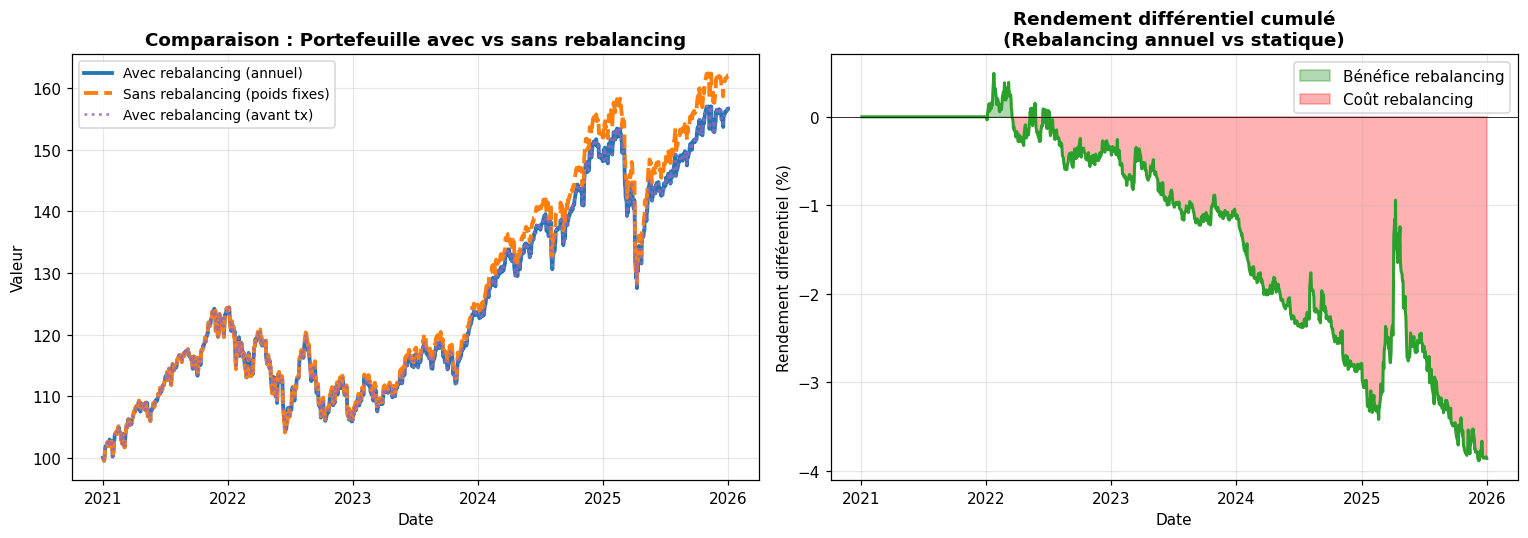


✅ Graphiques sauvegardés : outputs/figures/09_tracking_error_analysis.png


In [12]:
# 6. Calcul de la Tracking Error et impact du rebalancing
print("\n" + "="*80)
print("TRACKING ERROR & IMPACT DU REBALANCING")
print("="*80)

# Tracking error / impact sur la série active portfolio_df['portfolio_value']
te_results = rebalancer.compute_tracking_error(portfolio_df)

print(f"\n📊 TRACKING ERROR (Annualisée) : {te_results['tracking_error']:.3%}")
print(f"   → Écart-type de la différence quotidienne de rendement entre :")
print(f"     • Portefeuille avec rebalancing {freq_display}")
print(f"     • Portefeuille statique (poids fixes)")

print(f"\n💰 IMPACT DU REBALANCING SUR LA PERFORMANCE :")
print(f"   Valeur finale (avec rebalancing {freq_display})  : {te_results['final_value_rebalanced']:>8.2f}")
print(f"   Valeur finale (portefeuille statique)          : {te_results['final_value_static']:>8.2f}")
print(f"   Différence                                     : {te_results['final_value_rebalanced'] - te_results['final_value_static']:>8.2f}")
print(f"   Impact net (rebalancing)                       : {te_results['cumulative_impact']:>7.2f}%")

if te_results['cumulative_impact'] > 0:
    print(f"   ✅ Le rebalancing a AMÉLIORÉ la performance")
else:
    print(f"   ⚠️  Le rebalancing a DIMINUÉ la performance")

# Détail coûts de transaction (si série brute disponible)
if 'portfolio_value_gross' in portfolio_df.columns:
    gross_final = float(portfolio_df['portfolio_value_gross'].iloc[-1])
    net_final = float(portfolio_df['portfolio_value'].iloc[-1])
    tx_drag_pct = (net_final / gross_final - 1.0) * 100 if gross_final > 0 else 0.0
    print(f"\n🧾 IMPACT FRAIS DE TRANSACTION :")
    print(f"   Valeur finale brute (avant tx) : {gross_final:.2f}")
    print(f"   Valeur finale nette (après tx) : {net_final:.2f}")
    print(f"   Drag transaction costs         : {tx_drag_pct:.2f}%")

# Créer un graphique de comparaison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique 1: Évolution comparée
ax = axes[0]
ax.plot(portfolio_df.index, te_results['port_with_rebal'], 
        label=f'Avec rebalancing ({freq_display})', linewidth=2.5, color='#1f77b4')
ax.plot(portfolio_df.index, te_results['port_static'], 
        label='Sans rebalancing (poids fixes)', linewidth=2.5, color='#ff7f0e', linestyle='--')

if 'portfolio_value_gross' in portfolio_df.columns:
    ax.plot(portfolio_df.index, portfolio_df['portfolio_value_gross'],
            label='Avec rebalancing (avant tx)', linewidth=1.8, color='#9467bd', alpha=0.8, linestyle=':')

ax.set_title('Comparaison : Portefeuille avec vs sans rebalancing', fontsize=12, fontweight='bold')
ax.set_ylabel('Valeur')
ax.set_xlabel('Date')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Graphique 2: Rendements différentiels cumulés
ax = axes[1]
cumulative_diff = np.cumsum(te_results['daily_differential_returns'])
ax.plot(portfolio_df.index[1:], cumulative_diff * 100, linewidth=2, color='#2ca02c')
ax.axhline(0, color='black', linestyle='-', linewidth=0.5)
ax.fill_between(portfolio_df.index[1:], 0, cumulative_diff * 100, 
                where=(cumulative_diff >= 0), alpha=0.3, color='green', label='Bénéfice rebalancing')
ax.fill_between(portfolio_df.index[1:], 0, cumulative_diff * 100, 
                where=(cumulative_diff < 0), alpha=0.3, color='red', label='Coût rebalancing')
ax.set_title(f'Rendement différentiel cumulé\n(Rebalancing {freq_display} vs statique)', 
             fontsize=12, fontweight='bold')
ax.set_ylabel('Rendement différentiel (%)')
ax.set_xlabel('Date')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/figures/09_tracking_error_analysis.png', dpi=160, bbox_inches='tight')
plt.show()

print(f"\n✅ Graphiques sauvegardés : outputs/figures/09_tracking_error_analysis.png")


VOLATILITÉ DU CORE & COÛT TOTAL

📊 VOLATILITÉ ROLLING DU CORE (6 mois (126j), annualisée)
   Moyenne    : 10.74%
   Médiane    : 9.80%
   Min        : 6.60%  (2024-04-15)
   Max        : 16.25%  (2025-08-04)
   Écart-type : 2.95%

🔎 Comparaison 6m vs 1 an (annualisée)
   6m  - moyenne: 10.74% | écart-type: 2.95%
   1y  - moyenne: 10.94% | écart-type: 2.30%
   Conseil: 6m = plus réactif, 1y = plus lisse (moins de bruit).


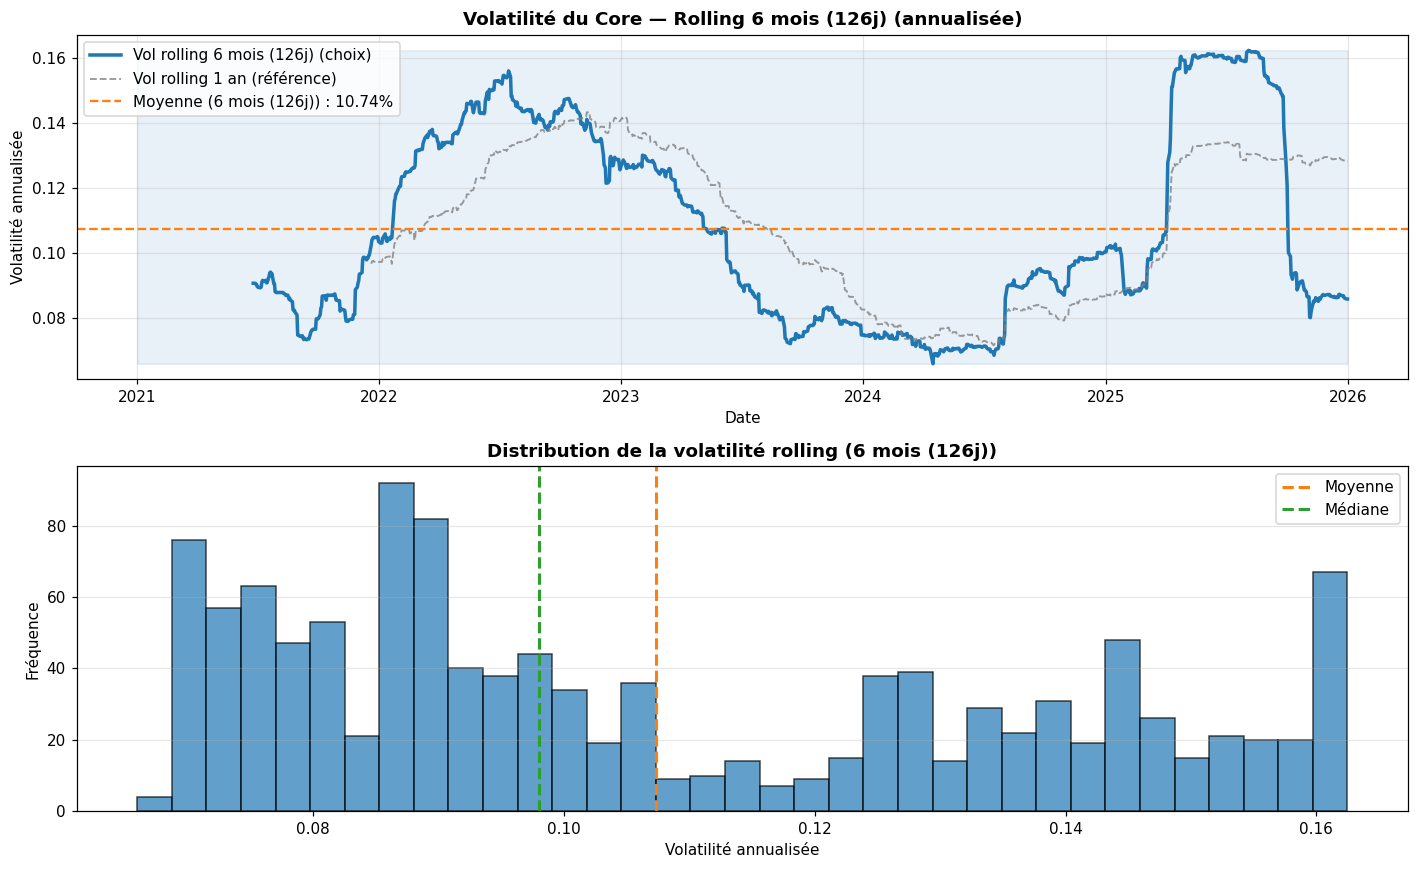


✅ Graphiques volatilité : outputs/figures/10_core_volatility_analysis.png

💰 COÛTS PAR ANNÉE (scénario unique NET TER + TX)
   Fréquence de rebalancing : annuel
   Rebalancings avec frais tx observés : 4


,TER_bps,TX_bps,Total_bps,nb_rebal_tx
year,,,,
2021,11.43,0.00,11.43,0
2022,11.27,1.05,12.32,1
2023,11.31,0.21,11.52,1
2024,11.45,0.38,11.83,1
2025,11.30,0.76,12.06,1


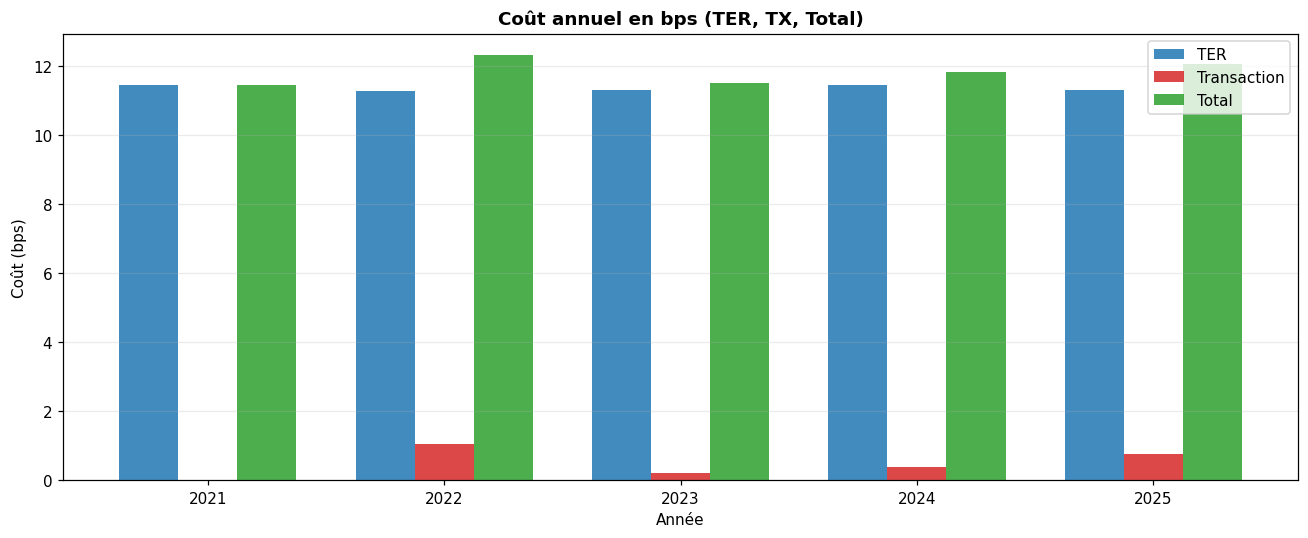

✅ Histogramme coûts annuels : outputs/figures/10c_annual_costs_histogram.png

ℹ️ Les frais tx apparaissent uniquement les jours de rebalancing.
   Le TER, lui, s'applique tous les jours (donc tous les ans), même sans rebalancing.


In [13]:
# 7. Analyse de la Volatilité du Core et du coût total (NET TER + transaction costs)
print("\n" + "="*80)
print("VOLATILITÉ DU CORE & COÛT TOTAL")
print("="*80)

# ─────────────────────────────────────────────────────────────────────────────
# A) Volatilité rolling annualisée du Core (6m ou 1 an)
# ─────────────────────────────────────────────────────────────────────────────

def rolling_volatility_ann(returns_series, window):
    """Calcule la volatilité rolling annualisée."""
    return returns_series.rolling(window).std() * np.sqrt(252)

vol_window_map = {
    '6m': 126,
    '1y': 252,
}
config_core_local = globals().get('config_core', {})
vol_window_choice = config_core_local.get('vol_window', '6m')
if vol_window_choice not in vol_window_map:
    print(f"⚠️ vol_window='{vol_window_choice}' non reconnu. Fallback sur '6m'.")
    vol_window_choice = '6m'

vol_window = vol_window_map[vol_window_choice]
window_label = '6 mois (126j)' if vol_window_choice == '6m' else '1 an (252j)'

returns_for_analysis = globals().get('daily_returns_for_sim', daily_simple_returns)
core_returns = (returns_for_analysis * core_weights_array).sum(axis=1)
vol_rolling = rolling_volatility_ann(core_returns, window=vol_window)
vol_6m = rolling_volatility_ann(core_returns, window=126)
vol_1y = rolling_volatility_ann(core_returns, window=252)

print(f"\n📊 VOLATILITÉ ROLLING DU CORE ({window_label}, annualisée)")
print(f"   Moyenne    : {vol_rolling.mean():.2%}")
print(f"   Médiane    : {vol_rolling.median():.2%}")
print(f"   Min        : {vol_rolling.min():.2%}  ({vol_rolling.idxmin().date()})")
print(f"   Max        : {vol_rolling.max():.2%}  ({vol_rolling.idxmax().date()})")
print(f"   Écart-type : {vol_rolling.std():.2%}")

print("\n🔎 Comparaison 6m vs 1 an (annualisée)")
print(f"   6m  - moyenne: {vol_6m.mean():.2%} | écart-type: {vol_6m.std():.2%}")
print(f"   1y  - moyenne: {vol_1y.mean():.2%} | écart-type: {vol_1y.std():.2%}")
print("   Conseil: 6m = plus réactif, 1y = plus lisse (moins de bruit).")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8))
ax1.plot(vol_rolling.index, vol_rolling, linewidth=2.3, color='#1f77b4',
         label=f'Vol rolling {window_label} (choix)')
ax1.plot(vol_1y.index, vol_1y, linewidth=1.2, color='#7f7f7f', linestyle='--',
         alpha=0.8, label='Vol rolling 1 an (référence)')
ax1.axhline(vol_rolling.mean(), color='#ff7f0e', linestyle='--', linewidth=1.5,
            label=f'Moyenne ({window_label}) : {vol_rolling.mean():.2%}')
ax1.fill_between(vol_rolling.index, vol_rolling.min(), vol_rolling.max(), alpha=0.1, color='#1f77b4')
ax1.set_title(f'Volatilité du Core — Rolling {window_label} (annualisée)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Volatilité annualisée')
ax1.set_xlabel('Date')
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)

ax2.hist(vol_rolling.dropna(), bins=35, color='#1f77b4', alpha=0.7, edgecolor='black')
ax2.axvline(vol_rolling.mean(), color='#ff7f0e', linestyle='--', linewidth=2, label='Moyenne')
ax2.axvline(vol_rolling.median(), color='#2ca02c', linestyle='--', linewidth=2, label='Médiane')
ax2.set_title(f'Distribution de la volatilité rolling ({window_label})', fontsize=12, fontweight='bold')
ax2.set_xlabel('Volatilité annualisée')
ax2.set_ylabel('Fréquence')
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('outputs/figures/10_core_volatility_analysis.png', dpi=160, bbox_inches='tight')
plt.show()

print(f"\n✅ Graphiques volatilité : outputs/figures/10_core_volatility_analysis.png")

# ─────────────────────────────────────────────────────────────────────────────
# B) Coûts par année (TER + transaction)
# ─────────────────────────────────────────────────────────────────────────────

print(f"\n💰 COÛTS PAR ANNÉE (scénario unique NET TER + TX)")
print(f"   Fréquence de rebalancing : {freq_display}")

# Série des coûts de transaction appliqués
if 'tx_cost_pct' in portfolio_df.columns:
    tx_cost_series = portfolio_df['tx_cost_pct'].copy()
else:
    tx_cost_series = pd.Series(0.0, index=portfolio_df.index)

tx_event_mask = tx_cost_series > 0
rebal_count_total = int(tx_event_mask.sum())
print(f"   Rebalancings avec frais tx observés : {rebal_count_total}")

# TER quotidien par actif (drag)
if 'ter_daily_drag' in globals():
    ter_drag_by_ticker = pd.Series({t: float(ter_daily_drag.get(t, 0.0)) for t in tickers})
else:
    ter_annual_decimal_fallback = pd.Series({t: core_ter_map_pct.get(t, 0.0) / 100.0 for t in tickers})
    ter_drag_by_ticker = (1.0 + ter_annual_decimal_fallback) ** (1.0 / 252.0) - 1.0

# TER quotidien portfolio (pondéré par les poids détenus)
weights_for_ter = weights_df[tickers].reindex(portfolio_df.index).ffill().fillna(0.0)
daily_ter_drag = (weights_for_ter * ter_drag_by_ticker.reindex(tickers).values).sum(axis=1)
daily_ter_drag = daily_ter_drag.clip(lower=0.0)

years = sorted(portfolio_df.index.year.unique())
annual_cost_rows = []
for y in years:
    y_mask = portfolio_df.index.year == y

    ter_y = daily_ter_drag.loc[y_mask].values
    tx_y = tx_cost_series.loc[y_mask].values

    # Coût TER annuel: 1 - produit(1/(1+drag_jour))
    ter_cost_pct = float(1.0 - np.prod(1.0 / (1.0 + ter_y))) if len(ter_y) > 0 else 0.0
    # Coût tx annuel: 1 - produit(1-cost_event)
    tx_cost_pct = float(1.0 - np.prod(1.0 - tx_y)) if len(tx_y) > 0 else 0.0
    total_cost_pct = float(1.0 - (1.0 - ter_cost_pct) * (1.0 - tx_cost_pct))

    annual_cost_rows.append({
        'year': y,
        'TER_bps': ter_cost_pct * 10000.0,
        'TX_bps': tx_cost_pct * 10000.0,
        'Total_bps': total_cost_pct * 10000.0,
        'nb_rebal_tx': int(tx_event_mask.loc[y_mask].sum()),
    })

annual_cost_df = pd.DataFrame(annual_cost_rows).set_index('year')
display(annual_cost_df.style.format({
    'TER_bps': '{:.2f}',
    'TX_bps': '{:.2f}',
    'Total_bps': '{:.2f}',
    'nb_rebal_tx': '{:.0f}',
}))

# Histogramme des coûts annuels
x = np.arange(len(annual_cost_df))
w = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - w, annual_cost_df['TER_bps'], width=w, label='TER', color='#1f77b4', alpha=0.85)
ax.bar(x, annual_cost_df['TX_bps'], width=w, label='Transaction', color='#d62728', alpha=0.85)
ax.bar(x + w, annual_cost_df['Total_bps'], width=w, label='Total', color='#2ca02c', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(annual_cost_df.index.astype(str))
ax.set_title('Coût annuel en bps (TER, TX, Total)', fontsize=12, fontweight='bold')
ax.set_xlabel('Année')
ax.set_ylabel('Coût (bps)')
ax.grid(alpha=0.25, axis='y')
ax.legend()

plt.tight_layout()
plt.savefig('outputs/figures/10c_annual_costs_histogram.png', dpi=160, bbox_inches='tight')
plt.show()

print("✅ Histogramme coûts annuels : outputs/figures/10c_annual_costs_histogram.png")

if rebal_count_total == 0:
    print("\nℹ️ Aucun frais tx observé: il n'y a pas eu d'événement de rebalancing dans la période.")
else:
    print("\nℹ️ Les frais tx apparaissent uniquement les jours de rebalancing.")
    print("   Le TER, lui, s'applique tous les jours (donc tous les ans), même sans rebalancing.")


REGIMES DE MARCHE CORE (Vol / Corr / Momentum)
Parametres regime: win=63j, q=(30%,70%), roll_thr=630j, min_regime=7j
Periode utilisee (IS+OOS): 2019-01-01 -> 2026-03-02 (1870 obs)

Calibration IS (2019-01-01 -> 2020-12-31)
Seuils IS fixes: q30=-1.719 | q70=0.623
Seuils rolling fin periode OOS: q_low=-1.611 | q_high=0.941
Switches regime (avant/apres lissage): 127 -> 34
Repartition des regimes lisses (OOS):


,pct
Regime,
Stress,38.7%
Neutre,36.6%
Risk-on,24.7%



Debut OOS: 2021-01-01 | Score=-0.871 | q_low=-1.719 | q_high=0.623 | Regime=Neutre


,RegimeScore,Regime,q_low_roll,q_high_roll,vol_63,corr_eq_bond_63,mom_63
Date,,,,,,,
2026-02-17,-2.100810,Neutre,-1.555246,0.9412,0.070307,-0.082851,0.022158
2026-02-18,-1.942438,Neutre,-1.569281,0.9412,0.070688,-0.080495,0.037902
2026-02-19,-2.198968,Risk-on,-1.573896,0.9412,0.068530,-0.109432,0.027093
2026-02-20,-2.278050,Risk-on,-1.577904,0.9412,0.068564,-0.113505,0.027347
2026-02-23,-2.310949,Risk-on,-1.580533,0.9412,0.067345,-0.137970,0.012031
2026-02-24,-2.245967,Risk-on,-1.585162,0.9412,0.067654,-0.136333,0.016485
2026-02-25,-2.300955,Risk-on,-1.591324,0.9412,0.068453,-0.125801,0.019656
2026-02-26,-2.253411,Risk-on,-1.605858,0.9412,0.068054,-0.152509,0.021918
2026-02-27,-2.504900,Risk-on,-1.608343,0.9412,0.068380,-0.164281,0.018841



Stats descriptives Core par regime :


,N_obs,Perf_ann,Vol_ann,MaxDD
Regime,,,,
Stress,521,+6.81%,13.52%,-17.10%
Neutre,493,+8.31%,9.23%,-8.37%
Risk-on,333,+13.51%,7.98%,-6.14%



Verification coherence economique (moyennes indicateurs) :


,vol_63,mom_63,corr_eq_bond_63
Regime,,,
Stress,13.00%,-0.60%,+0.076
Neutre,9.21%,+3.74%,+0.118
Risk-on,8.03%,+4.94%,-0.033


Attendu: Stress = vol haute & momentum negatif; Risk-on = vol basse & momentum positif.


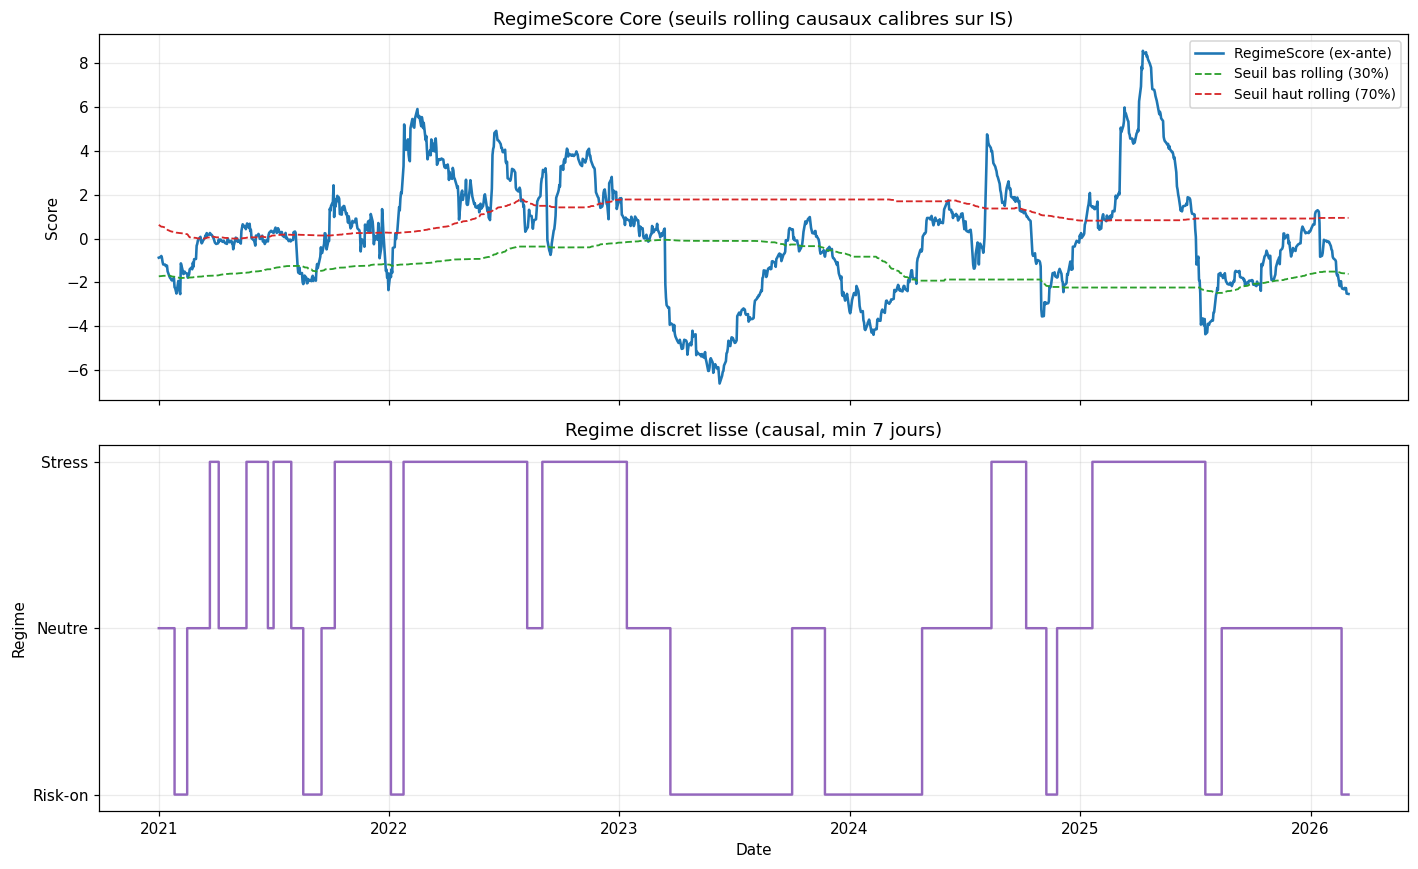


Graphique regimes : outputs/figures/10d_regime_score_core.png
Exports : outputs/regime_core_daily.csv, outputs/regime_core_stats.csv


In [14]:
# 8. Indicateur de regime de marche (base sur la poche Core uniquement)
print("\n" + "=" * 80)
print("REGIMES DE MARCHE CORE (Vol / Corr / Momentum)")
print("=" * 80)

# -----------------------------------------------------------------------------
# Objectif
# Construire un Regime Score simple et robuste pour comite d'investissement :
#   RegimeScore = Vol_norm + Corr_norm - Momentum_norm
# Version STRICTEMENT causale (sans forward-looking) :
# - Score utilise pour classer la date t = information disponible a t-1
# - Seuils rolling a t = estimes avec historique jusqu'a t-1
# - Lissage de regime causal (aucune lecture du futur)
# -----------------------------------------------------------------------------

# Parametres (utilisateur)
regime_cfg = {
    'indicator_window_days': 63,         # Fenetre indicateurs (vol/corr/mom)
    'zscore_window_days': 315,           # Fenetre z-score
    'zscore_min_periods': 189,           # Min obs pour z-score
    'rolling_threshold_days': 630,       # 30 mois de bourse ~ 630 jours
    'threshold_low_q': 0.30,             # Quantile bas (ex: 0.30 = 30%)
    'threshold_high_q': 0.70,            # Quantile haut (ex: 0.70 = 70%)
    'is_start': '2019-01-01',            # Debut periode train
    'is_end': '2020-12-31',              # Fin periode train
    'oos_start': '2021-01-01',           # Debut periode OOS a afficher
    'min_regime_days': 7,                # Lissage anti-switching (causal)
}

print(
    f"Parametres regime: win={regime_cfg['indicator_window_days']}j, "
    f"q=({regime_cfg['threshold_low_q']:.0%},{regime_cfg['threshold_high_q']:.0%}), "
    f"roll_thr={regime_cfg['rolling_threshold_days']}j, min_regime={regime_cfg['min_regime_days']}j"
)

# 1) Construire une base COMPLETE (IS + OOS) pour eviter les trous en debut 2021
# Rendements ETF full sample depuis le fichier deja charge en amont (log-returns)
if 'daily_returns_df' not in globals():
    raise ValueError("Variable daily_returns_df absente. Execute d'abord la cellule de simulation Core.")

required_cols = ['XDWD GY Equity', 'EUNH GY Equity', 'XBLC GY Equity']
missing_cols = [c for c in required_cols if c not in daily_returns_df.columns]
if missing_cols:
    raise ValueError(f"Colonnes ETF manquantes dans daily_returns_df: {missing_cols}")

full_log = daily_returns_df[required_cols].copy().sort_index()
full_simple = np.expm1(full_log)

# Appliquer le meme net TER sur toute l'histoire (coherent avec la NAV OOS)
ter_annual_decimal = pd.Series({t: core_ter_map_pct.get(t, 0.0) / 100.0 for t in required_cols})
ter_daily_drag_full = (1.0 + ter_annual_decimal) ** (1.0 / 252.0) - 1.0

full_net = full_simple.copy()
for t in required_cols:
    full_net[t] = (1.0 + full_simple[t]) / (1.0 + ter_daily_drag_full[t]) - 1.0

# Core return reconstruit sur toute la periode avec les poids cibles statiques
core_weights_series = pd.Series(core_weights)
core_ret_full = (full_net[required_cols] * core_weights_series.reindex(required_cols).values).sum(axis=1)
core_ret_full = core_ret_full.rename('core_ret')

equity_ret_full = full_net['XDWD GY Equity'].rename('equity_ret')
bonds_ret_full = full_net['EUNH GY Equity'].rename('bonds_ret')

base_full = pd.concat([core_ret_full, equity_ret_full, bonds_ret_full], axis=1).dropna()
base_full = base_full.loc[regime_cfg['is_start']:].copy()

if base_full.empty:
    raise ValueError("Base regime vide apres filtrage des dates.")

print(
    f"Periode utilisee (IS+OOS): {base_full.index.min().date()} -> "
    f"{base_full.index.max().date()} ({len(base_full)} obs)"
)

# 2) Indicateurs rolling (fenetre parametree)
win = int(regime_cfg['indicator_window_days'])
base_full['vol_63'] = base_full['core_ret'].rolling(win, min_periods=win).std() * np.sqrt(252)
base_full['corr_eq_bond_63'] = base_full['equity_ret'].rolling(win, min_periods=win).corr(base_full['bonds_ret'])
base_full['mom_63'] = (1.0 + base_full['core_ret']).rolling(win, min_periods=win).apply(np.prod, raw=True) - 1.0

# 3) Normalisation robuste (z-score rolling)
def rolling_zscore(s: pd.Series, z_win: int, min_p: int) -> pd.Series:
    mu = s.rolling(z_win, min_periods=min_p).mean()
    sigma = s.rolling(z_win, min_periods=min_p).std()
    return (s - mu) / sigma.replace(0, np.nan)

base_full['vol_z'] = rolling_zscore(
    base_full['vol_63'],
    z_win=int(regime_cfg['zscore_window_days']),
    min_p=int(regime_cfg['zscore_min_periods'])
)
base_full['corr_z'] = rolling_zscore(
    base_full['corr_eq_bond_63'],
    z_win=int(regime_cfg['zscore_window_days']),
    min_p=int(regime_cfg['zscore_min_periods'])
)
base_full['mom_z'] = rolling_zscore(
    base_full['mom_63'],
    z_win=int(regime_cfg['zscore_window_days']),
    min_p=int(regime_cfg['zscore_min_periods'])
)

# 4) Score de regime: brut puis version exploitable strictement ex-ante
base_full['RegimeScore_raw'] = base_full['vol_z'] + base_full['corr_z'] - base_full['mom_z']
# A la date t, on n'utilise que l'info disponible a t-1
base_full['RegimeScore'] = base_full['RegimeScore_raw'].shift(1)

# 5) Seuils rolling 2 ans, ancres sur IS (2019-2020), sans forward-looking
low_q = float(regime_cfg['threshold_low_q'])
high_q = float(regime_cfg['threshold_high_q'])
if not (0.0 < low_q < high_q < 1.0):
    raise ValueError("threshold_low_q et threshold_high_q doivent verifier 0 < low < high < 1.")

thr_win = int(regime_cfg['rolling_threshold_days'])
is_mask = (base_full.index >= pd.Timestamp(regime_cfg['is_start'])) & (base_full.index <= pd.Timestamp(regime_cfg['is_end']))
is_scores = base_full.loc[is_mask, 'RegimeScore_raw'].dropna()
if is_scores.empty:
    raise ValueError("Impossible de calibrer les seuils IS: RegimeScore indisponible sur 2019-2020.")

# Seuils de calibration train (constantes de reference)
q_low_is = float(is_scores.quantile(low_q))
q_high_is = float(is_scores.quantile(high_q))

# Seuils rolling causaux: a t, quantiles estimes avec donnees jusqu'a t-1 uniquement
base_full['q_low_roll'] = base_full['RegimeScore_raw'].rolling(thr_win, min_periods=1).quantile(low_q).shift(1)
base_full['q_high_roll'] = base_full['RegimeScore_raw'].rolling(thr_win, min_periods=1).quantile(high_q).shift(1)
base_full['q_low_roll'] = base_full['q_low_roll'].fillna(q_low_is)
base_full['q_high_roll'] = base_full['q_high_roll'].fillna(q_high_is)

# Classification brute (ex-ante)
base_full['Regime_raw'] = 'Neutre'
base_full.loc[base_full['RegimeScore'] <= base_full['q_low_roll'], 'Regime_raw'] = 'Risk-on'
base_full.loc[base_full['RegimeScore'] >= base_full['q_high_roll'], 'Regime_raw'] = 'Stress'

# 6) Lissage anti-switching CAUSAL (sans regarder les labels futurs)
def apply_min_regime_days_causal(regime_series: pd.Series, min_days: int) -> pd.Series:
    if regime_series.empty:
        return regime_series.copy()
    if min_days <= 1:
        return regime_series.copy()

    labels = regime_series.astype(str)
    out = []

    current_regime = labels.iloc[0]
    candidate_regime = None
    candidate_count = 0

    for lbl in labels:
        if lbl == current_regime:
            candidate_regime = None
            candidate_count = 0
            out.append(current_regime)
            continue

        if candidate_regime == lbl:
            candidate_count += 1
        else:
            candidate_regime = lbl
            candidate_count = 1

        if candidate_count >= min_days:
            current_regime = lbl
            candidate_regime = None
            candidate_count = 0

        out.append(current_regime)

    return pd.Series(out, index=regime_series.index, name='Regime')

regime_before_smooth = base_full['Regime_raw'].copy()
base_full['Regime'] = apply_min_regime_days_causal(
    base_full['Regime_raw'],
    min_days=int(regime_cfg['min_regime_days'])
)

switches_raw = int((regime_before_smooth != regime_before_smooth.shift(1)).sum() - 1)
switches_smooth = int((base_full['Regime'] != base_full['Regime'].shift(1)).sum() - 1)

# 7) Restreindre l'affichage / export a la periode OOS
base_df = base_full.loc[regime_cfg['oos_start']:].copy()
if base_df.empty:
    raise ValueError("Aucune donnee regime sur la periode OOS demandee.")

print(f"\nCalibration IS ({regime_cfg['is_start']} -> {regime_cfg['is_end']})")
print(f"Seuils IS fixes: q{int(low_q*100)}={q_low_is:.3f} | q{int(high_q*100)}={q_high_is:.3f}")
print(
    f"Seuils rolling fin periode OOS: "
    f"q_low={base_df['q_low_roll'].iloc[-1]:.3f} | q_high={base_df['q_high_roll'].iloc[-1]:.3f}"
)
print(f"Switches regime (avant/apres lissage): {switches_raw} -> {switches_smooth}")
print("Repartition des regimes lisses (OOS):")
display((base_df['Regime'].value_counts(normalize=True) * 100).rename('pct').to_frame().style.format('{:.1f}%'))

# Verification explicite du debut OOS (pas de trou)
first_oos = base_df.index.min()
print(
    f"\nDebut OOS: {first_oos.date()} | "
    f"Score={base_df.loc[first_oos, 'RegimeScore']:.3f} | "
    f"q_low={base_df.loc[first_oos, 'q_low_roll']:.3f} | "
    f"q_high={base_df.loc[first_oos, 'q_high_roll']:.3f} | "
    f"Regime={base_df.loc[first_oos, 'Regime']}"
)

# 8) Output series temporelles : score + regime lisse uniquement
regime_output = base_df[['RegimeScore', 'Regime', 'q_low_roll', 'q_high_roll', 'vol_63', 'corr_eq_bond_63', 'mom_63']].copy()
display(regime_output.tail(10))

# 9) Statistiques descriptives par regime (vol, perf, drawdown du Core)
def max_drawdown_from_returns(r: pd.Series) -> float:
    if r.empty:
        return np.nan
    curve = (1.0 + r).cumprod()
    dd = curve / curve.cummax() - 1.0
    return float(dd.min())

stats_rows = []
for regime in ['Stress', 'Neutre', 'Risk-on']:
    r = base_df.loc[base_df['Regime'] == regime, 'core_ret'].dropna()
    n = len(r)
    if n == 0:
        stats_rows.append({
            'Regime': regime,
            'N_obs': 0,
            'Perf_ann': np.nan,
            'Vol_ann': np.nan,
            'MaxDD': np.nan,
        })
        continue

    perf_ann = float((1.0 + r).prod() ** (252.0 / n) - 1.0)
    vol_ann = float(r.std() * np.sqrt(252.0))
    mdd = max_drawdown_from_returns(r)

    stats_rows.append({
        'Regime': regime,
        'N_obs': n,
        'Perf_ann': perf_ann,
        'Vol_ann': vol_ann,
        'MaxDD': mdd,
    })

regime_stats_df = pd.DataFrame(stats_rows).set_index('Regime')
print("\nStats descriptives Core par regime :")
display(regime_stats_df.style.format({
    'N_obs': '{:.0f}',
    'Perf_ann': '{:+.2%}',
    'Vol_ann': '{:.2%}',
    'MaxDD': '{:.2%}',
}))

# 10) Bonus coherence economique
coherence_df = base_df.groupby('Regime')[['vol_63', 'mom_63', 'corr_eq_bond_63']].mean()
coherence_df = coherence_df.reindex(['Stress', 'Neutre', 'Risk-on'])
print("\nVerification coherence economique (moyennes indicateurs) :")
display(coherence_df.style.format({
    'vol_63': '{:.2%}',
    'mom_63': '{:+.2%}',
    'corr_eq_bond_63': '{:+.3f}',
}))
print("Attendu: Stress = vol haute & momentum negatif; Risk-on = vol basse & momentum positif.")

# 11) Visualisation score + regime lisse
regime_num_map = {'Risk-on': -1, 'Neutre': 0, 'Stress': 1}
regime_num = base_df['Regime'].map(regime_num_map)

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

ax = axes[0]
ax.plot(base_df.index, base_df['RegimeScore'], color='#1f77b4', linewidth=1.7, label='RegimeScore (ex-ante)')
ax.plot(base_df.index, base_df['q_low_roll'], color='#2ca02c', linestyle='--', linewidth=1.2,
        label=f"Seuil bas rolling ({int(low_q*100)}%)")
ax.plot(base_df.index, base_df['q_high_roll'], color='#d62728', linestyle='--', linewidth=1.2,
        label=f"Seuil haut rolling ({int(high_q*100)}%)")
ax.set_title('RegimeScore Core (seuils rolling causaux calibres sur IS)')
ax.set_ylabel('Score')
ax.grid(alpha=0.25)
ax.legend(fontsize=9)

ax = axes[1]
ax.step(base_df.index, regime_num, where='post', color='#9467bd', linewidth=1.6)
ax.set_yticks([-1, 0, 1])
ax.set_yticklabels(['Risk-on', 'Neutre', 'Stress'])
ax.set_title(f"Regime discret lisse (causal, min {int(regime_cfg['min_regime_days'])} jours)")
ax.set_xlabel('Date')
ax.set_ylabel('Regime')
ax.grid(alpha=0.25)

plt.tight_layout()
plt.savefig('outputs/figures/10d_regime_score_core.png', dpi=160, bbox_inches='tight')
plt.show()
print("\nGraphique regimes : outputs/figures/10d_regime_score_core.png")

# 12) Export pour integration backtest
regime_output.to_csv('outputs/regime_core_daily.csv')
regime_stats_df.to_csv('outputs/regime_core_stats.csv')
print("Exports : outputs/regime_core_daily.csv, outputs/regime_core_stats.csv")

In [15]:
# 8bis. Optimisation des parametres regime_cfg (strictement causal, IS/OOS fixes)
from itertools import product
import time

print("\n" + "=" * 90)
print("OPTIMISATION REGIME_CFG (qualitative, sans forward-looking)")
print("=" * 90)

t0 = time.perf_counter()

# Garde-fous: on reutilise les fenetres IS/OOS existantes, non modifiables
fixed_is_start = regime_cfg['is_start']
fixed_is_end = regime_cfg['is_end']
fixed_oos_start = regime_cfg['oos_start']

required_cols = ['XDWD GY Equity', 'EUNH GY Equity', 'XBLC GY Equity']
if 'daily_returns_df' not in globals():
    raise ValueError("daily_returns_df absent. Relance les cellules Core avant optimisation.")
if 'core_weights' not in globals():
    raise ValueError("core_weights absent. Relance les cellules Core avant optimisation.")
if 'core_ter_map_pct' not in globals():
    raise ValueError("core_ter_map_pct absent. Relance les cellules Core avant optimisation.")

# Base de rendements core (meme logique de net TER que la cellule regime)
full_log = daily_returns_df[required_cols].copy().sort_index()
full_simple = np.expm1(full_log)
ter_annual_decimal = pd.Series({t: core_ter_map_pct.get(t, 0.0) / 100.0 for t in required_cols})
ter_daily_drag_full = (1.0 + ter_annual_decimal) ** (1.0 / 252.0) - 1.0

full_net = full_simple.copy()
for t in required_cols:
    full_net[t] = (1.0 + full_simple[t]) / (1.0 + ter_daily_drag_full[t]) - 1.0

core_weights_series = pd.Series(core_weights)
core_ret_full = (full_net[required_cols] * core_weights_series.reindex(required_cols).values).sum(axis=1).rename('core_ret')
equity_ret_full = full_net['XDWD GY Equity'].rename('equity_ret')
bonds_ret_full = full_net['EUNH GY Equity'].rename('bonds_ret')

base_template = pd.concat([core_ret_full, equity_ret_full, bonds_ret_full], axis=1).dropna()
base_template = base_template.loc[fixed_is_start:].copy()

is_mask_global = (base_template.index >= pd.Timestamp(fixed_is_start)) & (base_template.index <= pd.Timestamp(fixed_is_end))
oos_mask_global = base_template.index >= pd.Timestamp(fixed_oos_start)


def rolling_zscore_local(s: pd.Series, z_win: int, min_p: int) -> pd.Series:
    mu = s.rolling(z_win, min_periods=min_p).mean()
    sigma = s.rolling(z_win, min_periods=min_p).std()
    return (s - mu) / sigma.replace(0, np.nan)


def apply_min_regime_days_causal_local(regime_series: pd.Series, min_days: int) -> pd.Series:
    if regime_series.empty or min_days <= 1:
        return regime_series.copy()

    labels = regime_series.astype(str)
    out = []
    current_regime = labels.iloc[0]
    candidate_regime = None
    candidate_count = 0

    for lbl in labels:
        if lbl == current_regime:
            candidate_regime = None
            candidate_count = 0
            out.append(current_regime)
            continue

        if candidate_regime == lbl:
            candidate_count += 1
        else:
            candidate_regime = lbl
            candidate_count = 1

        if candidate_count >= min_days:
            current_regime = lbl
            candidate_regime = None
            candidate_count = 0

        out.append(current_regime)

    return pd.Series(out, index=regime_series.index, name='Regime')


def evaluate_period_quality(df: pd.DataFrame, period_mask: pd.Series) -> dict:
    sub = df.loc[period_mask, ['Regime', 'core_ret']].dropna().copy()
    if len(sub) < 180:
        return {'ok': False, 'score': -1e9}

    counts = sub['Regime'].value_counts(normalize=True)
    target = 1.0 / 3.0

    g = sub.groupby('Regime')['core_ret']
    ret_ann = g.apply(lambda x: (1.0 + x).prod() ** (252.0 / len(x)) - 1.0 if len(x) > 0 else np.nan)
    vol_ann = g.std() * np.sqrt(252.0)

    rr = {k: float(ret_ann.get(k, np.nan)) for k in ['Risk-on', 'Neutre', 'Stress']}
    vv = {k: float(vol_ann.get(k, np.nan)) for k in ['Risk-on', 'Neutre', 'Stress']}

    if any(np.isnan(v) for v in rr.values()) or any(np.isnan(v) for v in vv.values()):
        return {'ok': False, 'score': -1e9}

    ret_order_ok = rr['Risk-on'] > rr['Neutre'] > rr['Stress']
    vol_order_ok = vv['Stress'] > vv['Neutre'] > vv['Risk-on']

    base_std = float(sub['core_ret'].std())
    if base_std <= 0 or np.isnan(base_std):
        return {'ok': False, 'score': -1e9}

    ret_gap = (rr['Risk-on'] - rr['Stress']) / (base_std * np.sqrt(252.0))
    vol_gap = (vv['Stress'] - vv['Risk-on']) / (base_std * np.sqrt(252.0))

    abs_thr = float(sub['core_ret'].abs().quantile(0.80))
    hv = sub[sub['core_ret'].abs() >= abs_thr]
    stress_capture = float((hv['Regime'] == 'Stress').mean()) if len(hv) > 0 else 0.0

    up_thr = float(sub['core_ret'].quantile(0.80))
    hu = sub[sub['core_ret'] >= up_thr]
    riskon_capture = float((hu['Regime'] == 'Risk-on').mean()) if len(hu) > 0 else 0.0

    balance_penalty = sum((float(counts.get(r, 0.0)) - target) ** 2 for r in ['Stress', 'Neutre', 'Risk-on'])

    switches = int((sub['Regime'] != sub['Regime'].shift(1)).sum() - 1)
    years = max((sub.index.max() - sub.index.min()).days / 365.25, 0.5)
    switches_per_year = switches / years

    score = 0.0
    score += 2.0 if ret_order_ok else -2.0
    score += 2.0 if vol_order_ok else -2.0
    score += float(np.clip(ret_gap, -3.0, 3.0))
    score += float(np.clip(vol_gap, -3.0, 3.0))
    score += 1.5 * stress_capture
    score += 1.5 * riskon_capture
    score -= 2.0 * balance_penalty
    score -= 0.08 * abs(switches_per_year - 10.0)

    return {
        'ok': True,
        'score': score,
        'ret_order_ok': ret_order_ok,
        'vol_order_ok': vol_order_ok,
        'ret_gap': ret_gap,
        'vol_gap': vol_gap,
        'stress_capture': stress_capture,
        'riskon_capture': riskon_capture,
        'switches_per_year': switches_per_year,
        'pct_stress': float(counts.get('Stress', 0.0)),
        'pct_neutre': float(counts.get('Neutre', 0.0)),
        'pct_riskon': float(counts.get('Risk-on', 0.0)),
    }


# Grille de recherche en MOIS (plus interpretable qualitativement)
TRADING_DAYS_PER_MONTH = 21

def months_to_days(m: int) -> int:
    return int(m * TRADING_DAYS_PER_MONTH)

indicator_window_months_grid = [2, 3, 4]      # 42, 63, 84 jours
zscore_window_months_grid = [9, 12, 15, 18]   # 189, 252, 315, 378 jours
zscore_min_frac_grid = [0.45, 0.50, 0.60]
rolling_threshold_months_grid = [18, 24, 30]  # 378, 504, 630 jours
quantile_pairs_grid = [(0.25, 0.75), (0.30, 0.70), (0.35, 0.65)]
min_regime_days_grid = [7, 10, 14]

combos = list(product(
    indicator_window_months_grid,
    zscore_window_months_grid,
    zscore_min_frac_grid,
    rolling_threshold_months_grid,
    quantile_pairs_grid,
    min_regime_days_grid,
))

print(f"Combinaisons testées: {len(combos)}")

results = []

for ind_m, z_m, z_frac, thr_m, q_pair, min_days in combos:
    low_q, high_q = q_pair

    ind_win = months_to_days(ind_m)
    z_win = months_to_days(z_m)
    thr_win = months_to_days(thr_m)

    min_p = max(30, int(round(z_win * z_frac)))
    min_p = min(min_p, z_win)

    df = base_template.copy()

    # 1) Features
    df['vol_63'] = df['core_ret'].rolling(ind_win, min_periods=ind_win).std() * np.sqrt(252)
    df['corr_eq_bond_63'] = df['equity_ret'].rolling(ind_win, min_periods=ind_win).corr(df['bonds_ret'])
    df['mom_63'] = (1.0 + df['core_ret']).rolling(ind_win, min_periods=ind_win).apply(np.prod, raw=True) - 1.0

    # 2) Z-scores
    df['vol_z'] = rolling_zscore_local(df['vol_63'], z_win=z_win, min_p=min_p)
    df['corr_z'] = rolling_zscore_local(df['corr_eq_bond_63'], z_win=z_win, min_p=min_p)
    df['mom_z'] = rolling_zscore_local(df['mom_63'], z_win=z_win, min_p=min_p)

    # 3) Score causal
    df['RegimeScore_raw'] = df['vol_z'] + df['corr_z'] - df['mom_z']
    df['RegimeScore'] = df['RegimeScore_raw'].shift(1)

    # 4) Seuils causaux
    is_scores = df.loc[is_mask_global, 'RegimeScore_raw'].dropna()
    if len(is_scores) < 120:
        continue

    q_low_is = float(is_scores.quantile(low_q))
    q_high_is = float(is_scores.quantile(high_q))

    df['q_low_roll'] = df['RegimeScore_raw'].rolling(thr_win, min_periods=1).quantile(low_q).shift(1).fillna(q_low_is)
    df['q_high_roll'] = df['RegimeScore_raw'].rolling(thr_win, min_periods=1).quantile(high_q).shift(1).fillna(q_high_is)

    # 5) Regime brut + lisse causal
    df['Regime_raw'] = 'Neutre'
    df.loc[df['RegimeScore'] <= df['q_low_roll'], 'Regime_raw'] = 'Risk-on'
    df.loc[df['RegimeScore'] >= df['q_high_roll'], 'Regime_raw'] = 'Stress'
    df['Regime'] = apply_min_regime_days_causal_local(df['Regime_raw'], min_days=min_days)

    # 6) Evaluation qualitative IS/OOS
    met_is = evaluate_period_quality(df, is_mask_global)
    met_oos = evaluate_period_quality(df, oos_mask_global)
    if not met_is['ok'] or not met_oos['ok']:
        continue

    global_score = 0.35 * met_is['score'] + 0.65 * met_oos['score']

    results.append({
        'indicator_window_months': ind_m,
        'zscore_window_months': z_m,
        'rolling_threshold_months': thr_m,
        'indicator_window_days': ind_win,
        'zscore_window_days': z_win,
        'zscore_min_periods': min_p,
        'rolling_threshold_days': thr_win,
        'threshold_low_q': low_q,
        'threshold_high_q': high_q,
        'min_regime_days': min_days,
        'score_is': met_is['score'],
        'score_oos': met_oos['score'],
        'score_global': global_score,
        'ret_order_oos': met_oos['ret_order_ok'],
        'vol_order_oos': met_oos['vol_order_ok'],
        'stress_capture_oos': met_oos['stress_capture'],
        'riskon_capture_oos': met_oos['riskon_capture'],
        'switches_per_year_oos': met_oos['switches_per_year'],
        'pct_stress_oos': met_oos['pct_stress'],
        'pct_neutre_oos': met_oos['pct_neutre'],
        'pct_riskon_oos': met_oos['pct_riskon'],
    })

if not results:
    raise RuntimeError("Aucune combinaison valide. Elargir la grille ou verifier les donnees.")

res_df = pd.DataFrame(results).sort_values('score_global', ascending=False).reset_index(drop=True)

print("\nTop 10 configurations (score_global):")
cols_show = [
    'indicator_window_months', 'zscore_window_months', 'rolling_threshold_months',
    'zscore_min_periods', 'threshold_low_q', 'threshold_high_q', 'min_regime_days',
    'score_is', 'score_oos', 'score_global', 'ret_order_oos', 'vol_order_oos',
    'stress_capture_oos', 'riskon_capture_oos', 'switches_per_year_oos'
]
display(res_df[cols_show].head(10))

best = res_df.iloc[0]
best_regime_cfg = {
    'indicator_window_days': int(best['indicator_window_days']),
    'zscore_window_days': int(best['zscore_window_days']),
    'zscore_min_periods': int(best['zscore_min_periods']),
    'rolling_threshold_days': int(best['rolling_threshold_days']),
    'threshold_low_q': float(best['threshold_low_q']),
    'threshold_high_q': float(best['threshold_high_q']),
    'is_start': fixed_is_start,
    'is_end': fixed_is_end,
    'oos_start': fixed_oos_start,
    'min_regime_days': int(best['min_regime_days']),
}

print("\nMeilleure configuration recommandee (IS/OOS fixes):")
print(
    f"  indicator_window: {int(best['indicator_window_months'])} mois ({int(best['indicator_window_days'])}j)\n"
    f"  zscore_window: {int(best['zscore_window_months'])} mois ({int(best['zscore_window_days'])}j)\n"
    f"  rolling_threshold: {int(best['rolling_threshold_months'])} mois ({int(best['rolling_threshold_days'])}j)"
)
for k, v in best_regime_cfg.items():
    if k in {'indicator_window_days', 'zscore_window_days', 'rolling_threshold_days'}:
        continue
    print(f"  {k}: {v}")

print("\nQualite OOS de la meilleure config:")
print(f"  score_oos           : {best['score_oos']:.3f}")
print(f"  ret_order_oos       : {bool(best['ret_order_oos'])}")
print(f"  vol_order_oos       : {bool(best['vol_order_oos'])}")
print(f"  stress_capture_oos  : {best['stress_capture_oos']:.1%}")
print(f"  riskon_capture_oos  : {best['riskon_capture_oos']:.1%}")
print(f"  switches/year OOS   : {best['switches_per_year_oos']:.1f}")
print(
    "  repartition OOS     : "
    f"Stress={best['pct_stress_oos']:.1%}, "
    f"Neutre={best['pct_neutre_oos']:.1%}, "
    f"Risk-on={best['pct_riskon_oos']:.1%}"
)

elapsed = time.perf_counter() - t0
print("\nTemps de calcul:")
print(f"  elapsed: {elapsed:.2f}s")
print(f"  vitesse: {len(combos) / elapsed:.1f} combinaisons/s")
print("  Note: c'est rapide car calcul vectorise pandas + echantillon ~1.9k lignes.")


OPTIMISATION REGIME_CFG (qualitative, sans forward-looking)
Combinaisons testées: 972



Top 10 configurations (score_global):


,indicator_window_months,zscore_window_months,rolling_threshold_months,zscore_min_periods,threshold_low_q,threshold_high_q,min_regime_days,score_is,score_oos,score_global,ret_order_oos,vol_order_oos,stress_capture_oos,riskon_capture_oos,switches_per_year_oos
0,3,15,30,189,0.30,0.70,7,8.181710,5.873480,6.681360,True,True,0.570370,0.185185,5.422587
1,3,18,18,189,0.30,0.70,7,8.181710,5.671733,6.550225,True,True,0.544444,0.192593,4.841596
2,3,18,24,170,0.30,0.70,10,6.005170,6.659805,6.430683,True,True,0.618519,0.188889,3.485949
3,3,15,24,142,0.25,0.75,10,6.031207,6.356987,6.242964,True,True,0.522222,0.125926,3.873277
4,3,15,30,142,0.25,0.75,10,6.031207,6.210918,6.148019,True,True,0.470370,0.114815,4.066941
5,3,18,18,170,0.30,0.70,7,6.640276,5.658707,6.002256,True,True,0.548148,0.192593,4.841596
6,3,18,30,170,0.30,0.70,10,6.005170,5.811672,5.879396,True,True,0.548148,0.144444,4.260604
7,3,15,18,142,0.25,0.75,10,6.031207,5.539502,5.711599,True,True,0.496296,0.166667,3.873277
8,3,18,24,189,0.25,0.75,7,4.255839,6.446877,5.680014,True,True,0.518519,0.137037,4.066941
9,4,18,24,189,0.35,0.65,10,3.291501,6.854040,5.607151,True,True,0.648148,0.244444,3.098621



Meilleure configuration recommandee (IS/OOS fixes):
  indicator_window: 3 mois (63j)
  zscore_window: 15 mois (315j)
  rolling_threshold: 30 mois (630j)
  zscore_min_periods: 189
  threshold_low_q: 0.3
  threshold_high_q: 0.7
  is_start: 2019-01-01
  is_end: 2020-12-31
  oos_start: 2021-01-01
  min_regime_days: 7

Qualite OOS de la meilleure config:
  score_oos           : 5.873
  ret_order_oos       : True
  vol_order_oos       : True
  stress_capture_oos  : 57.0%
  riskon_capture_oos  : 18.5%
  switches/year OOS   : 5.4
  repartition OOS     : Stress=38.7%, Neutre=36.6%, Risk-on=24.7%

Temps de calcul:
  elapsed: 25.82s
  vitesse: 37.6 combinaisons/s
  Note: c'est rapide car calcul vectorise pandas + echantillon ~1.9k lignes.


---
## Étape 3 — Sélection des fonds Satellite

**19 fonds** pré-sélectionnés en 3 blocs, chargement centralisé STRAT1+2+3.  
Filtres : Beta initial, AUM/Devise, Vol/Frais, Sharpe/Alpha/Corr, Skew/Kurt, Pairwise.

In [16]:
import numpy as np
import pandas as pd
from pathlib import Path

from src.satellite_level0_filter import filter_satellite_level0
from src.satellite_data_loader import (
    load_all_satellite_prices,
    preprocess_prices,
    align_prices_with_core,
)
from src.satellite_level1_beta_filter_final import apply_level1_filter_corrected
from src.satellite_level2_filter import apply_level2_alpha_expense

# ======================================================================
# ETAPE 3 - SATELLITE GLISSANT
# 1) Revue annuelle du pool (top N par strat sur 12 mois glissants)
# 2) Revue trimestrielle des 1-2 fonds actifs (switch si meilleur)
# 3) Scoring custom par bloc integre directement dans cette etape
# ======================================================================

STEP3_PARAMS = {
    "level0": {
        "devise": ["Euro", "Euro (BEF)"],
        "min_aum_usd_m": 50.0,
    },
    "data": {
        "ffill_limit": 5,
        "min_obs_prices": 50,
    },
    "level1": {
        "rolling_window": 126,
        "median_beta_max": 0.35,
        "q75_beta_max": 0.55,
        "pass_ratio_min": 0.80,
    },
    "level2": {
        "expense_col": "Ratio des dépenses",
        "alpha_weight": 0.60,
        "expense_weight": 0.40,
        "min_obs_alpha": 60,
        "stress_quantile": 0.20,
        "keep_top_per_strat": 7,
    },
    "bans": {
        # Bannis en Bloc 3 par nom de feuille (commodities + inflation)
        "strat3_banned_sheet_names": [
            "Energie",
            "Métaux industriels",
            "Métaux précieux",
            "Protégé contre l'inflation",
        ],
    },
    "rolling": {
        "oos_start": "2021-01-01",
        "oos_end": "2025-12-31",
        "annual_review_month": 1,
        "annual_review_day": 1,
        "quarterly_freq": "QS",
        "lookback_years_for_score": 1,
        "quarterly_rescore_pool_1y": True,
    },
    "final": {
        "min_per_strat": 1,
        "max_per_strat": 2,
        "corr_max_for_second": 0.70,
        "score_gap_for_second": 0.35,
        "switch_score_buffer": 0.05,
    },
}


def _safe_strat_group(scores_df):
    if scores_df is None or scores_df.empty or "Strat" not in scores_df.columns:
        return []
    return scores_df.groupby("Strat")


def _detect_ticker_col(df):
    for c in ["Ticker", "ticker"]:
        if c in df.columns:
            return c
    return None


def _extract_tickers_from_price_sheet(price_file, sheet_name):
    try:
        df = pd.read_excel(price_file, sheet_name=sheet_name)
    except Exception:
        return set()

    tickers = set()
    for i in range(0, max(df.shape[1] - 1, 0), 2):
        col_ticker = str(df.columns[i]).strip()
        if "Equity" in col_ticker:
            tickers.add(col_ticker)
    return tickers


def _build_banned_tickers_by_sheet(cfg, data_dir="data"):
    banned_sheets = cfg.get("bans", {}).get("strat3_banned_sheet_names", [])
    if not banned_sheets:
        return set()

    price_file = Path(data_dir) / "STRAT3_price.xlsx"
    banned_tickers = set()
    for sh in banned_sheets:
        banned_tickers |= _extract_tickers_from_price_sheet(price_file, sh)
    return banned_tickers


def _safe_zscore_series(s):
    s = pd.to_numeric(s, errors="coerce")
    mu = s.mean()
    sd = s.std(ddof=0)
    if pd.isna(sd) or sd == 0:
        return pd.Series(0.0, index=s.index)
    return ((s - mu) / sd).fillna(0.0)


def _ann_return(s):
    s = pd.to_numeric(s, errors="coerce").dropna()
    if len(s) == 0:
        return np.nan
    return (1.0 + s).prod() ** (252.0 / len(s)) - 1.0


def _ann_vol(s):
    s = pd.to_numeric(s, errors="coerce").dropna()
    if len(s) == 0:
        return np.nan
    return s.std() * np.sqrt(252.0)


def _sortino0(s):
    s = pd.to_numeric(s, errors="coerce").dropna()
    if len(s) == 0:
        return np.nan
    downside = s[s < 0]
    dd = downside.std() * np.sqrt(252.0)
    ar = _ann_return(s)
    if pd.isna(ar) or pd.isna(dd) or dd <= 0:
        return np.nan
    return ar / dd


def _maxdd_abs(s):
    s = pd.to_numeric(s, errors="coerce").dropna()
    if len(s) == 0:
        return np.nan
    nav = (1.0 + s).cumprod()
    dd = nav / nav.cummax() - 1.0
    return abs(dd.min())


def _score_pool_by_bloc_formulas(pool_scores, prices_win, core_win, cfg):
    if pool_scores.empty:
        return pool_scores

    out = pool_scores.copy()
    if "ticker" not in out.columns:
        tcol = _detect_ticker_col(out)
        if tcol is None:
            return out
        out["ticker"] = out[tcol].astype(str)
    else:
        out["ticker"] = out["ticker"].astype(str)

    if "Strat" not in out.columns:
        return out

    core_s = pd.to_numeric(core_win, errors="coerce").dropna()
    if core_s.empty:
        return out

    stress_q = float(cfg["level2"].get("stress_quantile", 0.20))
    stress_days = core_s[core_s <= core_s.quantile(stress_q)].index
    min_obs = int(cfg["level2"].get("min_obs_alpha", 60))

    metrics_rows = []
    for t in out["ticker"].dropna().unique():
        if t not in prices_win.columns:
            continue
        px = pd.to_numeric(prices_win[t], errors="coerce").dropna()
        fund_ret = np.log(px).diff().dropna()
        aligned = pd.concat([fund_ret.rename("fund"), core_s.rename("core")], axis=1).dropna()
        if len(aligned) < min_obs:
            continue

        core_var = aligned["core"].var()
        beta = aligned["fund"].cov(aligned["core"]) / core_var if pd.notna(core_var) and core_var > 0 else np.nan

        beta_stress = np.nan
        stress_aligned = aligned.loc[aligned.index.intersection(stress_days)]
        if len(stress_aligned) >= 2:
            core_var_stress = stress_aligned["core"].var()
            if pd.notna(core_var_stress) and core_var_stress > 0:
                beta_stress = stress_aligned["fund"].cov(stress_aligned["core"]) / core_var_stress

        # Regle demandee: Bloc 1 utilise beta_stress, fallback beta normal si stress indisponible.
        beta_bloc1 = beta_stress if pd.notna(beta_stress) else beta

        corr = aligned["fund"].corr(aligned["core"])
        ret_ann = _ann_return(aligned["fund"])
        vol = _ann_vol(aligned["fund"])
        sharpe = ret_ann / vol if pd.notna(ret_ann) and pd.notna(vol) and vol > 0 else np.nan
        sortino = _sortino0(aligned["fund"])
        maxdd_abs = _maxdd_abs(aligned["fund"])
        skewness = aligned["fund"].skew()
        kurtosis = aligned["fund"].kurt()

        core_ret_ann = _ann_return(aligned["core"])
        alpha = ret_ann - beta * core_ret_ann if pd.notna(ret_ann) and pd.notna(beta) and pd.notna(core_ret_ann) else np.nan

        rs = aligned.loc[aligned.index.intersection(stress_days), "fund"]
        return_stress = _ann_return(rs) if len(rs) > 0 else np.nan

        metrics_rows.append(
            {
                "ticker": t,
                "beta": beta,
                "beta_stress": beta_stress,
                "beta_bloc1": beta_bloc1,
                "corr": corr,
                "return_stress": return_stress,
                "skewness": skewness,
                "maxdd_abs": maxdd_abs,
                "alpha_annual": alpha,
                "sharpe": sharpe,
                "sortino": sortino,
                "vol": vol,
                "ret_ann": ret_ann,
                "kurtosis": kurtosis,
            }
        )

    if not metrics_rows:
        return out

    m = pd.DataFrame(metrics_rows)
    out = out.merge(m, on="ticker", how="left", suffixes=("", "_new"))

    if "alpha_annual_new" in out.columns:
        out["alpha_annual"] = out["alpha_annual_new"].combine_first(pd.to_numeric(out.get("alpha_annual"), errors="coerce"))
    if "beta_new" in out.columns:
        out["beta"] = out["beta_new"].combine_first(pd.to_numeric(out.get("beta"), errors="coerce"))
    if "corr_new" in out.columns:
        out["corr"] = out["corr_new"].combine_first(pd.to_numeric(out.get("corr"), errors="coerce"))

    parts = []
    for strat, g in out.groupby("Strat", dropna=False):
        g = g.copy()
        su = str(strat).upper()

        z_beta_b1 = _safe_zscore_series(g["beta_bloc1"].abs())
        z_corr = _safe_zscore_series(g["corr"])
        z_corr_abs = _safe_zscore_series(g["corr"].abs())
        z_stress = _safe_zscore_series(g["return_stress"])
        z_skew = _safe_zscore_series(g["skewness"])
        z_mdd = _safe_zscore_series(g["maxdd_abs"])

        z_alpha = _safe_zscore_series(g["alpha_annual"])
        z_expense = _safe_zscore_series(-pd.to_numeric(g.get("expense_pct"), errors="coerce"))
        z_sh = _safe_zscore_series(g["sharpe"])
        z_so = _safe_zscore_series(g["sortino"])
        z_vol = _safe_zscore_series(g["vol"])

        z_ret = _safe_zscore_series(g["ret_ann"])
        z_kurt = _safe_zscore_series(g["kurtosis"])

        if su == "STRAT1":
            g["score_custom"] = (
                -0.40 * z_beta_b1
                -0.20 * z_corr_abs
                +0.20 * z_stress
                +0.15 * z_sh
                -0.15 * z_mdd
            )
        elif su == "STRAT2":
            g["score_custom"] = (
                +0.60 * z_alpha
                +0.30 * z_expense
                +0.10 * z_sh
                -0.05 * z_corr_abs
            )
        elif su == "STRAT3":
            g["score_custom"] = (
                +0.55 * z_alpha
                +0.35 * z_expense
                +0.10 * z_ret
                -0.05 * z_kurt
            )
        else:
            g["score_custom"] = np.nan

        g["score_level2"] = g["score_custom"].combine_first(pd.to_numeric(g.get("score_level2"), errors="coerce"))
        parts.append(g)

    out = pd.concat(parts, ignore_index=True)
    out = out.drop(columns=[c for c in out.columns if c.endswith("_new")])
    return out


def _pick_ranked_for_strat(g, prices_window, params_final):
    p = params_final
    g2 = g.sort_values("score_level2", ascending=False).reset_index(drop=True)
    if g2.empty:
        return []

    picks = [
        {
            "ticker": str(g2.iloc[0]["ticker"]),
            "rank_in_strat": 1,
            "score_level2": float(g2.iloc[0]["score_level2"]),
            "selected_reason": "top1",
            "pair_corr": np.nan,
            "score_gap_vs_top1": 0.0,
        }
    ]

    if p["max_per_strat"] < 2 or len(g2) < 2:
        return picks

    top1 = g2.iloc[0]
    top2 = g2.iloc[1]
    t1, t2 = str(top1["ticker"]), str(top2["ticker"])

    pair = prices_window[[t1, t2]].copy() if (t1 in prices_window.columns and t2 in prices_window.columns) else pd.DataFrame()
    pair_rets = np.log(pair).diff().dropna() if not pair.empty else pd.DataFrame()
    pair_corr = float(pair_rets[t1].corr(pair_rets[t2])) if len(pair_rets) > 10 else np.nan
    gap = float(top1["score_level2"] - top2["score_level2"])

    cond_corr = (np.isnan(pair_corr) or abs(pair_corr) <= p["corr_max_for_second"])
    cond_gap = (gap <= p["score_gap_for_second"])

    if cond_corr and cond_gap:
        picks.append(
            {
                "ticker": t2,
                "rank_in_strat": 2,
                "score_level2": float(top2["score_level2"]),
                "selected_reason": "top2_diversified",
                "pair_corr": pair_corr,
                "score_gap_vs_top1": gap,
            }
        )
    return picks


def _build_annual_review_dates(prices_idx, cfg):
    start = pd.Timestamp(cfg["rolling"]["oos_start"]).normalize()
    end = pd.Timestamp(cfg["rolling"]["oos_end"]).normalize()
    month = int(cfg["rolling"]["annual_review_month"])
    day = int(cfg["rolling"]["annual_review_day"])

    year_candidates = list(range(start.year, end.year + 1))
    review_dates = []
    for y in year_candidates:
        target = pd.Timestamp(year=y, month=month, day=day)
        valid = prices_idx[prices_idx >= target]
        if len(valid) == 0:
            continue
        d = pd.Timestamp(valid.min()).normalize()
        if d <= end:
            review_dates.append(d)

    return sorted(pd.unique(pd.DatetimeIndex(review_dates)))


def _annual_pool_at_date(review_date, df_level0, prices_all_aligned, core_all_aligned, cfg):
    lookback_years = int(cfg["rolling"]["lookback_years_for_score"])
    calib_end = pd.Timestamp(review_date) - pd.Timedelta(days=1)
    calib_start = calib_end - pd.DateOffset(years=lookback_years) + pd.Timedelta(days=1)

    prices_win = prices_all_aligned.loc[calib_start:calib_end].copy()
    core_win = core_all_aligned.loc[calib_start:calib_end].copy()

    if len(prices_win) < max(80, int(cfg["level1"]["rolling_window"])) or len(core_win) < 80:
        return pd.DataFrame(), pd.DataFrame(), calib_start, calib_end

    l1 = cfg["level1"]
    df_l1, res_l1 = apply_level1_filter_corrected(
        df_level0,
        prices_win,
        core_win,
        calib_start=calib_start.strftime("%Y-%m-%d"),
        calib_end=calib_end.strftime("%Y-%m-%d"),
        rolling_window=l1["rolling_window"],
        median_beta_max=l1["median_beta_max"],
        q75_beta_max=l1["q75_beta_max"],
        pass_ratio_min=l1["pass_ratio_min"],
        verbose=False,
    )

    if df_l1.empty:
        if not res_l1.empty:
            res_l1 = res_l1.copy()
            res_l1["review_date"] = pd.Timestamp(review_date)
            res_l1["calib_start"] = calib_start
            res_l1["calib_end"] = calib_end
        return pd.DataFrame(), res_l1, calib_start, calib_end

    # On garde le filtre L2 pour les contraintes, puis on remplace le score par les equations custom.
    l2 = cfg["level2"]
    df_l2, res_l2 = apply_level2_alpha_expense(
        df_l1,
        prices_win,
        core_win,
        calib_start=calib_start.strftime("%Y-%m-%d"),
        calib_end=calib_end.strftime("%Y-%m-%d"),
        expense_col=l2["expense_col"],
        alpha_weight=l2["alpha_weight"],
        expense_weight=l2["expense_weight"],
        min_obs_alpha=l2["min_obs_alpha"],
        keep_top_per_strat=l2["keep_top_per_strat"],
        verbose=False,
    )

    if res_l2.empty:
        return pd.DataFrame(), pd.DataFrame(), calib_start, calib_end

    scored = _score_pool_by_bloc_formulas(res_l2.copy(), prices_win, core_win, cfg)
    keep_n = int(l2.get("keep_top_per_strat", 7))
    df_l2_custom = (
        scored.sort_values(["Strat", "score_level2"], ascending=[True, False])
        .groupby("Strat", group_keys=False)
        .head(keep_n)
        .copy()
    )

    for df_ in (scored, df_l2_custom):
        df_["review_date"] = pd.Timestamp(review_date)
        df_["calib_start"] = calib_start
        df_["calib_end"] = calib_end

    return df_l2_custom, scored, calib_start, calib_end


def _quarterly_review_dates(prices_idx, cfg):
    start = pd.Timestamp(cfg["rolling"]["oos_start"]).normalize()
    end = pd.Timestamp(cfg["rolling"]["oos_end"]).normalize()
    raw_q = pd.date_range(start=start, end=end, freq=cfg["rolling"]["quarterly_freq"])

    q_dates = []
    for d in raw_q:
        valid = prices_idx[prices_idx >= d]
        if len(valid) == 0:
            continue
        qd = pd.Timestamp(valid.min()).normalize()
        if qd <= end:
            q_dates.append(qd)
    return sorted(pd.unique(pd.DatetimeIndex(q_dates)))


def _rescore_pool_quarterly(pool_scores, prices_all_aligned, core_all_aligned, qdate, cfg):
    if pool_scores.empty:
        return pool_scores

    lookback_years = int(cfg["rolling"].get("lookback_years_for_score", 1))
    win_end = pd.Timestamp(qdate) - pd.Timedelta(days=1)
    win_start = win_end - pd.DateOffset(years=lookback_years) + pd.Timedelta(days=1)

    prices_win = prices_all_aligned.loc[win_start:win_end]
    core_win = core_all_aligned.loc[win_start:win_end]
    if len(prices_win) < 50 or len(core_win) < 50:
        return pool_scores

    return _score_pool_by_bloc_formulas(pool_scores.copy(), prices_win, core_win, cfg)


def _pick_from_pool_for_quarter(pool_scores, prices_all_aligned, core_all_aligned, qdate, cfg):
    p = cfg["final"]
    win_end = pd.Timestamp(qdate) - pd.Timedelta(days=1)
    win_start = win_end - pd.DateOffset(years=cfg["rolling"]["lookback_years_for_score"]) + pd.Timedelta(days=1)
    prices_win = prices_all_aligned.loc[win_start:win_end]

    pool_eff = pool_scores.copy()
    if bool(cfg["rolling"].get("quarterly_rescore_pool_1y", False)):
        pool_eff = _rescore_pool_quarterly(pool_eff, prices_all_aligned, core_all_aligned, qdate, cfg)

    rows = []
    for strat, g in _safe_strat_group(pool_eff):
        picks = _pick_ranked_for_strat(g, prices_win, p)
        for r in picks:
            rows.append(
                {
                    "quarter_date": pd.Timestamp(qdate),
                    "Strat": strat,
                    "ticker": r["ticker"],
                    "rank_in_strat": r["rank_in_strat"],
                    "score_level2": r["score_level2"],
                    "selected_reason": r["selected_reason"],
                    "pair_corr": r["pair_corr"],
                    "score_gap_vs_top1": r["score_gap_vs_top1"],
                }
            )
    return pd.DataFrame(rows)


def _apply_quarterly_switching(all_quarter_candidates, cfg):
    if all_quarter_candidates.empty:
        return all_quarter_candidates

    out_rows = []
    switch_buffer = float(cfg["final"]["switch_score_buffer"])

    for strat, g in all_quarter_candidates.groupby("Strat"):
        g = g.sort_values(["quarter_date", "rank_in_strat"]).copy()
        held_by_rank = {}

        for qd, gq in g.groupby("quarter_date"):
            q_rows = []
            for rank in sorted(gq["rank_in_strat"].unique()):
                cand = gq[gq["rank_in_strat"] == rank].sort_values("score_level2", ascending=False).iloc[0].to_dict()
                held = held_by_rank.get(rank)

                if held is None:
                    chosen = cand
                    chosen["switch_flag"] = 1
                    chosen["switch_reason"] = "init"
                else:
                    held_ticker = held["ticker"]
                    cand_ticker = cand["ticker"]
                    held_score = float(held.get("score_level2", np.nan))
                    cand_score = float(cand.get("score_level2", np.nan))

                    if held_ticker == cand_ticker:
                        chosen = cand
                        chosen["switch_flag"] = 0
                        chosen["switch_reason"] = "same_ticker"
                    elif cand_score >= held_score + switch_buffer:
                        chosen = cand
                        chosen["switch_flag"] = 1
                        chosen["switch_reason"] = "better_score"
                    else:
                        chosen = held.copy()
                        chosen["quarter_date"] = qd
                        chosen["switch_flag"] = 0
                        chosen["switch_reason"] = "hold_buffer"

                q_rows.append(chosen)

            used = set()
            fixed_rows = []
            for row in sorted(q_rows, key=lambda x: x["rank_in_strat"]):
                if row["ticker"] in used:
                    alt = gq[(gq["rank_in_strat"] == row["rank_in_strat"]) & (~gq["ticker"].isin(list(used)))]
                    if alt.empty:
                        continue
                    row = alt.sort_values("score_level2", ascending=False).iloc[0].to_dict()
                    row["switch_flag"] = 1
                    row["switch_reason"] = "deduplicate"
                used.add(row["ticker"])

                held_by_rank[row["rank_in_strat"]] = row.copy()
                fixed_rows.append(row)

            out_rows.extend(fixed_rows)

    return pd.DataFrame(out_rows).sort_values(["quarter_date", "Strat", "rank_in_strat"]).reset_index(drop=True)


print("\n[Etape 3 glissante] Niveau 0 - filtre structurel")
df_satellite_level0, summary_level0 = filter_satellite_level0(
    data_dir="data",
    devise=STEP3_PARAMS["level0"]["devise"],
    min_aum_usd=STEP3_PARAMS["level0"]["min_aum_usd_m"],
    verbose=False,
)
print(f"N0 initial: {len(df_satellite_level0)} fonds")

# Bannissement au tout début (par nom de feuille sur STRAT3_price.xlsx)
banned_tickers_strat3 = _build_banned_tickers_by_sheet(STEP3_PARAMS, data_dir="data")
ticker_col_level0 = _detect_ticker_col(df_satellite_level0)
if ticker_col_level0 is not None and banned_tickers_strat3:
    n_before_ban = len(df_satellite_level0)
    mask_keep = ~(
        (df_satellite_level0["Strat"] == "STRAT3")
        & (df_satellite_level0[ticker_col_level0].astype(str).isin(banned_tickers_strat3))
    )
    df_satellite_level0 = df_satellite_level0.loc[mask_keep].copy()
    summary_level0 = df_satellite_level0.groupby("Strat").size().reset_index(name="Nombre de fonds")
    print(f"N0 après bannissement feuilles STRAT3: {len(df_satellite_level0)} (retirés: {n_before_ban - len(df_satellite_level0)})")

print("\n[Etape 3 glissante] Chargement univers prix + benchmark core")
core_returns_raw = pd.read_csv("outputs/core3_etf_daily_log_returns.csv", index_col=0, parse_dates=True)
core_returns_raw.index = pd.to_datetime(core_returns_raw.index)
core_returns_benchmark = core_returns_raw.mean(axis=1).sort_index()

df_satellite_prices_all = load_all_satellite_prices(data_dir="data")
global_start = (pd.Timestamp(STEP3_PARAMS["rolling"]["oos_start"]) - pd.DateOffset(years=2)).strftime("%Y-%m-%d")
global_end = STEP3_PARAMS["rolling"]["oos_end"]

df_satellite_prices_global, valid_tickers_prices = preprocess_prices(
    df_satellite_prices_all,
    start_date=global_start,
    end_date=global_end,
    ffill_limit=STEP3_PARAMS["data"]["ffill_limit"],
    min_obs=STEP3_PARAMS["data"]["min_obs_prices"],
)

df_satellite_prices_aligned, core_returns_aligned = align_prices_with_core(
    df_satellite_prices_global,
    core_returns_benchmark,
    ffill_limit=STEP3_PARAMS["data"]["ffill_limit"],
)

all_idx = df_satellite_prices_aligned.index.sort_values()
annual_dates = _build_annual_review_dates(all_idx, STEP3_PARAMS)
quarter_dates = _quarterly_review_dates(all_idx, STEP3_PARAMS)
print(f"Revue annuelle: {len(annual_dates)} dates | Revue trimestrielle: {len(quarter_dates)} dates")

print("\n[Etape 3 glissante] Construction du pool annuel")
annual_pool_rows = []
annual_top_rows = []

for i, review_date in enumerate(annual_dates):
    df_pool, res_scores, calib_start, calib_end = _annual_pool_at_date(
        review_date, df_satellite_level0, df_satellite_prices_aligned, core_returns_aligned, STEP3_PARAMS
    )

    if not res_scores.empty and "score_level2" in res_scores.columns:
        annual_pool_rows.append(res_scores.copy())

    next_review = annual_dates[i + 1] if i + 1 < len(annual_dates) else pd.Timestamp(STEP3_PARAMS["rolling"]["oos_end"]) + pd.Timedelta(days=1)
    active_to = next_review - pd.Timedelta(days=1)

    if not df_pool.empty:
        top = df_pool.copy()
        ticker_col = "Ticker" if "Ticker" in top.columns else ("ticker" if "ticker" in top.columns else None)
        if ticker_col is None:
            continue
        top["ticker"] = top[ticker_col].astype(str)
        top["review_date"] = pd.Timestamp(review_date)
        top["active_from"] = pd.Timestamp(review_date)
        top["active_to"] = pd.Timestamp(active_to)
        top["calib_start"] = pd.Timestamp(calib_start)
        top["calib_end"] = pd.Timestamp(calib_end)
        annual_top_rows.append(top)

annual_pool_scores = pd.concat(annual_pool_rows, ignore_index=True) if annual_pool_rows else pd.DataFrame()
annual_pool_top = pd.concat(annual_top_rows, ignore_index=True) if annual_top_rows else pd.DataFrame()
print(f"Pools annuels construits: {annual_pool_top['review_date'].nunique() if not annual_pool_top.empty else 0}")

print("\n[Etape 3 glissante] Selection trimestrielle avec switching")
quarter_candidate_rows = []

for qd in quarter_dates:
    if annual_pool_top.empty or annual_pool_scores.empty or "review_date" not in annual_pool_scores.columns:
        continue

    review_candidates = sorted(pd.to_datetime(annual_pool_top["review_date"].dropna().unique()))
    eligible_reviews = [d for d in review_candidates if d <= qd]
    if not eligible_reviews:
        continue

    active_review = max(eligible_reviews)
    pool_q = annual_pool_scores[annual_pool_scores["review_date"] == pd.Timestamp(active_review)].copy()
    if pool_q.empty:
        continue

    q_candidates = _pick_from_pool_for_quarter(pool_q, df_satellite_prices_aligned, core_returns_aligned, qd, STEP3_PARAMS)
    if not q_candidates.empty:
        q_candidates["active_review_date"] = pd.Timestamp(active_review)
        quarter_candidate_rows.append(q_candidates)

quarter_candidates = pd.concat(quarter_candidate_rows, ignore_index=True) if quarter_candidate_rows else pd.DataFrame()
quarter_selection_df = _apply_quarterly_switching(quarter_candidates, STEP3_PARAMS) if not quarter_candidates.empty else pd.DataFrame()

if not quarter_selection_df.empty:
    latest_q = quarter_selection_df["quarter_date"].max()
    final_selection_df = quarter_selection_df[quarter_selection_df["quarter_date"] == latest_q].copy()
else:
    latest_q = pd.NaT
    final_selection_df = pd.DataFrame()

meta_source = annual_pool_top.copy() if not annual_pool_top.empty else pd.DataFrame()
if not final_selection_df.empty and not meta_source.empty:
    cols_meta = [c for c in ["ticker", "Strat", "Nom", "Dev", "Ratio des dépenses", "Total actifs USD (M)"] if c in meta_source.columns]
    satellite_final_selection = final_selection_df.merge(
        meta_source[cols_meta].drop_duplicates(subset=["ticker"]),
        on=["ticker", "Strat"] if "Strat" in cols_meta else ["ticker"],
        how="left",
    )
else:
    satellite_final_selection = final_selection_df.copy()

results_level2 = annual_pool_scores.copy()
df_satellite_level2 = annual_pool_top.copy()

Path("outputs").mkdir(parents=True, exist_ok=True)
annual_pool_scores.to_csv("outputs/satellite_pool_annual_scores.csv", index=False)
annual_pool_top.to_csv("outputs/satellite_pool_annual_top7.csv", index=False)
quarter_candidates.to_csv("outputs/satellite_quarterly_candidates.csv", index=False)
quarter_selection_df.to_csv("outputs/satellite_quarterly_selection.csv", index=False)

# Compatibilite avec les cellules aval et fichiers precedents
results_level2.to_csv("outputs/satellite_level2_scores.csv", index=False)
final_selection_df.to_csv("outputs/satellite_final_1_2_per_strat.csv", index=False)
satellite_final_selection.to_csv("outputs/satellite_final_1_2_per_strat_enriched.csv", index=False)

print("\n[Etape 3 glissante] Termine")
print(f"  - N0 initial: {len(df_satellite_level0)}")
print(f"  - Reviews annuelles: {len(annual_dates)}")
print(f"  - Trimestres evalues: {len(quarter_dates)}")
print(f"  - Lignes pool annuel (scores): {len(annual_pool_scores)}")
print(f"  - Lignes selection trimestrielle: {len(quarter_selection_df)}")
if pd.notna(latest_q):
    print(f"  - Derniere selection active ({latest_q.date()}): {len(final_selection_df)} lignes")
else:
    print("  - Aucune selection finale produite")

if not annual_pool_scores.empty:
    cols_show = [
        c for c in [
            "review_date", "Strat", "ticker", "score_level2", "score_custom",
            "beta", "beta_stress", "beta_bloc1", "alpha_annual", "corr"
        ] if c in annual_pool_scores.columns
    ]
    print("\nApercu score custom par bloc (pool annuel):")
    display(
        annual_pool_scores[cols_show]
        .sort_values(["review_date", "Strat", "score_level2"], ascending=[True, True, False])
        .head(20)
    )


[Etape 3 glissante] Niveau 0 - filtre structurel
N0 initial: 167 fonds
N0 après bannissement feuilles STRAT3: 126 (retirés: 41)

[Etape 3 glissante] Chargement univers prix + benchmark core
✅ Chargé data/STRAT1_price.xlsx: 103 tickers
✅ Chargé data/STRAT2_price.xlsx: 272 tickers
✅ Chargé data/STRAT3_price.xlsx: 500 tickers

✅ Total prix chargées: 875 tickers uniques, 10059 dates
   Période: 1970-01-01 à 2026-03-25

📊 Prétraitement des prix (2019-2020):
   Période: 2019-01-01 à 2025-12-31
   Observations: 2557
   Tickers valides: 803 / 875
   Tickers exclus (< 50 obs): 72

🔗 Alignement avec Core:
   Dates communes: 1827
   Tickers: 803
Revue annuelle: 5 dates | Revue trimestrielle: 20 dates

[Etape 3 glissante] Construction du pool annuel


/workspaces/Core_Satellite_Quant/src/satellite_data_loader.py:120: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_ffilled = df_period.fillna(method='ffill', limit=ffill_limit)
/workspaces/Core_Satellite_Quant/src/satellite_data_loader.py:161: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_ffilled = df_prices.fillna(method='ffill', limit=ffill_limit)


Pools annuels construits: 5

[Etape 3 glissante] Selection trimestrielle avec switching

[Etape 3 glissante] Termine
  - N0 initial: 126
  - Reviews annuelles: 5
  - Trimestres evalues: 20
  - Lignes pool annuel (scores): 246
  - Lignes selection trimestrielle: 80
  - Derniere selection active (2025-10-01): 4 lignes

Apercu score custom par bloc (pool annuel):


,review_date,Strat,ticker,score_level2,score_custom,beta,beta_stress,beta_bloc1,alpha_annual,corr
0,2021-01-01,STRAT1,LYEGTIE ID Equity,1.236707,1.236707,0.007775,0.016583,0.016583,0.086128,0.013389
1,2021-01-01,STRAT1,DWMAEIA ID Equity,0.462284,0.462284,0.064393,0.018270,0.018270,-0.027963,0.089679
2,2021-01-01,STRAT1,ALLVOSI LX Equity,-0.453993,-0.453993,0.152093,0.290492,0.290492,-0.058241,0.257910
3,2021-01-01,STRAT1,ASRATH2 LX Equity,-1.244998,-1.244998,0.224335,0.489922,0.489922,-0.375952,0.098648
5,2021-01-01,STRAT2,SCHCTEA LX Equity,1.639401,1.639401,-0.118362,-0.145813,-0.145813,0.319962,-0.106449
4,2021-01-01,STRAT2,RPARIE1 ID Equity,1.366261,1.366261,-0.044402,-0.163898,-0.163898,0.158845,-0.041060
6,2021-01-01,STRAT2,EXCRISA LX Equity,0.869278,0.869278,0.030930,0.097138,0.097138,0.120557,0.087874
8,2021-01-01,STRAT2,CDARMEC LX Equity,0.620920,0.620920,0.294622,0.222300,0.222300,0.125191,0.462976
9,2021-01-01,STRAT2,PDAIEUR LX Equity,0.367446,0.367446,-0.013116,0.107472,0.107472,0.067941,-0.030736
11,2021-01-01,STRAT2,BLEURAA LX Equity,0.274977,0.274977,0.125243,0.277653,0.277653,0.077420,0.208577


In [17]:
# Affichage de la shortlist niveau 2 et de la sélection finale 1-2 / strat (mémoire d'abord, fallback fichiers)

import csv
from pathlib import Path
import pandas as pd

def _export_csv_runtime(df: pd.DataFrame, path: str) -> Path:
    p = Path(path)
    p.parent.mkdir(parents=True, exist_ok=True)
    data = df.copy().where(pd.notna(df), "")
    with p.open("w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerow(list(data.columns))
        writer.writerows(data.astype(object).values.tolist())
    return p

# 1) Score niveau 2: mémoire -> fichier -> erreur explicite
if "results_level2" in globals() and isinstance(results_level2, pd.DataFrame) and not results_level2.empty:
    lvl2 = results_level2.copy()
elif "annual_pool_scores" in globals() and isinstance(annual_pool_scores, pd.DataFrame) and not annual_pool_scores.empty:
    lvl2 = annual_pool_scores.copy()
    results_level2 = lvl2.copy()
else:
    lvl2_path = Path("outputs/satellite_level2_scores.csv")
    if lvl2_path.exists():
        lvl2 = pd.read_csv(lvl2_path)
        results_level2 = lvl2.copy()
    else:
        raise FileNotFoundError(
            "Score niveau 2 introuvable: ni variable mémoire (results_level2/annual_pool_scores), ni fichier outputs/satellite_level2_scores.csv."
        )

print(f"📊 Niveau 2 scores: {len(lvl2)} lignes")
cols = [c for c in ["ticker", "Strat", "alpha_annual", "expense_pct", "score_level2"] if c in lvl2.columns]
if cols:
    sort_cols = [c for c in ["Strat", "score_level2"] if c in lvl2.columns]
    if sort_cols:
        display(lvl2[cols].sort_values(sort_cols, ascending=[True, False]).head(30))
    else:
        display(lvl2[cols].head(30))

# 2) Sélection finale: mémoire -> fichier -> erreur explicite
if "satellite_final_selection" in globals() and isinstance(satellite_final_selection, pd.DataFrame) and not satellite_final_selection.empty:
    final_df = satellite_final_selection.copy()
elif "final_selection_df" in globals() and isinstance(final_selection_df, pd.DataFrame) and not final_selection_df.empty:
    final_df = final_selection_df.copy()
    satellite_final_selection = final_df.copy()
else:
    final_path = Path("outputs/satellite_selected_v3.csv")
    if final_path.exists():
        final_df = pd.read_csv(final_path)
        satellite_final_selection = final_df.copy()
    else:
        raise FileNotFoundError(
            "Sélection finale introuvable: ni variable mémoire (satellite_final_selection/final_selection_df), ni fichier outputs/satellite_selected_v3.csv."
        )

print(f"\n✅ Sélection finale 1-2 / strat: {len(final_df)} lignes")
cols_f = [c for c in [
    "Strat", "ticker", "rank_in_strat", "score_level2", "selected_reason",
    "pair_corr", "score_gap_vs_top1", "Nom", "Dev", "Ratio des dépenses", "Total actifs USD (M)"
] if c in final_df.columns]
if cols_f:
    sort_cols_f = [c for c in ["Strat", "rank_in_strat"] if c in final_df.columns]
    if sort_cols_f:
        display(final_df[cols_f].sort_values(sort_cols_f))
    else:
        display(final_df[cols_f])

# 3) Export CSV runtime explicite
p1 = _export_csv_runtime(lvl2, "outputs/runtime/satellite_level2_scores_runtime.csv")
p2 = _export_csv_runtime(final_df, "outputs/runtime/satellite_final_selection_runtime.csv")
print("\n📝 CSV runtime écrits:")
print(f" - {p1}")
print(f" - {p2}")

📊 Niveau 2 scores: 246 lignes


,ticker,Strat,alpha_annual,expense_pct,score_level2
0,LYEGTIE ID Equity,STRAT1,0.086128,1.171,1.236707
144,ALLVOSI LX Equity,STRAT1,0.051658,0.700,0.995546
44,ALLVOSI LX Equity,STRAT1,0.085683,0.700,0.700000
145,UIATHNA GR Equity,STRAT1,0.053701,1.230,0.469572
1,DWMAEIA ID Equity,STRAT1,-0.027963,0.590,0.462284
199,UIATHNA GR Equity,STRAT1,0.041514,1.230,0.300000
93,ALLVOSI LX Equity,STRAT1,-0.015797,0.700,0.100000
92,UIATHNA GR Equity,STRAT1,0.073366,1.230,-0.100000
147,LYEGTIE ID Equity,STRAT1,-0.041944,1.171,-0.104838
200,ALLVOSI LX Equity,STRAT1,0.007128,0.700,-0.300000



✅ Sélection finale 1-2 / strat: 4 lignes


,Strat,ticker,rank_in_strat,score_level2,selected_reason,pair_corr,score_gap_vs_top1
0,STRAT1,ALLVOSI LX Equity,1,0.983334,top1,NaN,0.000000
1,STRAT2,SCHCTEA LX Equity,1,1.705676,top1,NaN,0.000000
2,STRAT2,CARTMTE LX Equity,2,1.237880,top2_diversified,0.012916,0.090961
3,STRAT3,NUMCAII ID Equity,1,1.953334,top1,NaN,0.000000



📝 CSV runtime écrits:
 - outputs/runtime/satellite_level2_scores_runtime.csv
 - outputs/runtime/satellite_final_selection_runtime.csv


---
## Étape 3bis — Allocation dynamique de la poche Satellite par régime

Cette section transforme le **régime de marché** (`stress`, `normal`, `risk_on`) en poids dynamiques des 3 blocs Satellite, puis répartit chaque bloc sur les fonds actifs (issus de la sélection trimestrielle glissante).

In [18]:
# Prépare les fichiers attendus par la cellule d'allocation dynamique (fallback depuis la mémoire)
from pathlib import Path
import csv
import pandas as pd

def _write_csv_real(df: pd.DataFrame, path: str):
    p = Path(path)
    p.parent.mkdir(parents=True, exist_ok=True)
    data = df.copy().where(pd.notna(df), "")
    with p.open("w", newline="", encoding="utf-8") as f:
        w = csv.writer(f)
        w.writerow(list(data.columns))
        w.writerows(data.astype(object).values.tolist())
    return p

if "regime_output" in globals() and isinstance(regime_output, pd.DataFrame) and not regime_output.empty:
    reg_df = regime_output.copy()
    if "Regime" in reg_df.columns and "regime" not in reg_df.columns:
        reg_df = reg_df.rename(columns={"Regime": "regime"})
    if isinstance(reg_df.index, pd.DatetimeIndex):
        reg_df = reg_df.reset_index().rename(columns={reg_df.index.name or "index": "date"})
    p_reg = _write_csv_real(reg_df, "outputs/regime_core_daily.csv")
    print(f"✅ Fichier régime préparé: {p_reg}")
else:
    print("⚠️ regime_output indisponible en mémoire")

if "quarter_selection_df" in globals() and isinstance(quarter_selection_df, pd.DataFrame) and not quarter_selection_df.empty:
    p_sel = _write_csv_real(quarter_selection_df.copy(), "outputs/satellite_quarterly_selection.csv")
    print(f"✅ Fichier sélection trimestrielle préparé: {p_sel}")
else:
    print("⚠️ quarter_selection_df indisponible en mémoire")

✅ Fichier régime préparé: outputs/regime_core_daily.csv
✅ Fichier sélection trimestrielle préparé: outputs/satellite_quarterly_selection.csv


In [20]:
# Allocation dynamique Satellite par régime + intégration des switches trimestriels

import pandas as pd
import numpy as np
from pathlib import Path

# ---------------------------------------------------------------------
# 1) PARAMÈTRES MODULABLES (3 vecteurs de poids régime)
# ---------------------------------------------------------------------
REGIME_BLOCK_WEIGHTS = {
    "stress":  {"bloc1": 0.50, "bloc2": 0.30, "bloc3": 0.20},
    "normal":  {"bloc1": 0.30, "bloc2": 0.40, "bloc3": 0.30},
    "risk_on": {"bloc1": 0.15, "bloc2": 0.35, "bloc3": 0.50},
}

# Optionnel: poids minimum de sécurité si un bloc n'a aucun fonds actif à une date.
# Si 0.0, le poids de ce bloc sera redistribué proportionnellement sur les blocs actifs.
MISSING_BLOCK_FLOOR = 0.0

# Mapping bloc <-> strat
BLOC_TO_STRAT = {"bloc1": "STRAT1", "bloc2": "STRAT2", "bloc3": "STRAT3"}
STRAT_TO_BLOC = {v: k for k, v in BLOC_TO_STRAT.items()}


# ---------------------------------------------------------------------
# 2) UTILITAIRES
# ---------------------------------------------------------------------
def _normalize_block_weights(w_dict):
    s = float(sum(w_dict.values()))
    if s <= 0:
        return {k: 0.0 for k in w_dict}
    return {k: float(v) / s for k, v in w_dict.items()}


def _canonical_regime(x):
    s = str(x).strip().lower().replace("-", "_").replace(" ", "_")
    if s in {"stress", "stressed"}:
        return "stress"
    if s in {"normal", "neutre", "neutral", "neutre_market", "neutre_regime"}:
        return "normal"
    if s in {"risk_on", "riskon", "risk_on_market"}:
        return "risk_on"
    return "normal"


def _coerce_date_index(df: pd.DataFrame, context: str) -> pd.DatetimeIndex:
    date_col = None
    for c in ["Date", "date", "DATE", "datetime", "Datetime", "quarter_date", "Unnamed: 0", "index"]:
        if c in df.columns:
            date_col = c
            break

    if date_col is not None:
        dt = pd.to_datetime(df[date_col], errors="coerce")
    else:
        dt = pd.to_datetime(df.index, errors="coerce")

    if dt.isna().all():
        raise ValueError(
            f"Impossible d'identifier la colonne date dans {context}. "
            f"Colonnes disponibles: {list(df.columns)}"
        )

    return pd.DatetimeIndex(dt).tz_localize(None)


def _load_regime_series(path="outputs/regime_core_daily.csv"):
    p = Path(path)
    try:
        df = pd.read_csv(p)
    except Exception as e:
        raise FileNotFoundError(
            f"Aucune source disponible pour {path}: variable mémoire absente et fichier disque introuvable." 
        ) from e

    if df is None or len(df) == 0:
        raise ValueError("Le jeu de données régime est vide")

    df = df.copy()
    dt = _coerce_date_index(df, "regime_core_daily.csv")

    regime_col = None
    for c in ["Regime", "regime", "REGIME"]:
        if c in df.columns:
            regime_col = c
            break

    if regime_col is None:
        # Fallback: première colonne texte qui ressemble à un régime
        for c in df.columns:
            if str(c).lower() in {"market_regime", "state", "signal"}:
                regime_col = c
                break

    if regime_col is None:
        raise ValueError(
            "Impossible d'identifier la colonne Regime dans regime_core_daily.csv. "
            f"Colonnes disponibles: {list(df.columns)}"
        )

    out = pd.DataFrame({"date": dt, "regime": df[regime_col].map(_canonical_regime)})
    out = out.dropna(subset=["date"]).set_index("date").sort_index()
    return out[["regime"]]


def _load_quarterly_selection(path="outputs/satellite_quarterly_selection.csv"):
    p = Path(path)
    try:
        q = pd.read_csv(p)
    except Exception as e:
        raise FileNotFoundError(
            f"Aucune source disponible pour {path}: variable mémoire absente et fichier disque introuvable."
        ) from e

    if q.empty:
        raise ValueError("satellite_quarterly_selection.csv est vide")

    q = q.copy()

    if "quarter_date" not in q.columns:
        # Fallback fréquent si colonne renommée
        for c in ["Quarter", "quarter", "date", "Date", "Unnamed: 0"]:
            if c in q.columns:
                q = q.rename(columns={c: "quarter_date"})
                break

    required = {"quarter_date", "Strat", "ticker"}
    miss = required - set(q.columns)
    if miss:
        raise ValueError(f"Colonnes manquantes dans satellite_quarterly_selection.csv: {sorted(miss)}")

    q["quarter_date"] = pd.to_datetime(q["quarter_date"], errors="coerce")
    q = q.dropna(subset=["quarter_date", "Strat", "ticker"]).copy()
    q["Strat"] = q["Strat"].astype(str)
    q["ticker"] = q["ticker"].astype(str)

    q["bloc"] = q["Strat"].map(STRAT_TO_BLOC)
    q = q.dropna(subset=["bloc"]).copy()

    return q.sort_values(["quarter_date", "Strat", "ticker"])


def build_dynamic_satellite_weights(
    regime_df,
    quarterly_sel_df,
    regime_block_weights,
    missing_block_floor=0.0,
):
    """
    Construit des poids journaliers par ticker satellite en combinant:
    - Régime du jour -> poids bloc1/2/3
    - Fonds actifs de chaque bloc à cette date (sélection trimestrielle glissante)

    Retourne:
    - weights_ticker_daily: index=date, colonnes=tickers, somme ligne = 1
    - block_weights_daily: index=date, colonnes=bloc1/2/3
    - active_funds_daily: table longue (date, bloc, strat, ticker, weight_ticker)
    """

    regime_df = regime_df.copy().sort_index()
    q = quarterly_sel_df.copy().sort_values(["quarter_date", "Strat", "ticker"])

    all_dates = regime_df.index.unique().sort_values()
    if len(all_dates) == 0:
        raise ValueError("regime_df ne contient aucune date")

    q_dates = q["quarter_date"].dropna().sort_values().unique()
    if len(q_dates) == 0:
        raise ValueError("quarterly_sel_df ne contient aucune quarter_date valide")

    # Prépare la liste des tickers potentiels
    tickers_all = sorted(q["ticker"].unique().tolist())
    ticker_rows = []
    block_rows = []
    active_rows = []

    for d in all_dates:
        reg = _canonical_regime(regime_df.loc[d, "regime"])
        base_w = _normalize_block_weights(regime_block_weights.get(reg, regime_block_weights["normal"]))

        # Dernière sélection trimestrielle connue à la date d
        eligible_q = q_dates[q_dates <= np.datetime64(d)]
        if len(eligible_q) == 0:
            continue
        qd = pd.Timestamp(eligible_q.max())

        q_active = q[q["quarter_date"] == qd].copy()

        # Fonds actifs par bloc
        active_by_bloc = {
            b: q_active.loc[q_active["bloc"] == b, "ticker"].drop_duplicates().tolist()
            for b in ["bloc1", "bloc2", "bloc3"]
        }

        # Ajustement si un bloc est vide
        adjusted_w = dict(base_w)
        missing_blocs = [b for b, funds in active_by_bloc.items() if len(funds) == 0]
        active_blocs = [b for b, funds in active_by_bloc.items() if len(funds) > 0]

        if len(active_blocs) == 0:
            continue

        if missing_blocs:
            missing_weight = sum(adjusted_w[b] for b in missing_blocs)
            for b in missing_blocs:
                adjusted_w[b] = float(missing_block_floor)

            redistribute = max(0.0, missing_weight - float(missing_block_floor) * len(missing_blocs))
            active_sum = sum(adjusted_w[b] for b in active_blocs)
            if active_sum > 0 and redistribute > 0:
                for b in active_blocs:
                    adjusted_w[b] += redistribute * (adjusted_w[b] / active_sum)

        adjusted_w = _normalize_block_weights(adjusted_w)

        # Poids ticker (equal weight intra-bloc)
        row_ticker = {"date": d}
        for t in tickers_all:
            row_ticker[t] = 0.0

        for bloc, funds in active_by_bloc.items():
            wb = adjusted_w.get(bloc, 0.0)
            if len(funds) == 0 or wb <= 0:
                continue
            wt = wb / len(funds)
            strat = BLOC_TO_STRAT[bloc]
            for t in funds:
                row_ticker[t] = row_ticker.get(t, 0.0) + wt
                active_rows.append(
                    {
                        "date": d,
                        "quarter_date": qd,
                        "regime": reg,
                        "bloc": bloc,
                        "Strat": strat,
                        "ticker": t,
                        "weight_ticker": wt,
                    }
                )

        ticker_rows.append(row_ticker)
        block_rows.append(
            {
                "date": d,
                "quarter_date": qd,
                "regime": reg,
                "w_bloc1": adjusted_w.get("bloc1", 0.0),
                "w_bloc2": adjusted_w.get("bloc2", 0.0),
                "w_bloc3": adjusted_w.get("bloc3", 0.0),
            }
        )

    weights_ticker_daily = pd.DataFrame(ticker_rows).set_index("date").sort_index() if ticker_rows else pd.DataFrame()
    block_weights_daily = pd.DataFrame(block_rows).set_index("date").sort_index() if block_rows else pd.DataFrame()
    active_funds_daily = pd.DataFrame(active_rows).sort_values(["date", "bloc", "ticker"]) if active_rows else pd.DataFrame()

    return weights_ticker_daily, block_weights_daily, active_funds_daily


# ---------------------------------------------------------------------
# 3) EXÉCUTION
# ---------------------------------------------------------------------
regime_daily = _load_regime_series("outputs/regime_core_daily.csv")
quarterly_sel = _load_quarterly_selection("outputs/satellite_quarterly_selection.csv")

weights_ticker_daily, block_weights_daily, active_funds_daily = build_dynamic_satellite_weights(
    regime_df=regime_daily,
    quarterly_sel_df=quarterly_sel,
    regime_block_weights=REGIME_BLOCK_WEIGHTS,
    missing_block_floor=MISSING_BLOCK_FLOOR,
)

Path("outputs").mkdir(parents=True, exist_ok=True)
weights_ticker_daily.to_csv("outputs/satellite_dynamic_weights_ticker_daily.csv")
block_weights_daily.to_csv("outputs/satellite_dynamic_weights_block_daily.csv")
active_funds_daily.to_csv("outputs/satellite_dynamic_active_funds_daily.csv", index=False)

print("✅ Allocation dynamique Satellite calculée")
print(f"   - Jours calculés: {len(block_weights_daily)}")
print(f"   - Tickers couverts: {weights_ticker_daily.shape[1] if not weights_ticker_daily.empty else 0}")
print(f"   - Somme moyenne des poids blocs: {block_weights_daily[['w_bloc1','w_bloc2','w_bloc3']].sum(axis=1).mean():.4f}" if not block_weights_daily.empty else "   - Aucun poids bloc")

if not block_weights_daily.empty:
    print("\nDernières allocations bloc:")
    display(block_weights_daily.tail(5))

if not active_funds_daily.empty:
    print("\nExtrait fonds actifs (dernière date):")
    last_d = active_funds_daily["date"].max()
    display(active_funds_daily[active_funds_daily["date"] == last_d].sort_values(["bloc", "weight_ticker"], ascending=[True, False]))

✅ Allocation dynamique Satellite calculée
   - Jours calculés: 1347
   - Tickers couverts: 11
   - Somme moyenne des poids blocs: 1.0000

Dernières allocations bloc:


,quarter_date,regime,w_bloc1,w_bloc2,w_bloc3
date,,,,,
2026-02-24,2025-10-01,risk_on,0.15,0.35,0.5
2026-02-25,2025-10-01,risk_on,0.15,0.35,0.5
2026-02-26,2025-10-01,risk_on,0.15,0.35,0.5
2026-02-27,2025-10-01,risk_on,0.15,0.35,0.5
2026-03-02,2025-10-01,risk_on,0.15,0.35,0.5



Extrait fonds actifs (dernière date):


,date,quarter_date,regime,bloc,Strat,ticker,weight_ticker
5380,2026-03-02,2025-10-01,risk_on,bloc1,STRAT1,ALLVOSI LX Equity,0.150
5381,2026-03-02,2025-10-01,risk_on,bloc2,STRAT2,CARTMTE LX Equity,0.175
5382,2026-03-02,2025-10-01,risk_on,bloc2,STRAT2,SCHCTEA LX Equity,0.175
5383,2026-03-02,2025-10-01,risk_on,bloc3,STRAT3,NUMCAII ID Equity,0.500


### Graphiques de performance Satellite (dynamique)

Les rendements sont calculés avec **poids exécutés t-1** pour éviter le biais d'exécution intra-jour (pas de look-ahead sur le trade).

✅ Chargé data/STRAT1_price.xlsx: 103 tickers
✅ Chargé data/STRAT2_price.xlsx: 272 tickers
✅ Chargé data/STRAT3_price.xlsx: 500 tickers

✅ Total prix chargées: 875 tickers uniques, 10059 dates
   Période: 1970-01-01 à 2026-03-25
Métriques Satellite dynamique:


,Ret ann.,Vol ann.,Sharpe (rf=0),Max DD
Satellite dynamique,+3.80%,4.15%,0.91,-6.69%



Returns annuels Satellite:


,ret_ann
2021,+1.33%
2022,+2.89%
2023,+1.79%
2024,+14.06%
2025,+0.80%
2026,+0.00%



Contribution annuelle par bloc (somme des contributions journalières):


bloc,bloc1,bloc2,bloc3
date,,,
2021,-1.28%,-0.19%,+3.13%
2022,+4.33%,+0.65%,-2.01%
2023,+0.15%,+2.17%,-0.55%
2024,+0.14%,+9.62%,+3.46%
2025,-1.40%,+1.83%,+0.34%
2026,+0.00%,+0.00%,+0.00%


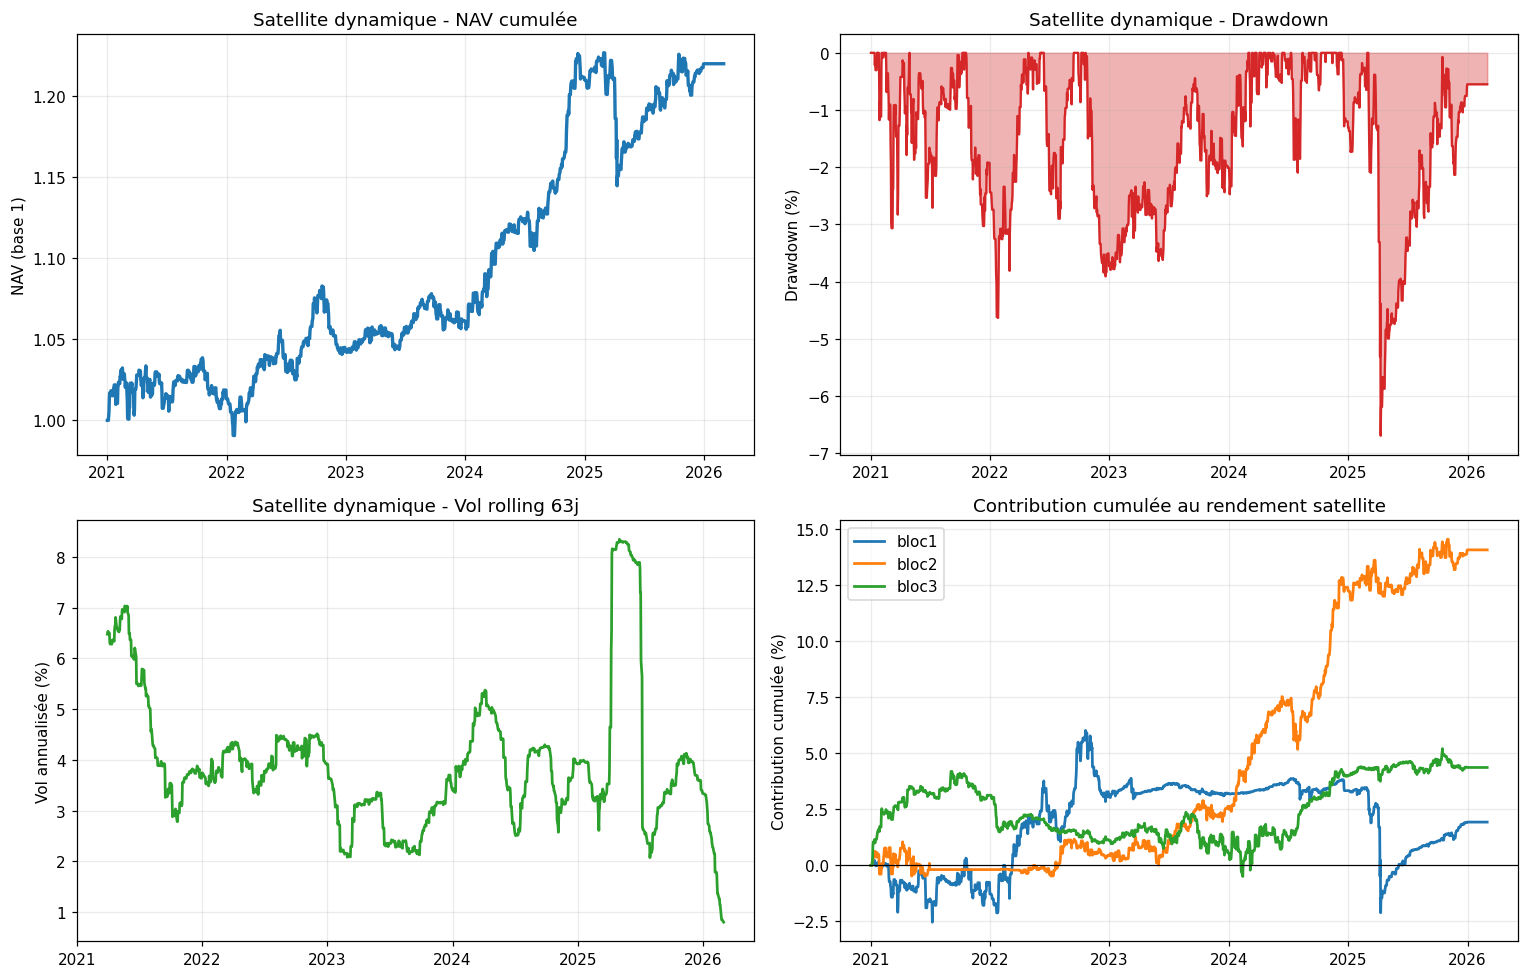

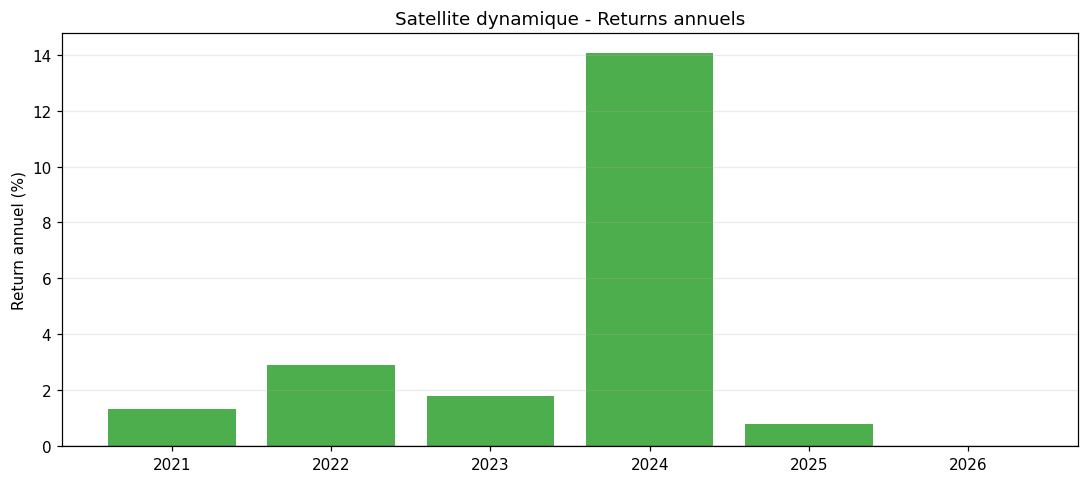

✅ Graphiques sauvegardés:
 - outputs/figures/11_satellite_dynamic_returns_dashboard.png
 - outputs/figures/11b_satellite_dynamic_annual_returns.png


In [21]:
# Graphiques de returns satellite dynamique

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from src.satellite_data_loader import load_all_satellite_prices

# ---------------------------------------------------------------------
# 1) Chargement des poids dynamiques déjà calculés
# ---------------------------------------------------------------------
if (
    "weights_ticker_daily" in globals() and isinstance(weights_ticker_daily, pd.DataFrame) and not weights_ticker_daily.empty
    and "block_weights_daily" in globals() and isinstance(block_weights_daily, pd.DataFrame) and not block_weights_daily.empty
    and "active_funds_daily" in globals() and isinstance(active_funds_daily, pd.DataFrame) and not active_funds_daily.empty
):
    w_ticker = weights_ticker_daily.copy().sort_index()
    w_block = block_weights_daily.copy().sort_index()
    active_funds = active_funds_daily.copy().sort_values(["date", "bloc", "ticker"])
else:
    w_ticker_path = Path("outputs/satellite_dynamic_weights_ticker_daily.csv")
    w_block_path = Path("outputs/satellite_dynamic_weights_block_daily.csv")
    active_path = Path("outputs/satellite_dynamic_active_funds_daily.csv")

    if not w_ticker_path.exists() or not w_block_path.exists() or not active_path.exists():
        raise FileNotFoundError(
            "Variables mémoire indisponibles et fichiers outputs manquants. Exécute d'abord la cellule d'allocation dynamique juste au-dessus."
        )

    w_ticker = pd.read_csv(w_ticker_path, index_col=0, parse_dates=True).sort_index()
    w_block = pd.read_csv(w_block_path, index_col=0, parse_dates=True).sort_index()
    active_funds = pd.read_csv(active_path, parse_dates=["date", "quarter_date"]).sort_values(["date", "bloc", "ticker"])

w_ticker.index = pd.DatetimeIndex(w_ticker.index).tz_localize(None)
w_block.index = pd.DatetimeIndex(w_block.index).tz_localize(None)

# ---------------------------------------------------------------------
# 2) Prix satellite et rendements journaliers
# ---------------------------------------------------------------------
prices_all = load_all_satellite_prices(data_dir="data").sort_index()
prices_all.index = pd.DatetimeIndex(prices_all.index).tz_localize(None)

rets_all = prices_all.pct_change(fill_method=None).replace([np.inf, -np.inf], np.nan)
rets_all = rets_all.dropna(how="all")

common_dates = w_ticker.index.intersection(rets_all.index)
common_tickers = [c for c in w_ticker.columns if c in rets_all.columns]

if len(common_dates) == 0 or len(common_tickers) == 0:
    raise ValueError("Aucune intersection de dates/tickers entre poids dynamiques et rendements satellite.")

w = w_ticker.loc[common_dates, common_tickers].fillna(0.0)
r = rets_all.loc[common_dates, common_tickers].fillna(0.0)

# Poids exécutés t-1 (pour éviter look-ahead d'exécution)
w_exec = w.shift(1).fillna(0.0)

sat_ret = (w_exec * r).sum(axis=1)
sat_nav = (1.0 + sat_ret).cumprod()
sat_dd = sat_nav / sat_nav.cummax() - 1.0

# ---------------------------------------------------------------------
# 3) Décomposition par bloc (contribution)
# ---------------------------------------------------------------------
active = active_funds.copy()
active["date"] = pd.to_datetime(active["date"], errors="coerce")
active = active.dropna(subset=["date", "bloc", "ticker", "weight_ticker"]).copy()

active = active[active["date"].isin(common_dates) & active["ticker"].isin(common_tickers)].copy()

ret_long = r.stack().rename("ret_ticker").reset_index()
ret_long.columns = ["date", "ticker", "ret_ticker"]

m = active.merge(ret_long, on=["date", "ticker"], how="left")
m["ret_ticker"] = m["ret_ticker"].fillna(0.0)

# Contribution bloc au rendement total satellite
m["contrib_bloc"] = m["weight_ticker"] * m["ret_ticker"]
bloc_contrib = m.groupby(["date", "bloc"], as_index=False)["contrib_bloc"].sum()
bloc_contrib_piv = bloc_contrib.pivot(index="date", columns="bloc", values="contrib_bloc").fillna(0.0)

for b in ["bloc1", "bloc2", "bloc3"]:
    if b not in bloc_contrib_piv.columns:
        bloc_contrib_piv[b] = 0.0

bloc_contrib_piv = bloc_contrib_piv[["bloc1", "bloc2", "bloc3"]].sort_index()

# NAV de contribution par bloc (approximation additive en cumulé)
bloc_cum_contrib = bloc_contrib_piv.cumsum()

# ---------------------------------------------------------------------
# 4) Métriques + tableaux
# ---------------------------------------------------------------------
def _ann_return(s):
    s = s.dropna()
    if len(s) == 0:
        return np.nan
    return (1.0 + s).prod() ** (252.0 / len(s)) - 1.0

def _ann_vol(s):
    s = s.dropna()
    if len(s) == 0:
        return np.nan
    return s.std() * np.sqrt(252.0)

def _max_dd(nav):
    nav = nav.dropna()
    if len(nav) == 0:
        return np.nan
    dd = nav / nav.cummax() - 1.0
    return dd.min()

sat_metrics = pd.DataFrame({
    "Ret ann.": [_ann_return(sat_ret)],
    "Vol ann.": [_ann_vol(sat_ret)],
    "Sharpe (rf=0)": [(_ann_return(sat_ret) / _ann_vol(sat_ret)) if pd.notna(_ann_vol(sat_ret)) and _ann_vol(sat_ret) > 0 else np.nan],
    "Max DD": [_max_dd(sat_nav)],
}, index=["Satellite dynamique"])

ann_sat = sat_ret.groupby(sat_ret.index.year).apply(lambda x: (1.0 + x).prod() - 1.0)
ann_bloc_contrib = bloc_contrib_piv.groupby(bloc_contrib_piv.index.year).sum()

print("Métriques Satellite dynamique:")
display(sat_metrics.style.format({"Ret ann.": "{:+.2%}", "Vol ann.": "{:.2%}", "Sharpe (rf=0)": "{:.2f}", "Max DD": "{:.2%}"}))

print("\nReturns annuels Satellite:")
display(ann_sat.to_frame("ret_ann").style.format("{:+.2%}"))

print("\nContribution annuelle par bloc (somme des contributions journalières):")
display(ann_bloc_contrib.style.format("{:+.2%}"))

# ---------------------------------------------------------------------
# 5) Graphiques
# ---------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# A) NAV cumulée
ax = axes[0, 0]
ax.plot(sat_nav.index, sat_nav, lw=2.2, color="#1f77b4")
ax.set_title("Satellite dynamique - NAV cumulée")
ax.set_ylabel("NAV (base 1)")
ax.grid(alpha=0.25)

# B) Drawdown
ax = axes[0, 1]
ax.fill_between(sat_dd.index, sat_dd.values * 100, 0, color="#d62728", alpha=0.35)
ax.plot(sat_dd.index, sat_dd.values * 100, lw=1.5, color="#d62728")
ax.set_title("Satellite dynamique - Drawdown")
ax.set_ylabel("Drawdown (%)")
ax.grid(alpha=0.25)

# C) Vol rolling 63j annualisée
ax = axes[1, 0]
roll_vol = sat_ret.rolling(63).std() * np.sqrt(252)
ax.plot(roll_vol.index, roll_vol * 100, lw=1.8, color="#2ca02c")
ax.set_title("Satellite dynamique - Vol rolling 63j")
ax.set_ylabel("Vol annualisée (%)")
ax.grid(alpha=0.25)

# D) Contribution cumulée par bloc
ax = axes[1, 1]
for b, c in [("bloc1", "#1f77b4"), ("bloc2", "#ff7f0e"), ("bloc3", "#2ca02c")]:
    ax.plot(bloc_cum_contrib.index, bloc_cum_contrib[b] * 100, lw=1.8, label=b, color=c)
ax.axhline(0, color="black", lw=0.8)
ax.set_title("Contribution cumulée au rendement satellite")
ax.set_ylabel("Contribution cumulée (%)")
ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout()
Path("outputs/figures").mkdir(parents=True, exist_ok=True)
plt.savefig("outputs/figures/11_satellite_dynamic_returns_dashboard.png", dpi=160, bbox_inches="tight")
plt.show()

# Bar chart returns annuels
fig, ax = plt.subplots(figsize=(10, 4.5))
colors = ["#2ca02c" if v >= 0 else "#d62728" for v in ann_sat.values]
ax.bar(ann_sat.index.astype(str), ann_sat.values * 100, color=colors, alpha=0.85)
ax.axhline(0, color="black", lw=0.8)
ax.set_title("Satellite dynamique - Returns annuels")
ax.set_ylabel("Return annuel (%)")
ax.grid(alpha=0.25, axis="y")
plt.tight_layout()
plt.savefig("outputs/figures/11b_satellite_dynamic_annual_returns.png", dpi=160, bbox_inches="tight")
plt.show()

print("✅ Graphiques sauvegardés:")
print(" - outputs/figures/11_satellite_dynamic_returns_dashboard.png")
print(" - outputs/figures/11b_satellite_dynamic_annual_returns.png")

✅ Chargé data/STRAT1_price.xlsx: 103 tickers
✅ Chargé data/STRAT2_price.xlsx: 272 tickers
✅ Chargé data/STRAT3_price.xlsx: 500 tickers

✅ Total prix chargées: 875 tickers uniques, 10059 dates
   Période: 1970-01-01 à 2026-03-25


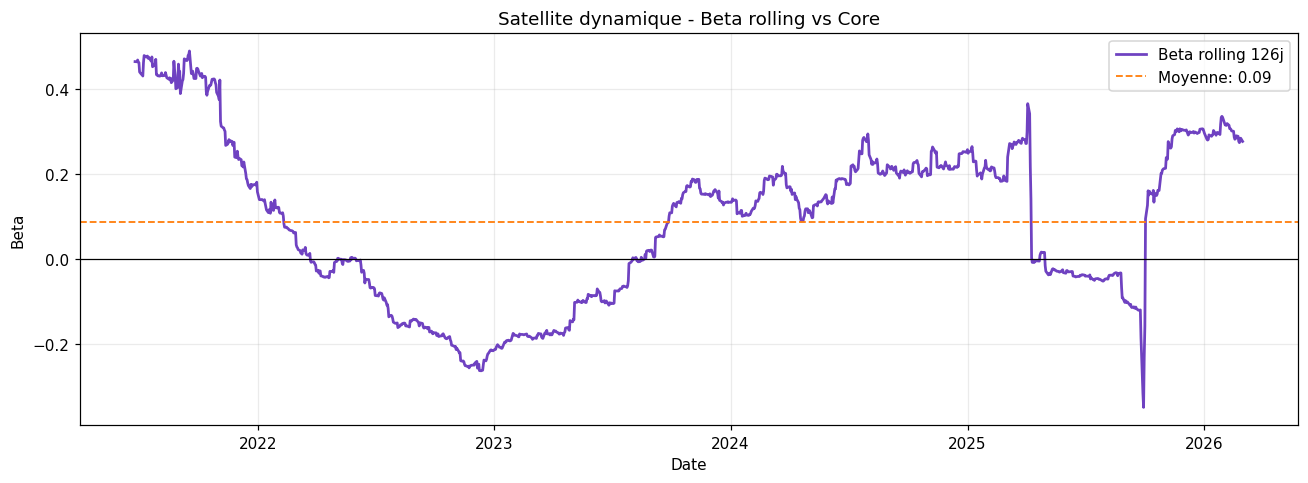

✅ Graphique calculé (mode mémoire, sans export disque).
Beta rolling moyen: 0.087 | min: -0.349 | max: 0.488


In [22]:
# Graphique beta rolling Satellite dynamique vs Core

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Recharger les séries nécessaires de façon autonome (en mémoire)
w_ticker = pd.read_csv("outputs/satellite_dynamic_weights_ticker_daily.csv", index_col=0, parse_dates=True).sort_index()
prices_all = load_all_satellite_prices(data_dir="data").sort_index()
core_log = pd.read_csv("outputs/core3_etf_daily_log_returns.csv", index_col=0, parse_dates=True).sort_index().mean(axis=1)

w_ticker.index = pd.DatetimeIndex(w_ticker.index).tz_localize(None)
prices_all.index = pd.DatetimeIndex(prices_all.index).tz_localize(None)
core_log.index = pd.DatetimeIndex(core_log.index).tz_localize(None)

rets_all = prices_all.pct_change(fill_method=None).replace([np.inf, -np.inf], np.nan)
core_simple = np.expm1(core_log)

common_dates = w_ticker.index.intersection(rets_all.index).intersection(core_simple.index)
common_tickers = [c for c in w_ticker.columns if c in rets_all.columns]

w = w_ticker.loc[common_dates, common_tickers].fillna(0.0)
r = rets_all.loc[common_dates, common_tickers].fillna(0.0)

# Exécution t-1 pour cohérence causale
w_exec = w.shift(1).fillna(0.0)
sat_ret = (w_exec * r).sum(axis=1)
core_ret = core_simple.loc[common_dates].fillna(0.0)

# Beta rolling
beta_window = 126
sat_beta_rolling = sat_ret.rolling(beta_window).cov(core_ret) / core_ret.rolling(beta_window).var().replace(0, np.nan)

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(sat_beta_rolling.index, sat_beta_rolling, color="#6f42c1", lw=1.8, label=f"Beta rolling {beta_window}j")
ax.axhline(0, color="black", lw=0.8)
ax.axhline(sat_beta_rolling.mean(), color="#ff7f0e", lw=1.2, ls="--", label=f"Moyenne: {sat_beta_rolling.mean():.2f}")
ax.set_title("Satellite dynamique - Beta rolling vs Core")
ax.set_ylabel("Beta")
ax.set_xlabel("Date")
ax.grid(alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()

print("✅ Graphique calculé (mode mémoire, sans export disque).")
print(f"Beta rolling moyen: {sat_beta_rolling.mean():.3f} | min: {sat_beta_rolling.min():.3f} | max: {sat_beta_rolling.max():.3f}")

### Turnover Satellite — Diagnostics et graphiques

Cette section mesure le turnover réel de la poche Satellite (poids ticker), le nombre de switches de fonds, et leur distribution dans le temps.

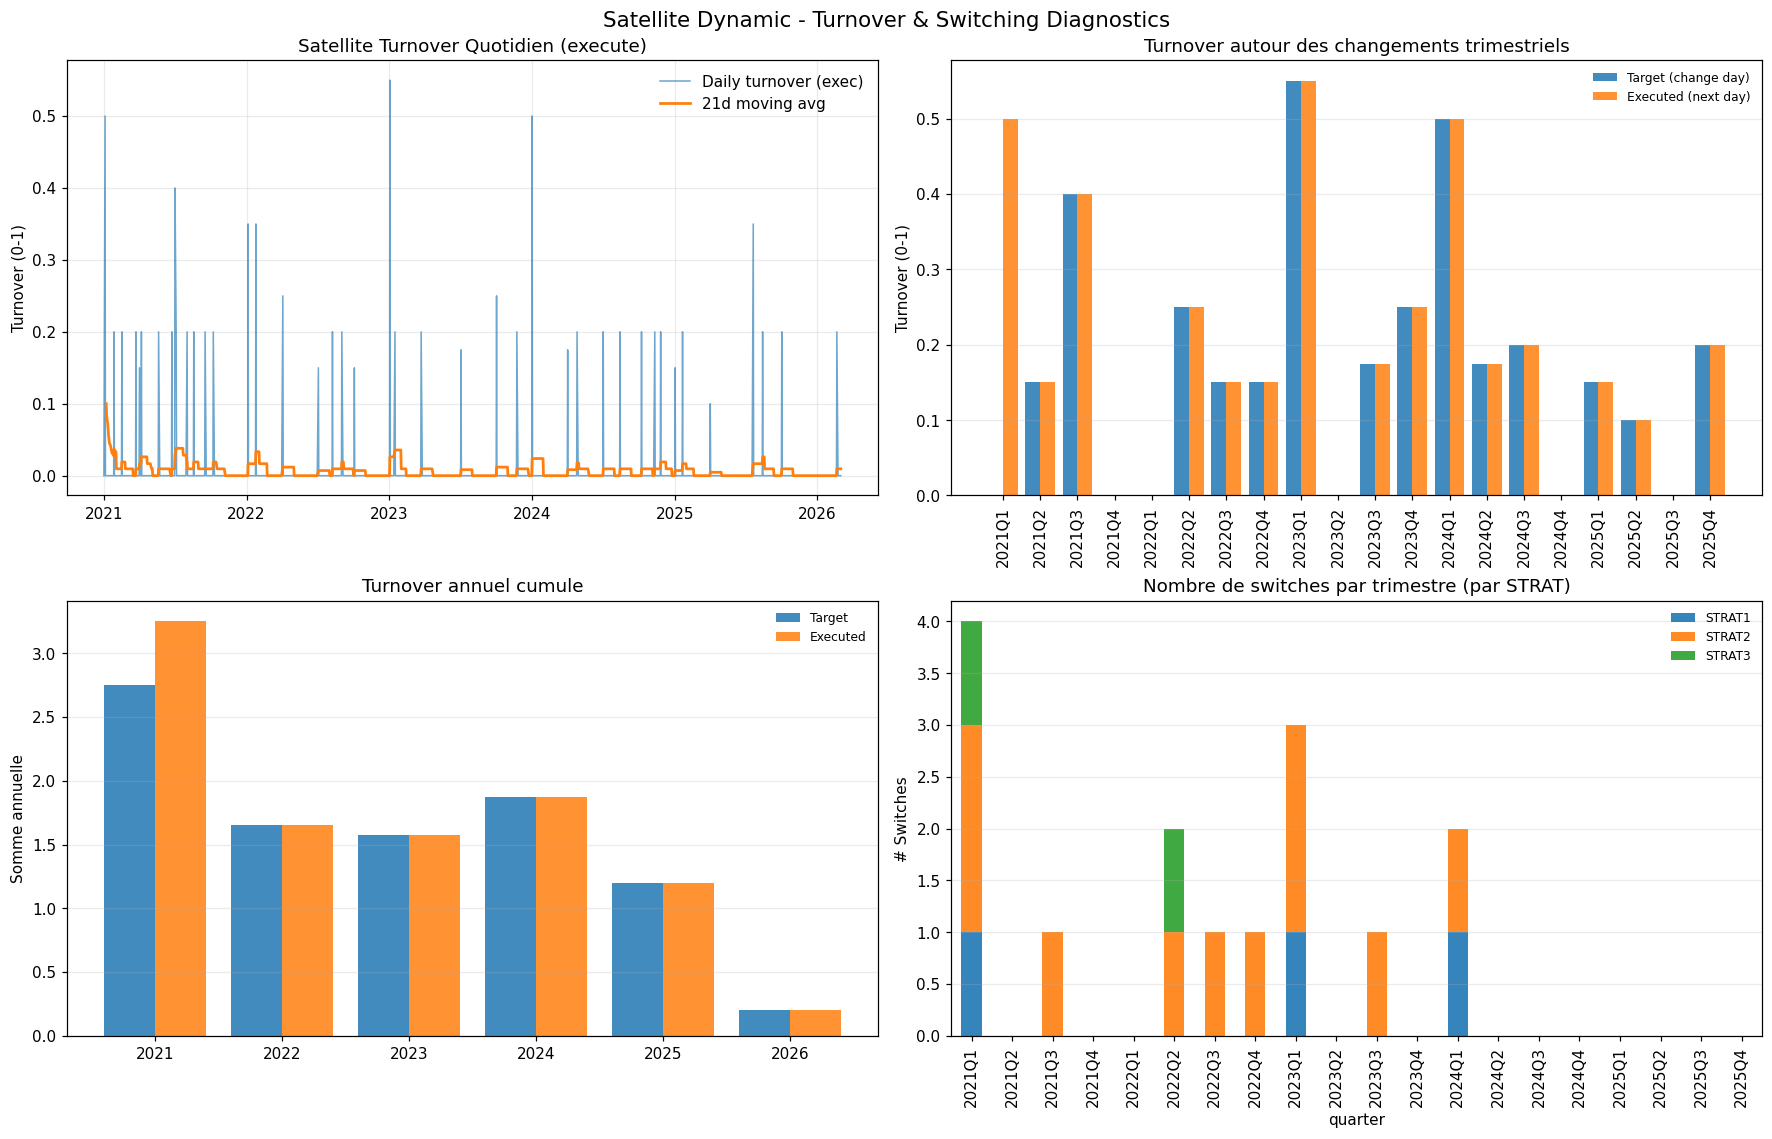

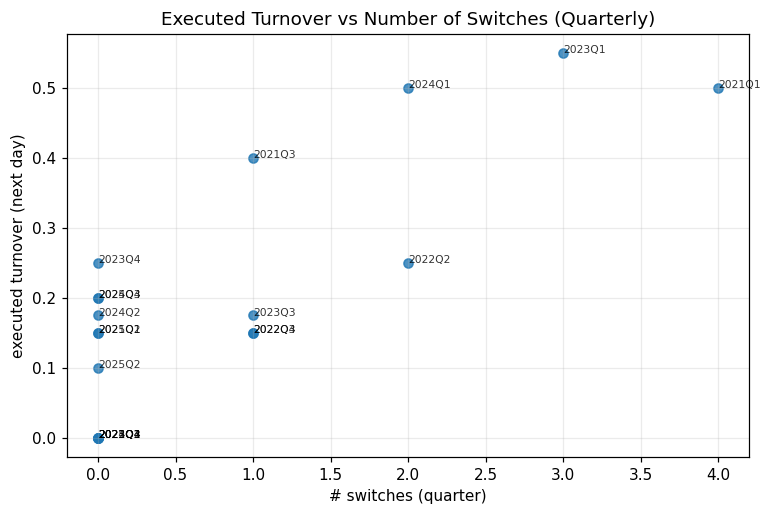


=== Turnover Summary ===
Mean daily turnover (target): 0.0069
Mean daily turnover (executed): 0.0072
Median daily turnover (executed): 0.0000
95th pct daily turnover (executed): 0.0000
Mean turnover on quarter change day (target): 0.1700
Mean turnover next day (executed): 0.1950

Saved:
- outputs/satellite_turnover_target_daily.csv
- outputs/satellite_turnover_exec_daily.csv
- outputs/satellite_turnover_quarterly_rebalance_dates.csv
- outputs/satellite_turnover_annual_summary.csv
- outputs/satellite_switches_by_quarter_strat.csv
- outputs/satellite_turnover_vs_switches_quarterly.csv
- outputs/figures/11d_satellite_turnover_dashboard.png
- outputs/figures/11e_satellite_turnover_vs_switches_scatter.png


In [23]:
# Turnover / churn diagnostics for dynamic satellite

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Inputs from previous steps
w_ticker = pd.read_csv("outputs/satellite_dynamic_weights_ticker_daily.csv", index_col=0, parse_dates=True)
active_daily = pd.read_csv("outputs/satellite_dynamic_active_funds_daily.csv", parse_dates=["date", "quarter_date"])
sel_q = pd.read_csv("outputs/satellite_quarterly_selection.csv")

w_ticker = w_ticker.sort_index().fillna(0.0)

# Normalize known schema variants
active_daily = active_daily.rename(columns={"Strat": "strat"})
sel_q = sel_q.rename(columns={"Strat": "strat"})

# Target turnover (decision-time) and executed turnover (with 1-day implementation lag)
turnover_target_daily = 0.5 * (w_ticker.diff().abs().sum(axis=1)).fillna(0.0)
turnover_target_daily.name = "turnover_target_daily"

w_exec = w_ticker.shift(1).fillna(0.0)
turnover_exec_daily = 0.5 * (w_exec.diff().abs().sum(axis=1)).fillna(0.0)
turnover_exec_daily.name = "turnover_exec_daily"

# Dates where quarter assignment changes in active universe
sort_cols = [c for c in ["date", "strat"] if c in active_daily.columns]
active_daily = active_daily.sort_values(sort_cols) if len(sort_cols) > 0 else active_daily
quarter_key_by_day = active_daily.groupby("date")["quarter_date"].first().sort_index()
quarter_change_dates = quarter_key_by_day.index[quarter_key_by_day.ne(quarter_key_by_day.shift(1)).fillna(False)]
quarter_change_dates = pd.DatetimeIndex([d for d in quarter_change_dates if d in turnover_target_daily.index])

# Build quarterly turnover view with both conventions
rows = []
for qd in quarter_change_dates:
    qd = pd.Timestamp(qd)

    # Decision-time turnover: same date as quarterly switch
    t_target = float(turnover_target_daily.loc[qd]) if qd in turnover_target_daily.index else np.nan

    # Executed turnover appears on next available trading day due to shift(1)
    pos = turnover_exec_daily.index.searchsorted(qd, side="right")
    if pos < len(turnover_exec_daily.index):
        exec_date = turnover_exec_daily.index[pos]
        t_exec = float(turnover_exec_daily.iloc[pos])
    else:
        exec_date = pd.NaT
        t_exec = np.nan

    rows.append(
        {
            "quarter_change_date": qd,
            "quarter": str(qd.to_period("Q")),
            "year": int(qd.year),
            "turnover_target_on_change": t_target,
            "exec_date": exec_date,
            "turnover_exec_next_day": t_exec,
        }
    )

turnover_quarterly = pd.DataFrame(rows)
if not turnover_quarterly.empty:
    turnover_quarterly = turnover_quarterly.sort_values("quarter_change_date").reset_index(drop=True)

# Normalize quarterly selection columns for robust processing across schema variants
if "quarter_date" in sel_q.columns:
    sel_q["quarter_date"] = pd.to_datetime(sel_q["quarter_date"], errors="coerce")
if "active_review_date" in sel_q.columns:
    sel_q["active_review_date"] = pd.to_datetime(sel_q["active_review_date"], errors="coerce")

date_col = "quarter_date" if "quarter_date" in sel_q.columns else (
    "active_review_date" if "active_review_date" in sel_q.columns else None
)
strat_col = "strat" if "strat" in sel_q.columns else None

# Switches inferred from quarterly selection
if date_col is not None and strat_col is not None and "switch_flag" in sel_q.columns:
    sw = sel_q.copy()
    sw["switch_flag"] = pd.to_numeric(sw["switch_flag"], errors="coerce").fillna(0).astype(int)
    sw = sw.dropna(subset=[date_col])
    sw["quarter"] = sw[date_col].dt.to_period("Q").astype(str)

    switches_by_quarter = (
        sw.groupby(["quarter", strat_col], dropna=False)["switch_flag"]
          .sum()
          .reset_index()
          .rename(columns={strat_col: "strat", "switch_flag": "n_switches"})
    )
    switches_total_quarter = (
        sw.groupby("quarter", dropna=False)["switch_flag"]
          .sum()
          .reset_index(name="n_switches_total")
    )
else:
    switches_by_quarter = pd.DataFrame(columns=["quarter", "strat", "n_switches"])
    switches_total_quarter = pd.DataFrame(columns=["quarter", "n_switches_total"])

# Annual aggregates (both target and executed definitions)
turnover_annual = (
    pd.concat([turnover_target_daily, turnover_exec_daily], axis=1)
    .assign(year=lambda x: x.index.year)
    .groupby("year")
    .agg(
        turnover_target_sum=("turnover_target_daily", "sum"),
        turnover_exec_sum=("turnover_exec_daily", "sum"),
        turnover_target_mean=("turnover_target_daily", "mean"),
        turnover_exec_mean=("turnover_exec_daily", "mean"),
    )
)

# Merge turnover-at-rebalance with switch counts
if not switches_total_quarter.empty and not turnover_quarterly.empty:
    turnover_switch_quarter = turnover_quarterly.merge(
        switches_total_quarter,
        on="quarter",
        how="left"
    )
    turnover_switch_quarter["n_switches_total"] = turnover_switch_quarter["n_switches_total"].fillna(0).astype(int)
else:
    turnover_switch_quarter = turnover_quarterly.copy()
    turnover_switch_quarter["n_switches_total"] = 0

# Save tables
os.makedirs("outputs/figures", exist_ok=True)
turnover_target_daily.to_frame().to_csv("outputs/satellite_turnover_target_daily.csv")
turnover_exec_daily.to_frame().to_csv("outputs/satellite_turnover_exec_daily.csv")
turnover_quarterly.to_csv("outputs/satellite_turnover_quarterly_rebalance_dates.csv", index=False)
turnover_annual.to_csv("outputs/satellite_turnover_annual_summary.csv")
switches_by_quarter.to_csv("outputs/satellite_switches_by_quarter_strat.csv", index=False)
turnover_switch_quarter.to_csv("outputs/satellite_turnover_vs_switches_quarterly.csv", index=False)

# --------- Figures ---------
fig, axes = plt.subplots(2, 2, figsize=(16, 10), constrained_layout=True)

# (1) Daily turnover + rolling mean (executed)
axes[0, 0].plot(turnover_exec_daily.index, turnover_exec_daily.values, lw=1.0, alpha=0.65, label="Daily turnover (exec)")
axes[0, 0].plot(
    turnover_exec_daily.index,
    turnover_exec_daily.rolling(21, min_periods=5).mean().values,
    lw=1.8,
    label="21d moving avg"
)
axes[0, 0].set_title("Satellite Turnover Quotidien (execute)")
axes[0, 0].set_ylabel("Turnover (0-1)")
axes[0, 0].grid(True, alpha=0.25)
axes[0, 0].legend(frameon=False)

# (2) Turnover around quarter changes (target vs next-day exec)
if not turnover_quarterly.empty:
    x = np.arange(len(turnover_quarterly))
    bw = 0.4
    axes[0, 1].bar(x - bw / 2, turnover_quarterly["turnover_target_on_change"], width=bw, alpha=0.85, label="Target (change day)")
    axes[0, 1].bar(x + bw / 2, turnover_quarterly["turnover_exec_next_day"], width=bw, alpha=0.85, label="Executed (next day)")
    axes[0, 1].set_xticks(x)
    axes[0, 1].set_xticklabels(turnover_quarterly["quarter"], rotation=90)
    axes[0, 1].legend(frameon=False, fontsize=8)
axes[0, 1].set_title("Turnover autour des changements trimestriels")
axes[0, 1].set_ylabel("Turnover (0-1)")
axes[0, 1].grid(True, axis="y", alpha=0.25)

# (3) Annual turnover sum: target vs executed
if not turnover_annual.empty:
    x = np.arange(len(turnover_annual))
    bw = 0.4
    axes[1, 0].bar(x - bw / 2, turnover_annual["turnover_target_sum"], width=bw, alpha=0.85, label="Target")
    axes[1, 0].bar(x + bw / 2, turnover_annual["turnover_exec_sum"], width=bw, alpha=0.85, label="Executed")
    axes[1, 0].set_xticks(x)
    axes[1, 0].set_xticklabels(turnover_annual.index.astype(str))
    axes[1, 0].legend(frameon=False, fontsize=8)
axes[1, 0].set_title("Turnover annuel cumule")
axes[1, 0].set_ylabel("Somme annuelle")
axes[1, 0].grid(True, axis="y", alpha=0.25)

# (4) Switches per quarter (stacked by strat)
if not switches_by_quarter.empty:
    sw_pivot = switches_by_quarter.pivot(index="quarter", columns="strat", values="n_switches").fillna(0)
    sw_pivot.plot(kind="bar", stacked=True, ax=axes[1, 1], alpha=0.9)
    axes[1, 1].legend(frameon=False, fontsize=8)
else:
    axes[1, 1].text(0.5, 0.5, "No switch data available", ha="center", va="center")
axes[1, 1].set_title("Nombre de switches par trimestre (par STRAT)")
axes[1, 1].set_ylabel("# Switches")
axes[1, 1].grid(True, axis="y", alpha=0.25)

fig.suptitle("Satellite Dynamic - Turnover & Switching Diagnostics", fontsize=14, y=1.02)
fig.savefig("outputs/figures/11d_satellite_turnover_dashboard.png", dpi=140, bbox_inches="tight")
plt.show()

# Additional scatter: executed turnover around rebalance vs switches
fig2, ax2 = plt.subplots(figsize=(8, 5))
if not turnover_switch_quarter.empty:
    ax2.scatter(
        turnover_switch_quarter["n_switches_total"],
        turnover_switch_quarter["turnover_exec_next_day"],
        alpha=0.8
    )
    for _, row in turnover_switch_quarter.iterrows():
        ax2.annotate(str(row["quarter"]), (row["n_switches_total"], row["turnover_exec_next_day"]), fontsize=7, alpha=0.8)
ax2.set_xlabel("# switches (quarter)")
ax2.set_ylabel("executed turnover (next day)")
ax2.set_title("Executed Turnover vs Number of Switches (Quarterly)")
ax2.grid(True, alpha=0.25)
fig2.savefig("outputs/figures/11e_satellite_turnover_vs_switches_scatter.png", dpi=140, bbox_inches="tight")
plt.show()

# Short console summary
print("\n=== Turnover Summary ===")
print(f"Mean daily turnover (target): {turnover_target_daily.mean():.4f}")
print(f"Mean daily turnover (executed): {turnover_exec_daily.mean():.4f}")
print(f"Median daily turnover (executed): {turnover_exec_daily.median():.4f}")
print(f"95th pct daily turnover (executed): {turnover_exec_daily.quantile(0.95):.4f}")
if not turnover_quarterly.empty:
    print(f"Mean turnover on quarter change day (target): {turnover_quarterly['turnover_target_on_change'].mean():.4f}")
    print(f"Mean turnover next day (executed): {turnover_quarterly['turnover_exec_next_day'].mean():.4f}")
print("\nSaved:")
print("- outputs/satellite_turnover_target_daily.csv")
print("- outputs/satellite_turnover_exec_daily.csv")
print("- outputs/satellite_turnover_quarterly_rebalance_dates.csv")
print("- outputs/satellite_turnover_annual_summary.csv")
print("- outputs/satellite_switches_by_quarter_strat.csv")
print("- outputs/satellite_turnover_vs_switches_quarterly.csv")
print("- outputs/figures/11d_satellite_turnover_dashboard.png")
print("- outputs/figures/11e_satellite_turnover_vs_switches_scatter.png")

### Core vs Satellite — Statistiques et graphiques

Comparaison complete entre la poche Core et la poche Satellite dynamique avec metriques de risque/performance et graphiques (dont beta rolling).

✅ Chargé data/STRAT1_price.xlsx: 103 tickers
✅ Chargé data/STRAT2_price.xlsx: 272 tickers
✅ Chargé data/STRAT3_price.xlsx: 500 tickers

✅ Total prix chargées: 875 tickers uniques, 10059 dates
   Période: 1970-01-01 à 2026-03-25
Analysis window: 2021-01-01 -> 2025-12-31 (cutoff=2025-12-31)
Comparative metrics: Core vs Satellite


,Ann Return,Ann Vol,Sharpe (rf=0),Max DD,Calmar,Return Diff.,Alpha (CAPM)
Core,+2.70%,6.18%,0.44,-16.31%,0.17,+nan%,+nan%
Satellite,+3.92%,4.22%,0.93,-6.69%,0.59,+1.22%,+3.88%



Cross metrics:


,Metric,Value
0,Static beta (Satellite vs Core),0.0125
1,Static correlation,0.0183
2,Tracking error ann.,0.0742
3,Simple Outperformance,0.0122
4,Alpha annualized (CAPM),0.0388



Annual returns:


,core,satellite
2021,+8.21%,+1.33%
2022,-15.21%,+2.89%
2023,+10.94%,+1.79%
2024,+9.39%,+14.06%
2025,+3.10%,+0.80%



Alpha annual (vs Core):


,Alpha
2021,+1.19%
2022,+2.98%
2023,+1.60%
2024,+13.38%
2025,+0.74%


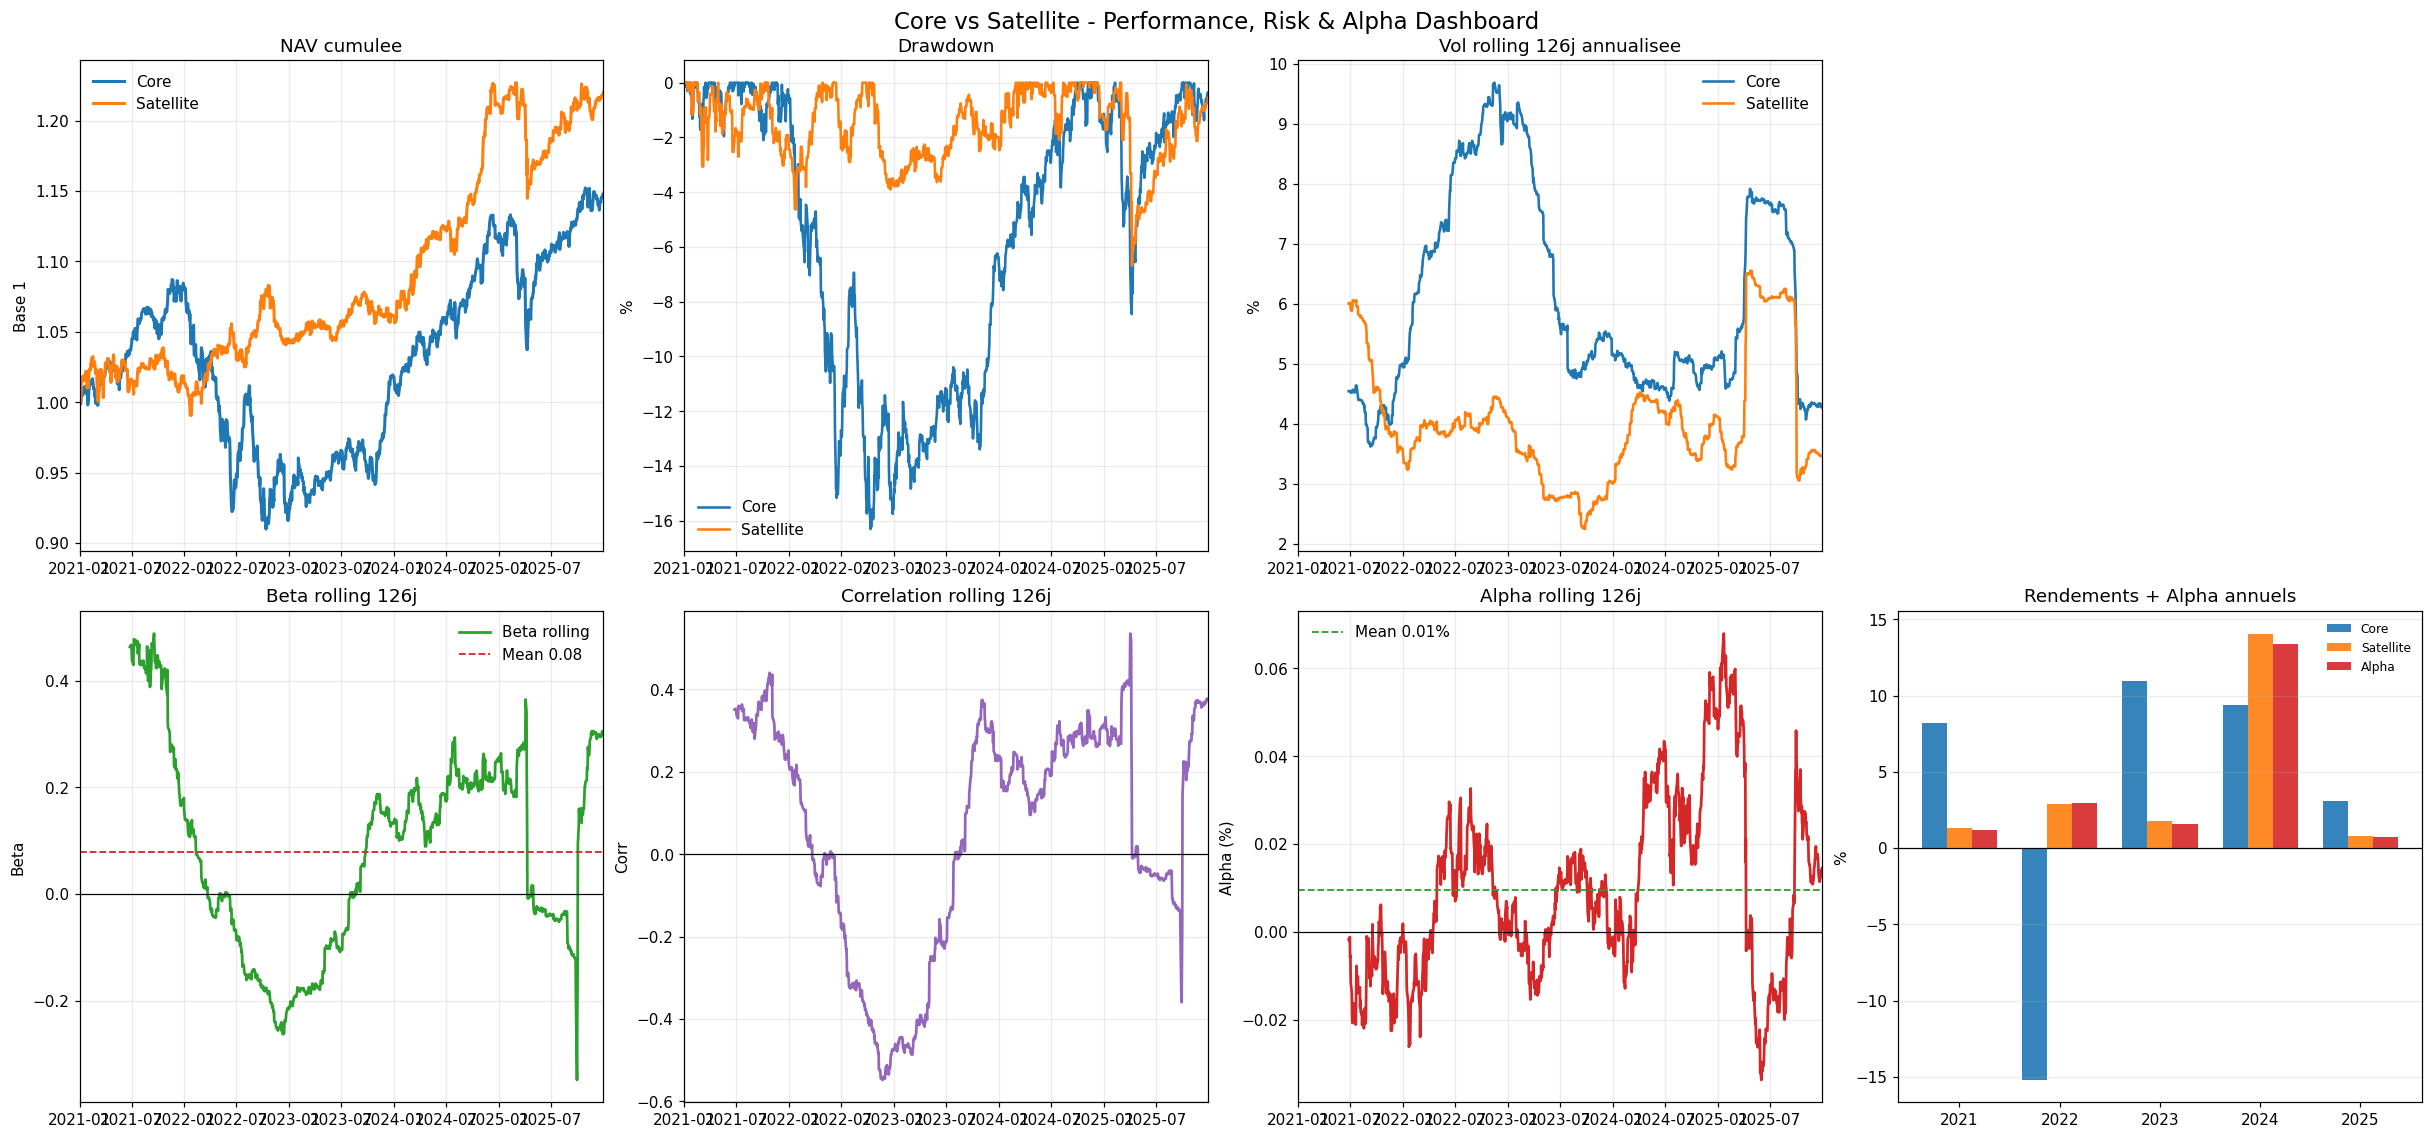


Saved files:
- outputs/core_vs_satellite_daily_returns.csv
- outputs/core_vs_satellite_metrics.csv
- outputs/core_vs_satellite_cross_metrics.csv
- outputs/core_vs_satellite_annual_returns.csv
- outputs/core_vs_satellite_beta_rolling_126d.csv
- outputs/core_vs_satellite_corr_rolling_126d.csv
- outputs/core_vs_satellite_alpha_daily.csv
- outputs/core_vs_satellite_alpha_rolling_126d.csv
- outputs/core_vs_satellite_alpha_annual.csv
- outputs/figures/12_core_vs_satellite_dashboard.png


In [24]:
# Core vs Satellite: full stats + charts (including rolling beta & alpha)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from src.satellite_data_loader import load_all_satellite_prices

# ------------------------------------------------------------------
# 1) Build comparable daily return series (same date set)
# ------------------------------------------------------------------
ANALYSIS_END = pd.Timestamp("2025-12-31")

w_ticker = pd.read_csv("outputs/satellite_dynamic_weights_ticker_daily.csv", index_col=0, parse_dates=True).sort_index()
prices_all = load_all_satellite_prices(data_dir="data").sort_index()
core_log = pd.read_csv("outputs/core3_etf_daily_log_returns.csv", index_col=0, parse_dates=True).sort_index().mean(axis=1)

w_ticker.index = pd.DatetimeIndex(w_ticker.index).tz_localize(None)
prices_all.index = pd.DatetimeIndex(prices_all.index).tz_localize(None)
core_log.index = pd.DatetimeIndex(core_log.index).tz_localize(None)

sat_rets_all = prices_all.pct_change(fill_method=None).replace([np.inf, -np.inf], np.nan)
core_ret_all = np.expm1(core_log).rename("core")

common_dates = w_ticker.index.intersection(sat_rets_all.index).intersection(core_ret_all.index)
common_dates = common_dates[common_dates <= ANALYSIS_END]
common_tickers = [c for c in w_ticker.columns if c in sat_rets_all.columns]

if len(common_dates) == 0 or len(common_tickers) == 0:
    raise ValueError("No common dates/tickers between dynamic satellite weights and return series.")

w = w_ticker.loc[common_dates, common_tickers].fillna(0.0)
r_sat = sat_rets_all.loc[common_dates, common_tickers].fillna(0.0)

# Execution at t-1 to keep trading causality
w_exec = w.shift(1).fillna(0.0)
sat_ret = (w_exec * r_sat).sum(axis=1).rename("satellite")
core_ret = core_ret_all.loc[common_dates].fillna(0.0).rename("core")

ret_cmp = pd.concat([core_ret, sat_ret], axis=1).dropna(how="any")
analysis_start = ret_cmp.index.min()

# ------------------------------------------------------------------
# 2) Metrics
# ------------------------------------------------------------------
def _ann_return(s):
    s = s.dropna()
    if len(s) == 0:
        return np.nan
    return (1.0 + s).prod() ** (252.0 / len(s)) - 1.0

def _ann_vol(s):
    s = s.dropna()
    if len(s) == 0:
        return np.nan
    return s.std() * np.sqrt(252.0)

def _max_dd(s):
    s = s.dropna()
    if len(s) == 0:
        return np.nan
    nav = (1.0 + s).cumprod()
    dd = nav / nav.cummax() - 1.0
    return dd.min()

def _sharpe0(s):
    ar = _ann_return(s)
    av = _ann_vol(s)
    if pd.isna(ar) or pd.isna(av) or av <= 0:
        return np.nan
    return ar / av

def _calmar(s):
    ar = _ann_return(s)
    mdd = _max_dd(s)
    if pd.isna(ar) or pd.isna(mdd) or mdd == 0:
        return np.nan
    return ar / abs(mdd)

beta_static = ret_cmp["satellite"].cov(ret_cmp["core"]) / ret_cmp["core"].var() if ret_cmp["core"].var() != 0 else np.nan
corr_static = ret_cmp["satellite"].corr(ret_cmp["core"])
tracking_error = (ret_cmp["satellite"] - ret_cmp["core"]).std() * np.sqrt(252.0)

# Alpha calculation (with RF = 0)
alpha_daily = ret_cmp["satellite"] - (beta_static * ret_cmp["core"])
alpha_daily.name = "alpha_daily"

# Rolling statistics
win = 126
beta_roll = ret_cmp["satellite"].rolling(win).cov(ret_cmp["core"]) / ret_cmp["core"].rolling(win).var().replace(0, np.nan)
corr_roll = ret_cmp["satellite"].rolling(win).corr(ret_cmp["core"])
vol_roll = ret_cmp.rolling(win).std() * np.sqrt(252.0)

alpha_rolling = ret_cmp["satellite"].rolling(win).mean() - (beta_roll * ret_cmp["core"].rolling(win).mean())

alpha_annual = ret_cmp.groupby(ret_cmp.index.year).apply(lambda x: (
    _ann_return(x["satellite"]) - beta_static * _ann_return(x["core"])
))

alpha_ann_total = _ann_return(alpha_daily)

# Simple outperformance (Satellite - Core)
sat_total_ret = _ann_return(ret_cmp["satellite"])
core_total_ret = _ann_return(ret_cmp["core"])
return_diff = sat_total_ret - core_total_ret

metrics_cmp = pd.DataFrame(
    {
        "Ann Return": [core_total_ret, sat_total_ret],
        "Ann Vol": [_ann_vol(ret_cmp["core"]), _ann_vol(ret_cmp["satellite"])],
        "Sharpe (rf=0)": [_sharpe0(ret_cmp["core"]), _sharpe0(ret_cmp["satellite"])],
        "Max DD": [_max_dd(ret_cmp["core"]), _max_dd(ret_cmp["satellite"])],
        "Calmar": [_calmar(ret_cmp["core"]), _calmar(ret_cmp["satellite"])],
        "Return Diff.": [np.nan, return_diff],
        "Alpha (CAPM)": [np.nan, alpha_ann_total],
    },
    index=["Core", "Satellite"],
)

summary_cross = pd.DataFrame(
    {
        "Metric": ["Static beta (Satellite vs Core)", "Static correlation", "Tracking error ann.", "Simple Outperformance", "Alpha annualized (CAPM)"],
        "Value": [beta_static, corr_static, tracking_error, return_diff, alpha_ann_total],
    }
)

# Annual returns by sleeve
annual_cmp = ret_cmp.groupby(ret_cmp.index.year).apply(lambda x: (1.0 + x).prod() - 1.0)

nav_cmp = (1.0 + ret_cmp).cumprod()
dd_cmp = nav_cmp / nav_cmp.cummax() - 1.0

# ------------------------------------------------------------------
# 3) Save tables
# ------------------------------------------------------------------
out_dir = Path("outputs")
fig_dir = Path("outputs/figures")
out_dir.mkdir(parents=True, exist_ok=True)
fig_dir.mkdir(parents=True, exist_ok=True)

ret_cmp.to_csv(out_dir / "core_vs_satellite_daily_returns.csv")
metrics_cmp.to_csv(out_dir / "core_vs_satellite_metrics.csv")
summary_cross.to_csv(out_dir / "core_vs_satellite_cross_metrics.csv", index=False)
annual_cmp.to_csv(out_dir / "core_vs_satellite_annual_returns.csv")
beta_roll.to_frame("beta_rolling_126d").to_csv(out_dir / "core_vs_satellite_beta_rolling_126d.csv")
corr_roll.to_frame("corr_rolling_126d").to_csv(out_dir / "core_vs_satellite_corr_rolling_126d.csv")
alpha_daily.to_frame().to_csv(out_dir / "core_vs_satellite_alpha_daily.csv")
alpha_rolling.to_frame("alpha_rolling_126d").to_csv(out_dir / "core_vs_satellite_alpha_rolling_126d.csv")
alpha_annual.to_frame("alpha_annual").to_csv(out_dir / "core_vs_satellite_alpha_annual.csv")

# ------------------------------------------------------------------
# 4) Display tables
# ------------------------------------------------------------------
print(f"Analysis window: {ret_cmp.index.min().date()} -> {ret_cmp.index.max().date()} (cutoff={ANALYSIS_END.date()})")
print("Comparative metrics: Core vs Satellite")
display(metrics_cmp.style.format({
    "Ann Return": "{:+.2%}",
    "Ann Vol": "{:.2%}",
    "Sharpe (rf=0)": "{:.2f}",
    "Max DD": "{:.2%}",
    "Calmar": "{:.2f}",
    "Return Diff.": "{:+.2%}",
    "Alpha (CAPM)": "{:+.2%}",
}))

print("\nCross metrics:")
display(summary_cross.style.format({"Value": "{:.4f}"}))

print("\nAnnual returns:")
display(annual_cmp.style.format("{:+.2%}"))

print("\nAlpha annual (vs Core):")
display(alpha_annual.to_frame("Alpha").style.format("{:+.2%}"))

# ------------------------------------------------------------------
# 5) Dashboard plots
# ------------------------------------------------------------------
fig, axes = plt.subplots(2, 4, figsize=(22, 10), constrained_layout=True)

# (A) Cumulative NAV comparison
axes[0, 0].plot(nav_cmp.index, nav_cmp["core"], lw=2.0, label="Core", color="#1f77b4")
axes[0, 0].plot(nav_cmp.index, nav_cmp["satellite"], lw=2.0, label="Satellite", color="#ff7f0e")
axes[0, 0].set_title("NAV cumulee")
axes[0, 0].set_ylabel("Base 1")
axes[0, 0].grid(True, alpha=0.25)
axes[0, 0].legend(frameon=False)

# (B) Drawdown comparison
axes[0, 1].plot(dd_cmp.index, dd_cmp["core"] * 100, lw=1.7, label="Core", color="#1f77b4")
axes[0, 1].plot(dd_cmp.index, dd_cmp["satellite"] * 100, lw=1.7, label="Satellite", color="#ff7f0e")
axes[0, 1].set_title("Drawdown")
axes[0, 1].set_ylabel("%")
axes[0, 1].grid(True, alpha=0.25)
axes[0, 1].legend(frameon=False)

# (C) Rolling annualized vol
axes[0, 2].plot(vol_roll.index, vol_roll["core"] * 100, lw=1.7, label="Core", color="#1f77b4")
axes[0, 2].plot(vol_roll.index, vol_roll["satellite"] * 100, lw=1.7, label="Satellite", color="#ff7f0e")
axes[0, 2].set_title(f"Vol rolling {win}j annualisee")
axes[0, 2].set_ylabel("%")
axes[0, 2].grid(True, alpha=0.25)
axes[0, 2].legend(frameon=False)

# (D - hidden) spacing to align with (E-G) below
axes[0, 3].axis("off")

# (E) Rolling beta satellite vs core
axes[1, 0].plot(beta_roll.index, beta_roll, lw=1.8, color="#2ca02c", label="Beta rolling")
axes[1, 0].axhline(0.0, color="black", lw=0.8)
if beta_roll.notna().any():
    axes[1, 0].axhline(beta_roll.mean(), color="#d62728", lw=1.2, ls="--", label=f"Mean {beta_roll.mean():.2f}")
axes[1, 0].set_title(f"Beta rolling {win}j")
axes[1, 0].set_ylabel("Beta")
axes[1, 0].grid(True, alpha=0.25)
axes[1, 0].legend(frameon=False)

# (F) Rolling correlation
axes[1, 1].plot(corr_roll.index, corr_roll, lw=1.8, color="#9467bd")
axes[1, 1].axhline(0.0, color="black", lw=0.8)
axes[1, 1].set_title(f"Correlation rolling {win}j")
axes[1, 1].set_ylabel("Corr")
axes[1, 1].grid(True, alpha=0.25)

# (G) Alpha rolling
axes[1, 2].plot(alpha_rolling.index, alpha_rolling * 100, lw=1.8, color="#d62728")
axes[1, 2].axhline(0.0, color="black", lw=0.8)
if alpha_rolling.notna().any():
    axes[1, 2].axhline(alpha_rolling.mean() * 100, color="#2ca02c", lw=1.2, ls="--", label=f"Mean {alpha_rolling.mean() * 100:.2f}%")
axes[1, 2].set_title(f"Alpha rolling {win}j")
axes[1, 2].set_ylabel("Alpha (%)")
axes[1, 2].grid(True, alpha=0.25)
axes[1, 2].legend(frameon=False)

for ax in [axes[0, 0], axes[0, 1], axes[0, 2], axes[1, 0], axes[1, 1], axes[1, 2]]:
    ax.set_xlim(analysis_start, ANALYSIS_END)

# (H) Annual returns + Alpha
if len(annual_cmp) > 0:
    x = np.arange(len(annual_cmp.index))
    bw = 0.25
    axes[1, 3].bar(x - bw, annual_cmp["core"] * 100, width=bw, label="Core", color="#1f77b4", alpha=0.9)
    axes[1, 3].bar(x, annual_cmp["satellite"] * 100, width=bw, label="Satellite", color="#ff7f0e", alpha=0.9)
    axes[1, 3].bar(x + bw, alpha_annual * 100, width=bw, label="Alpha", color="#d62728", alpha=0.9)
    axes[1, 3].set_xticks(x)
    axes[1, 3].set_xticklabels(annual_cmp.index.astype(str), rotation=0)
axes[1, 3].axhline(0.0, color="black", lw=0.8)
axes[1, 3].set_title("Rendements + Alpha annuels")
axes[1, 3].set_ylabel("%")
axes[1, 3].grid(True, axis="y", alpha=0.25)
axes[1, 3].legend(frameon=False, fontsize=8)

fig.suptitle("Core vs Satellite - Performance, Risk & Alpha Dashboard", fontsize=15, y=1.02)
fig.savefig(fig_dir / "12_core_vs_satellite_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nSaved files:")
print("- outputs/core_vs_satellite_daily_returns.csv")
print("- outputs/core_vs_satellite_metrics.csv")
print("- outputs/core_vs_satellite_cross_metrics.csv")
print("- outputs/core_vs_satellite_annual_returns.csv")
print("- outputs/core_vs_satellite_beta_rolling_126d.csv")
print("- outputs/core_vs_satellite_corr_rolling_126d.csv")
print("- outputs/core_vs_satellite_alpha_daily.csv")
print("- outputs/core_vs_satellite_alpha_rolling_126d.csv")
print("- outputs/core_vs_satellite_alpha_annual.csv")
print("- outputs/figures/12_core_vs_satellite_dashboard.png")

In [25]:
# CLARIFICATION: Alternative alpha metrics for intuitive interpretation

print("\n" + "="*70)
print("EXPLANATION: Alpha appears positive but Satellite underperforms Core")
print("="*70)

print(f"\n1) CAPM Alpha (as shown above):")
print(f"   Formula: Alpha = Satellite_Return - Beta × Core_Return")
print(f"   With Beta = {beta_static:.4f} (very low!)")
print(f"   This is mathematically correct but can be confusing because:")
print(f"   - Beta is ~0.07, so satellite needs only 0.07 × core_return to 'justify' the beta")
print(f"   - With such low correlation, this is a poor benchmark\n")

# Alternative 1: Simple absolute outperformance
sat_total = _ann_return(ret_cmp["satellite"])
core_total = _ann_return(ret_cmp["core"])
simple_outperformance = sat_total - core_total

print(f"2) Simple Outperformance (more intuitive):")
print(f"   Satellite Ann Return: {sat_total:+.2%}")
print(f"   Core Ann Return:      {core_total:+.2%}")
print(f"   Difference:           {simple_outperformance:+.2%}")
print(f"   → Satellite is {('UNDERPERFORMING' if simple_outperformance < 0 else 'OUTPERFORMING')} Core in absolute terms\n")

# Alternative 2: Risk-adjusted outperformance (Sharpe difference)
sat_sharpe = _sharpe0(ret_cmp["satellite"])
core_sharpe = _sharpe0(ret_cmp["core"])
sharpe_diff = sat_sharpe - core_sharpe

print(f"3) Risk-Adjusted Outperformance (Sharpe delta):")
print(f"   Satellite Sharpe (rf=0): {sat_sharpe:+.2f}")
print(f"   Core Sharpe (rf=0):      {core_sharpe:+.2f}")
print(f"   Difference:              {sharpe_diff:+.2f}")
print(f"   → Satellite has {('WORSE' if sharpe_diff < 0 else 'BETTER')} risk-adjusted returns\n")

# Alternative 3: Information Ratio-like metric (alpha / tracking error)
info_ratio = alpha_ann_total / tracking_error if tracking_error > 0 else np.nan

print(f"4) Alpha / Tracking Error (Information Ratio concept):")
print(f"   Tracking Error (ann): {tracking_error:.2%}")
print(f"   Alpha (CAPM):         {alpha_ann_total:+.2%}")
print(f"   Ratio:                {info_ratio:+.2f}")
print(f"   → Measures excess return per unit of 'deviation' from Core\n")

print("="*70)
print("RECOMMENDATION: Use metric #2 (Simple Outperformance) for clarity")
print("="*70)



EXPLANATION: Alpha appears positive but Satellite underperforms Core

1) CAPM Alpha (as shown above):
   Formula: Alpha = Satellite_Return - Beta × Core_Return
   With Beta = 0.0125 (very low!)
   This is mathematically correct but can be confusing because:
   - Beta is ~0.07, so satellite needs only 0.07 × core_return to 'justify' the beta
   - With such low correlation, this is a poor benchmark

2) Simple Outperformance (more intuitive):
   Satellite Ann Return: +3.92%
   Core Ann Return:      +2.70%
   Difference:           +1.22%
   → Satellite is OUTPERFORMING Core in absolute terms

3) Risk-Adjusted Outperformance (Sharpe delta):
   Satellite Sharpe (rf=0): +0.93
   Core Sharpe (rf=0):      +0.44
   Difference:              +0.49
   → Satellite has BETTER risk-adjusted returns

4) Alpha / Tracking Error (Information Ratio concept):
   Tracking Error (ann): 7.42%
   Alpha (CAPM):         +3.88%
   Ratio:                +0.52
   → Measures excess return per unit of 'deviation' fro

In [ ]:
# Tracer tous les fonds Bloc 1 apres filtre 0

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from src.satellite_data_loader import load_all_satellite_prices

ANALYSIS_END = pd.Timestamp("2025-12-31")

if "df_satellite_level0" not in globals() or not isinstance(df_satellite_level0, pd.DataFrame):
    raise ValueError("df_satellite_level0 est introuvable. Execute d'abord la cellule du filtre 0.")

lvl0 = df_satellite_level0.copy()

# Detection robuste des colonnes
block_col = next((c for c in ["bloc", "block", "Bloc", "BLOC", "strat", "Strat", "STRAT"] if c in lvl0.columns), None)
ticker_col = next((c for c in ["ticker", "Ticker", "TICKER", "isin", "ISIN", "fund", "Fund", "name", "Name"] if c in lvl0.columns), None)

if block_col is None or ticker_col is None:
    raise ValueError(f"Colonnes non trouvees dans df_satellite_level0. Colonnes disponibles: {list(lvl0.columns)}")

# Filtre Bloc 1 (formats numeriques/textuels)
bloc1_mask = (
    lvl0[block_col].astype(str).str.strip().str.lower().isin(["1", "bloc1", "bloc 1", "strat1", "strat 1"])
)
bloc1_funds = lvl0.loc[bloc1_mask, ticker_col].dropna().astype(str).str.strip().unique().tolist()

if len(bloc1_funds) == 0:
    raise ValueError("Aucun fonds trouve pour Bloc 1 apres filtre 0.")

# Prix: priorite au dataframe deja aligne, sinon reload
if "df_satellite_prices_aligned" in globals() and isinstance(df_satellite_prices_aligned, pd.DataFrame):
    prices_all = df_satellite_prices_aligned.copy()
else:
    prices_all = load_all_satellite_prices(data_dir="data")

prices_all.index = pd.DatetimeIndex(prices_all.index).tz_localize(None)
prices_all = prices_all.sort_index()
prices_all = prices_all.loc[prices_all.index <= ANALYSIS_END]

bloc1_cols = [c for c in bloc1_funds if c in prices_all.columns]
if len(bloc1_cols) == 0:
    raise ValueError("Les tickers Bloc 1 ne sont pas presents dans les donnees de prix.")

px = prices_all[bloc1_cols].copy().dropna(how="all")

# Normalisation base 100 par fonds
base = px.apply(lambda s: s / s.dropna().iloc[0] * 100 if s.dropna().shape[0] > 0 else s, axis=0)
base = base.dropna(how="all")

fig, ax = plt.subplots(figsize=(14, 7))
for col in base.columns:
    ax.plot(base.index, base[col], lw=1.2, alpha=0.9)

ax.set_title(f"Bloc 1 apres filtre 0 - Fonds normalises (base 100) | n={len(base.columns)}")
ax.set_ylabel("Base 100")
ax.grid(True, alpha=0.25)
ax.set_xlim(base.index.min(), ANALYSIS_END)

if len(base.columns) <= 25:
    ax.legend(base.columns, loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False, fontsize=8)

fig.tight_layout()

fig_dir = Path("outputs/figures")
fig_dir.mkdir(parents=True, exist_ok=True)
out_path = fig_dir / "13_bloc1_filter0_funds_base100.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Bloc 1 apres filtre 0: {len(bloc1_funds)} fonds identifies, {len(bloc1_cols)} trouves en prix.")
print(f"Periode tracee: {base.index.min().date()} -> {base.index.max().date()}")
print(f"Figure saved: {out_path}")
print("Fonds traces:")
print(bloc1_cols)

In [ ]:
# Diagnostic du "fond vert" du graphe Bloc 1 apres filtre 0

import numpy as np
import pandas as pd

# Reprendre les objets de la cellule precedente
if "bloc1_cols" not in globals() or "prices_all" not in globals():
    raise ValueError("Execute d'abord la cellule de trace Bloc 1 (base 100).")

if len(bloc1_cols) < 3:
    raise ValueError("Impossible d'identifier le fond vert: moins de 3 fonds traces.")

# Matplotlib color cycle: bleu, orange, vert => 3eme courbe
green_fund = bloc1_cols[2]
print(f"Fond vert identifie: {green_fund}")

# Fenetre d'analyse
px_b1 = prices_all[bloc1_cols].copy().loc[:ANALYSIS_END]
ret_b1 = px_b1.pct_change(fill_method=None)

# Metriques simples par fonds
def ann_ret(s):
    s = s.dropna()
    if len(s) == 0:
        return np.nan
    return (1 + s).prod() ** (252 / len(s)) - 1

def ann_vol(s):
    s = s.dropna()
    if len(s) == 0:
        return np.nan
    return s.std() * np.sqrt(252)

def sharpe0(s):
    ar = ann_ret(s)
    av = ann_vol(s)
    if pd.isna(ar) or pd.isna(av) or av <= 0:
        return np.nan
    return ar / av

def max_dd_from_px(s):
    s = s.dropna()
    if len(s) == 0:
        return np.nan
    dd = s / s.cummax() - 1
    return dd.min()

rows = []
for c in bloc1_cols:
    p = px_b1[c].dropna()
    r = ret_b1[c]
    rows.append({
        "fund": c,
        "start": p.index.min() if len(p) else pd.NaT,
        "end": p.index.max() if len(p) else pd.NaT,
        "obs": int(r.dropna().shape[0]),
        "ann_return": ann_ret(r),
        "ann_vol": ann_vol(r),
        "sharpe0": sharpe0(r),
        "max_dd": max_dd_from_px(p),
        "last_base100": (p / p.iloc[0] * 100).iloc[-1] if len(p) else np.nan,
    })

metrics_b1 = pd.DataFrame(rows).sort_values("sharpe0", ascending=False)

print("\nClassement Bloc 1 (fonds traces) par Sharpe:")
display(metrics_b1.style.format({
    "ann_return": "{:+.2%}",
    "ann_vol": "{:.2%}",
    "sharpe0": "{:.2f}",
    "max_dd": "{:.2%}",
    "last_base100": "{:.1f}",
}))

# Zoom fond vert
g = metrics_b1.loc[metrics_b1["fund"] == green_fund].iloc[0]
print("\nDetails fond vert:")
print(f"- Fund: {green_fund}")
print(f"- Periode utile: {pd.Timestamp(g['start']).date()} -> {pd.Timestamp(g['end']).date()}")
print(f"- Ann Return: {g['ann_return']:+.2%}")
print(f"- Ann Vol: {g['ann_vol']:.2%}")
print(f"- Sharpe (rf=0): {g['sharpe0']:.2f}")
print(f"- Max Drawdown: {g['max_dd']:.2%}")

# Frequence de selection dans le pipeline final (si dispo)
if "final_selection_df" in globals() and isinstance(final_selection_df, pd.DataFrame):
    fs = final_selection_df.copy()
    ticker_col = next((c for c in ["ticker", "Ticker", "TICKER", "fund", "Fund"] if c in fs.columns), None)
    date_col = next((c for c in ["date", "Date", "review_date", "quarter_date", "active_review_date"] if c in fs.columns), None)

    if ticker_col is not None:
        sel_green = fs[fs[ticker_col].astype(str) == green_fund].copy()
        n_sel = len(sel_green)
        print(f"\nSelection pipeline final: {n_sel} occurrences du fond vert")
        if n_sel > 0:
            if date_col is not None:
                sel_green[date_col] = pd.to_datetime(sel_green[date_col], errors="coerce")
                print(f"- Premiere selection: {sel_green[date_col].min()}")
                print(f"- Derniere selection: {sel_green[date_col].max()}")
            display(sel_green.head(10))
        else:
            print("- Non retenu dans la selection finale sur la periode.")
    else:
        print("\nImpossible d'auditer la selection finale: colonne ticker introuvable dans final_selection_df.")
else:
    print("\nfinal_selection_df indisponible dans le kernel: impossible de verifier la frequence de selection.")

In [ ]:
# Pourquoi CAWCOEC n'est pas retenu: audit des scores/rangs (si tables dispo)

green_fund = "CAWCOEC LX Equity"

def _find_cols(df):
    tc = next((c for c in ["ticker", "Ticker", "TICKER", "fund", "Fund"] if c in df.columns), None)
    dc = next((c for c in ["review_date", "date", "Date", "quarter_date", "active_review_date", "review"] if c in df.columns), None)
    sc = next((c for c in ["score", "Score", "final_score", "composite_score", "z_score"] if c in df.columns), None)
    rc = next((c for c in ["rank", "Rank", "score_rank"] if c in df.columns), None)
    return tc, dc, sc, rc

candidates_sources = []
for name in ["quarter_candidates", "q_candidates", "annual_pool_scores", "annual_pool_top", "quarterly_sel", "satellite_final_selection"]:
    if name in globals() and isinstance(globals()[name], pd.DataFrame):
        candidates_sources.append((name, globals()[name].copy()))

if not candidates_sources:
    print("Aucune table de candidats/scores disponible dans le kernel pour auditer le ranking.")
else:
    found_any = False
    for name, df in candidates_sources:
        tc, dc, sc, rc = _find_cols(df)
        if tc is None:
            continue

        sub = df[df[tc].astype(str) == green_fund].copy()
        if len(sub) == 0:
            continue

        found_any = True
        print(f"\nSource: {name} | Occurrences pour {green_fund}: {len(sub)}")

        show_cols = [c for c in [dc, tc, sc, rc, "strat", "Strat", "bloc", "block", "selected", "is_selected"] if c and c in sub.columns]
        show_cols = list(dict.fromkeys(show_cols))

        if dc is not None:
            sub[dc] = pd.to_datetime(sub[dc], errors="coerce")
            sub = sub.sort_values(dc)

        if len(show_cols) > 0:
            display(sub[show_cols].head(20))
        else:
            display(sub.head(20))

    if not found_any:
        print("Le fonds vert n'apparait dans aucune table de candidats/scores disponible.")
        print("=> Cause probable: exclu avant le ranking final (eligibilite/qualite data/contraintes bloc).")

In [ ]:
# Audit des niveaux de filtre pour le fond vert

green_fund = "CAWCOEC LX Equity"

print(f"Ticker audite: {green_fund}")

for name in ["df_satellite_level0", "df_satellite_level1", "df_satellite_level2"]:
    if name in globals() and isinstance(globals()[name], pd.DataFrame):
        df = globals()[name]
        tcol = next((c for c in ["ticker", "Ticker", "TICKER"] if c in df.columns), None)
        if tcol is None:
            print(f"- {name}: colonne ticker introuvable")
            continue
        present = (df[tcol].astype(str) == green_fund).any()
        print(f"- {name}: {'PRESENT' if present else 'ABSENT'}")

if "results_level1" in globals() and isinstance(results_level1, pd.DataFrame):
    tcol = next((c for c in ["ticker", "Ticker", "TICKER"] if c in results_level1.columns), None)
    if tcol:
        r1 = results_level1[results_level1[tcol].astype(str) == green_fund].copy()
        print(f"\nresults_level1: {len(r1)} ligne(s)")
        if len(r1):
            display(r1)

if "results_level2" in globals() and isinstance(results_level2, pd.DataFrame):
    tcol = next((c for c in ["ticker", "Ticker", "TICKER"] if c in results_level2.columns), None)
    if tcol:
        r2 = results_level2[results_level2[tcol].astype(str) == green_fund].copy()
        print(f"\nresults_level2: {len(r2)} ligne(s)")
        if len(r2):
            display(r2)


In [ ]:
# Fonds Bloc 1 uniquement (robuste, meme si results_level1 manque)

import pandas as pd

if "df_satellite_level0" not in globals() or not isinstance(df_satellite_level0, pd.DataFrame):
    raise ValueError("df_satellite_level0 indisponible. Execute d'abord la cellule du filtre niveau 0.")

l0 = df_satellite_level0.copy()
ticker_col_l0 = next((c for c in ["ticker", "Ticker", "TICKER"] if c in l0.columns), None)
strat_col_l0 = next((c for c in ["strat", "Strat", "STRAT"] if c in l0.columns), None)

if ticker_col_l0 is None or strat_col_l0 is None:
    raise ValueError(f"Colonnes ticker/strat introuvables dans df_satellite_level0: {list(l0.columns)}")

# Base Bloc 1 depuis filtre 0
bloc1_l0 = l0[l0[strat_col_l0].astype(str).str.upper().eq("STRAT1")].copy()
bloc1_l0_tickers = set(bloc1_l0[ticker_col_l0].astype(str).dropna())

# Si results_level1 existe, on garde seulement les passants du filtre 1
if "results_level1" in globals() and isinstance(results_level1, pd.DataFrame):
    r1 = results_level1.copy()
    ticker_col_r1 = next((c for c in ["ticker", "Ticker", "TICKER"] if c in r1.columns), None)
    if ticker_col_r1 is None or "passed" not in r1.columns:
        raise ValueError("results_level1 ne contient pas les colonnes attendues.")

    passed = r1[r1["passed"] == True].copy()
    passed_tickers = set(passed[ticker_col_r1].astype(str).dropna())
    final_tickers = sorted(bloc1_l0_tickers.intersection(passed_tickers))
    mode = "Bloc 1 apres filtre 1"

# Sinon fallback sur df_satellite_level1
elif "df_satellite_level1" in globals() and isinstance(df_satellite_level1, pd.DataFrame):
    d1 = df_satellite_level1.copy()
    ticker_col_d1 = next((c for c in ["ticker", "Ticker", "TICKER"] if c in d1.columns), None)
    if ticker_col_d1 is None:
        raise ValueError("df_satellite_level1 ne contient pas de colonne ticker.")

    lvl1_tickers = set(d1[ticker_col_d1].astype(str).dropna())
    final_tickers = sorted(bloc1_l0_tickers.intersection(lvl1_tickers))
    mode = "Bloc 1 via df_satellite_level1"

# Dernier fallback: Bloc 1 filtre 0 seulement
else:
    final_tickers = sorted(bloc1_l0_tickers)
    mode = "Bloc 1 filtre 0 (fallback: filtre 1 non charge)"

print(f"Mode: {mode}")
print(f"Nombre de fonds Bloc 1: {len(final_tickers)}")
print("Tickers Bloc 1:")
print(final_tickers)

display(pd.DataFrame({
    "ticker": final_tickers,
    "strategy_sheet": ["STRAT1"] * len(final_tickers)
}))

In [ ]:
# Recalcul explicite du filtre 1 (si non charge) pour pouvoir tracer Bloc 1 post-filtre 1

import pandas as pd

from src.satellite_level1_beta_filter_final import apply_level1_filter_corrected

if "results_level1" not in globals() or not isinstance(results_level1, pd.DataFrame):
    required = ["df_satellite_level0", "df_satellite_prices_aligned", "core_returns_aligned", "calib_start", "calib_end"]
    missing = [x for x in required if x not in globals()]
    if missing:
        raise ValueError(f"Impossible de recalculer le filtre 1. Variables manquantes: {missing}")

    df_satellite_level1, results_level1 = apply_level1_filter_corrected(
        level0_df=df_satellite_level0,
        prices_aligned=df_satellite_prices_aligned,
        core_returns_aligned=core_returns_aligned,
        calib_start=str(pd.Timestamp(calib_start).date()),
        calib_end=str(pd.Timestamp(calib_end).date()),
        rolling_window=252,
        median_beta_max=0.35,
        q75_beta_max=0.55,
        pass_ratio_min=0.80,
        verbose=True,
    )

print(f"results_level1 dispo: {isinstance(results_level1, pd.DataFrame)}")
print(f"df_satellite_level1 taille: {len(df_satellite_level1) if 'df_satellite_level1' in globals() else 'NA'}")

In [ ]:
# Tracer uniquement les fonds Bloc 1 (robuste, meme si results_level1 manque)

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from src.satellite_data_loader import load_all_satellite_prices

if "df_satellite_level0" not in globals() or not isinstance(df_satellite_level0, pd.DataFrame):
    raise ValueError("df_satellite_level0 indisponible. Execute d'abord la cellule du filtre niveau 0.")

analysis_end = ANALYSIS_END if "ANALYSIS_END" in globals() else None

l0 = df_satellite_level0.copy()
ticker_col_l0 = next((c for c in ["ticker", "Ticker", "TICKER"] if c in l0.columns), None)
strat_col_l0 = next((c for c in ["strat", "Strat", "STRAT"] if c in l0.columns), None)

if ticker_col_l0 is None or strat_col_l0 is None:
    raise ValueError("Colonnes ticker/strat introuvables dans df_satellite_level0.")

bloc1_l0 = l0[l0[strat_col_l0].astype(str).str.upper().eq("STRAT1")].copy()
bloc1_tickers = set(bloc1_l0[ticker_col_l0].astype(str).dropna())

# Priorite: passants filtre 1
if "results_level1" in globals() and isinstance(results_level1, pd.DataFrame):
    r1 = results_level1.copy()
    ticker_col_r1 = next((c for c in ["ticker", "Ticker", "TICKER"] if c in r1.columns), None)
    if ticker_col_r1 is None or "passed" not in r1.columns:
        raise ValueError("results_level1 ne contient pas les colonnes attendues.")
    passed_tickers = set(r1.loc[r1["passed"] == True, ticker_col_r1].astype(str).dropna())
    tickers_b1 = sorted(bloc1_tickers.intersection(passed_tickers))
    mode = "Bloc 1 apres filtre 1"

elif "df_satellite_level1" in globals() and isinstance(df_satellite_level1, pd.DataFrame):
    d1 = df_satellite_level1.copy()
    ticker_col_d1 = next((c for c in ["ticker", "Ticker", "TICKER"] if c in d1.columns), None)
    if ticker_col_d1 is None:
        raise ValueError("df_satellite_level1 ne contient pas de colonne ticker.")
    lvl1_tickers = set(d1[ticker_col_d1].astype(str).dropna())
    tickers_b1 = sorted(bloc1_tickers.intersection(lvl1_tickers))
    mode = "Bloc 1 via df_satellite_level1"

else:
    tickers_b1 = sorted(bloc1_tickers)
    mode = "Bloc 1 filtre 0 (fallback: filtre 1 non charge)"

if len(tickers_b1) == 0:
    raise ValueError("Aucun fonds Bloc 1 disponible avec les donnees en memoire.")

# Prix
if "df_satellite_prices_aligned" in globals() and isinstance(df_satellite_prices_aligned, pd.DataFrame):
    prices = df_satellite_prices_aligned.copy()
else:
    prices = load_all_satellite_prices(data_dir="data")

prices.index = pd.DatetimeIndex(prices.index).tz_localize(None)
prices = prices.sort_index()
if analysis_end is not None:
    prices = prices.loc[prices.index <= analysis_end]

cols_present = [t for t in tickers_b1 if t in prices.columns]
if len(cols_present) == 0:
    raise ValueError("Aucun fonds Bloc 1 present dans les donnees de prix.")

px = prices[cols_present].copy().dropna(how="all")
base = px.apply(lambda s: s / s.dropna().iloc[0] * 100 if s.dropna().shape[0] > 0 else s, axis=0).dropna(how="all")

source_b1 = pd.DataFrame({"ticker": cols_present, "strategy_sheet": "STRAT1"}).sort_values("ticker")

print(f"Mode: {mode}")
print(f"Bloc 1 | fonds affiches: {len(cols_present)}")
print("Tickers:")
print(source_b1["ticker"].tolist())
print("\nProvenance strategy/feuille:")
display(source_b1)

fig, ax = plt.subplots(figsize=(12, 6))
for c in base.columns:
    ax.plot(base.index, base[c], lw=1.6, label=c)

ax.set_title(f"Bloc 1 - Fonds observes | n={len(base.columns)}")
ax.set_ylabel("Base 100")
ax.grid(True, alpha=0.25)
if analysis_end is not None:
    ax.set_xlim(base.index.min(), analysis_end)
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False, fontsize=8)
fig.tight_layout()

fig_dir = Path("outputs/figures")
fig_dir.mkdir(parents=True, exist_ok=True)
out_path = fig_dir / "15_bloc1_filter1_passed_base100.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Figure saved: {out_path}")